# Lecture 10: Model Comparison

## Contents
- [10.1 Overfitting and underfitting](#section-101)
- [10.3 Kullback-Leibler divergence](#section-103)
- [10.4 Information criteria](#section-104)
- [10.5 Cross-validation](#section-105)
- [10.6 Updated Bayesian workflow](#section-106)


## Setup

### Imports and plotting defaults


In [1]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import statsmodels.formula.api as smf
import xarray as xr
from palmerpenguins import load_penguins

In [2]:
az.style.use("arviz-whitegrid")
plt.rc('figure', dpi=450)

<a id="section-101"></a>
## 10.1 Overfitting and underfitting

A first criterion for choosing between models.


### 10.1.07 We want to model some data


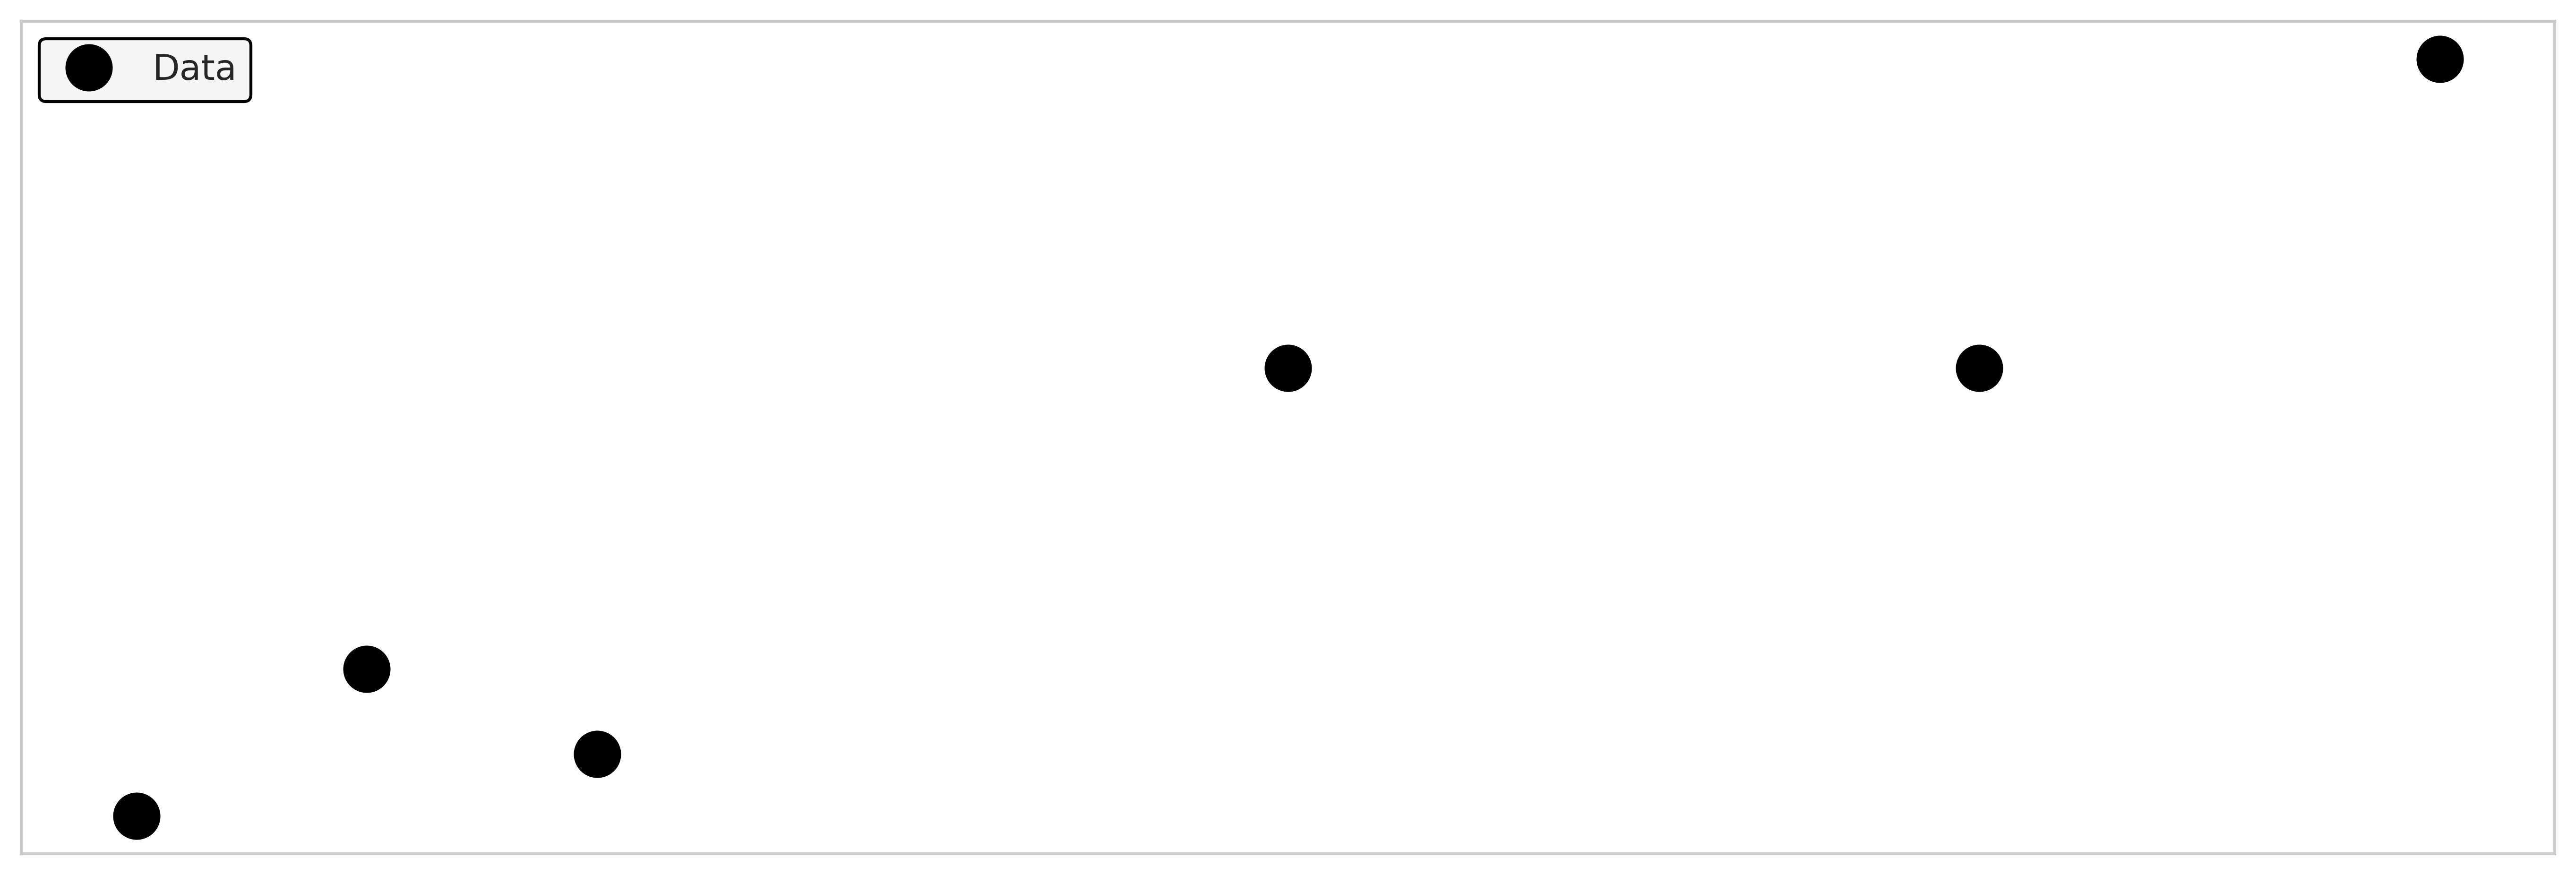

In [3]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))


x0 = np.array([4.0, 5.0, 6.0, 9.0, 12, 14.0])
y0 = np.array([4.2, 6.1, 5.0, 10.0, 10, 14.0])

order = [0, 1, 5]
ax.plot(x0, y0, "ko", zorder=3, markersize=15, label="Data")

ax.set_yticks([])
ax.set_xticks([])

ax.legend(loc=2, fontsize=12, frameon=True, fancybox=True, facecolor="whitesmoke", edgecolor="k", framealpha=1)

### 10.1.08 A model that underfits


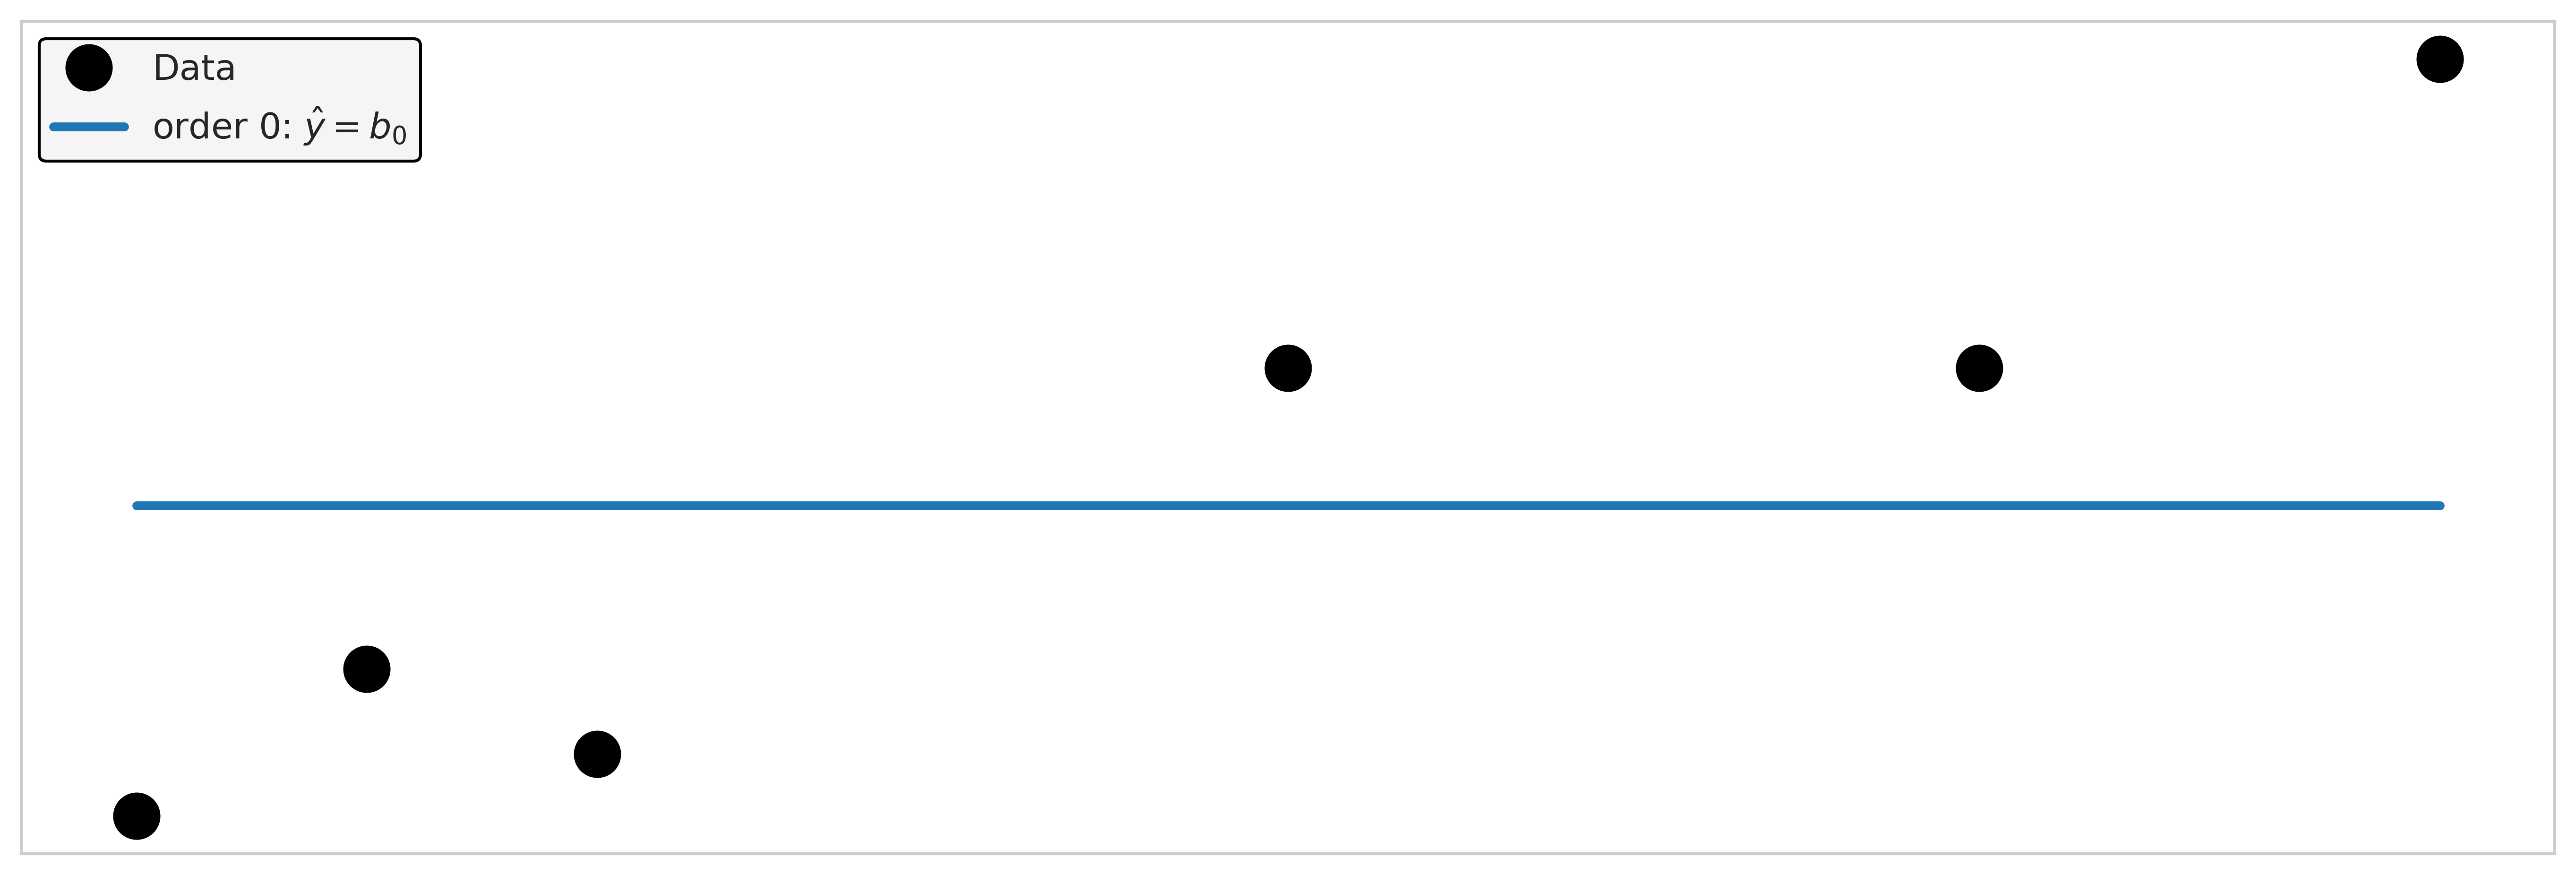

In [4]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))

order = [0]
order_label = [r'$\hat{y} = b_0$']
order_colors = ["#1f77b4"]

ax.plot(x0, y0, "ko", zorder=3, markersize=15, label="Data")


ax.set_yticks([])
ax.set_xticks([])

x_n = np.linspace(x0.min(), x0.max(), 100)
ps = []
for i in order:
    p = np.polynomial.Polynomial.fit(x0, y0, deg=i)
    ps.append(p)
    yhat = p(x0)
    ybar = np.mean(y0)

    ax.plot(x_n, p(x_n), color=order_colors[i], label=f"order {i}: {order_label[i]}", lw=3)


ax.legend(loc=2, fontsize=12, frameon=True, fancybox=True, facecolor="whitesmoke", edgecolor="k", framealpha=1)

### 10.1.09 A model that overfits


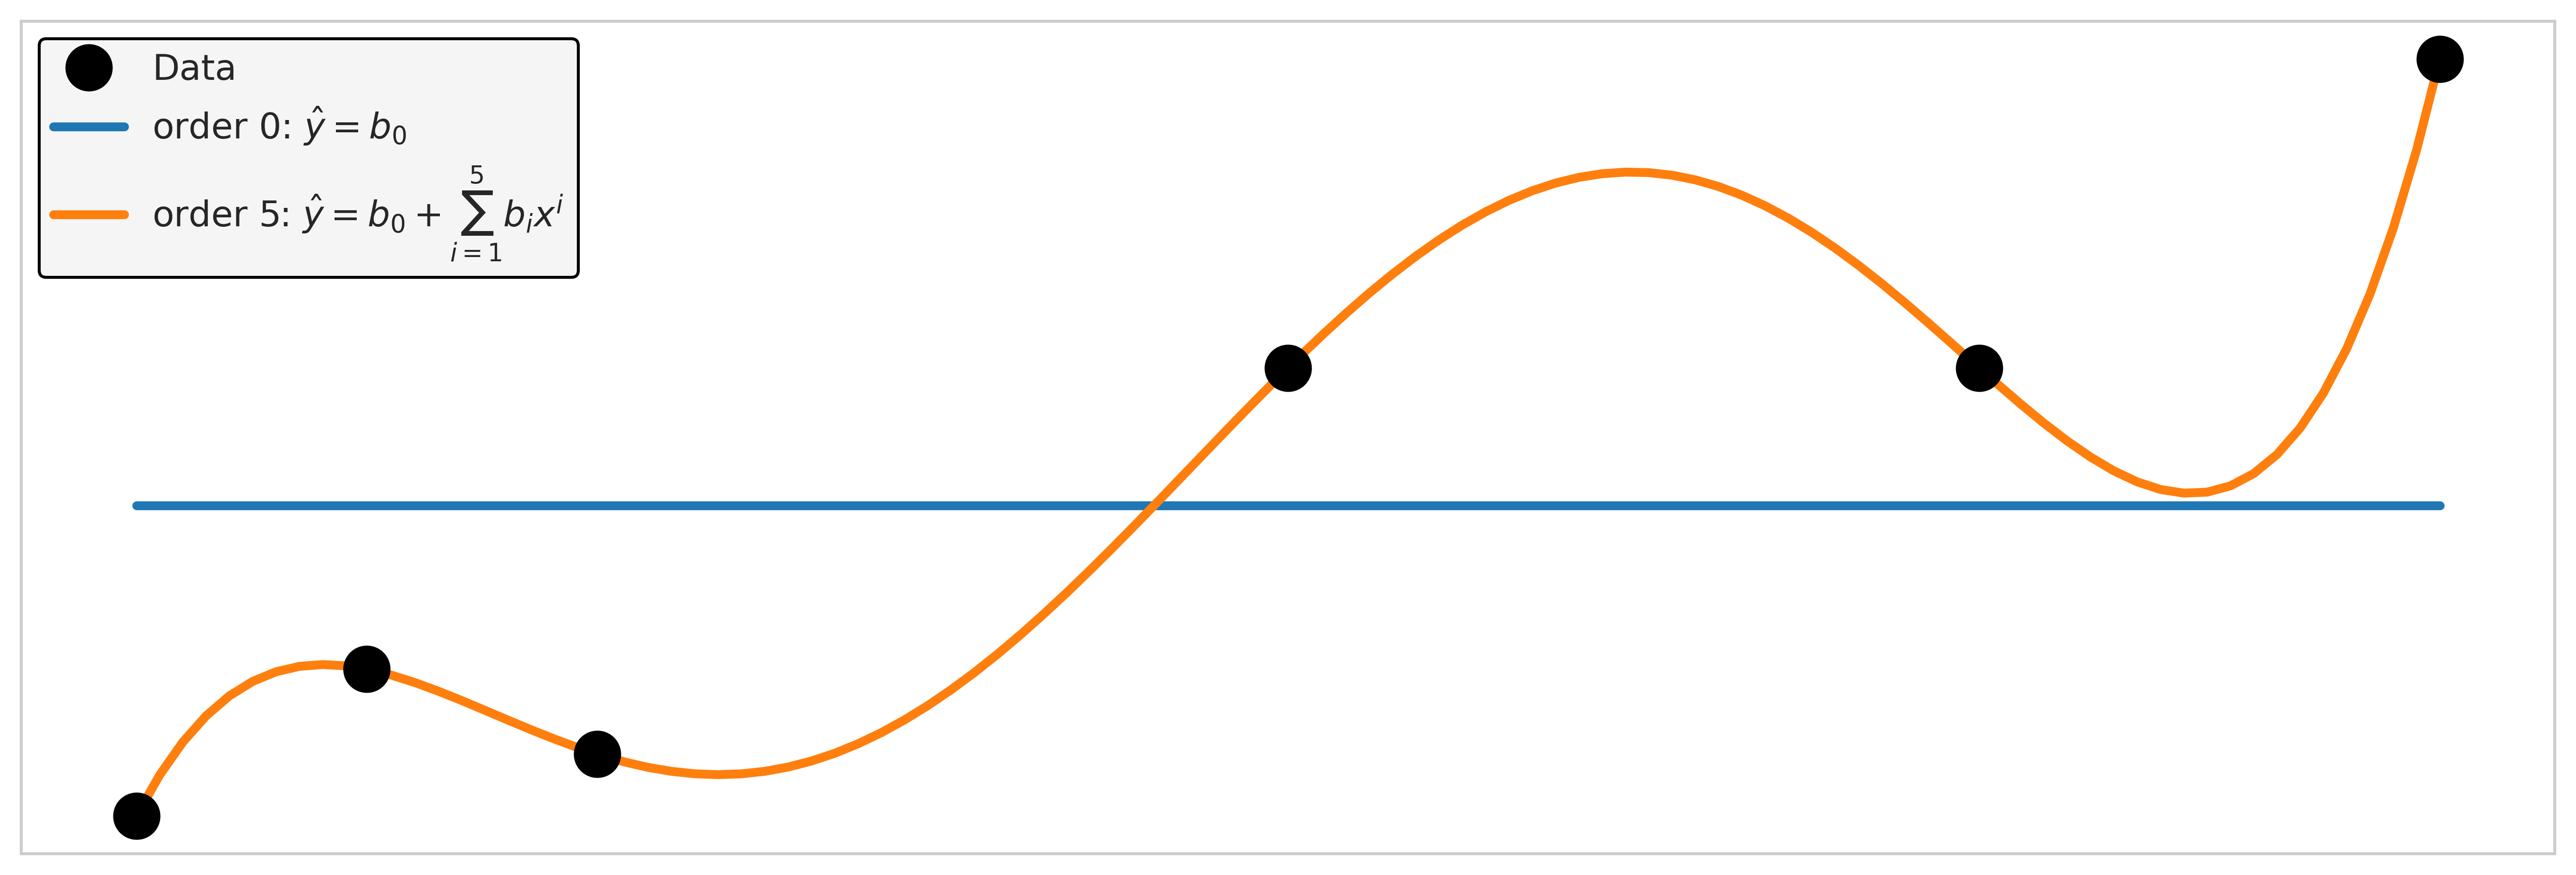

In [5]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))

order = [0, 5]
order_label = [r'$\hat{y} = b_0$', r'$\hat{y} = b_0 + \sum_{i=1}^{5} b_i x^i$']
order_colors = ["#1f77b4", "#ff7f0e"]

ax.plot(x0, y0, "ko", zorder=3, markersize=15, label="Data")


ax.set_yticks([])
ax.set_xticks([])

x_n = np.linspace(x0.min(), x0.max(), 100)
ps = []
for i,o in enumerate(order):
    p = np.polynomial.Polynomial.fit(x0, y0, deg=o)
    ps.append(p)
    yhat = p(x0)
    ybar = np.mean(y0)

    ax.plot(x_n, p(x_n), color=order_colors[i], label=f"order {o}: {order_label[i]}", lw=3)


ax.legend(loc=2, fontsize=12, frameon=True, fancybox=True, facecolor="whitesmoke", edgecolor="k", framealpha=1)

### 10.1.10 A model that balances overfitting and underfitting?


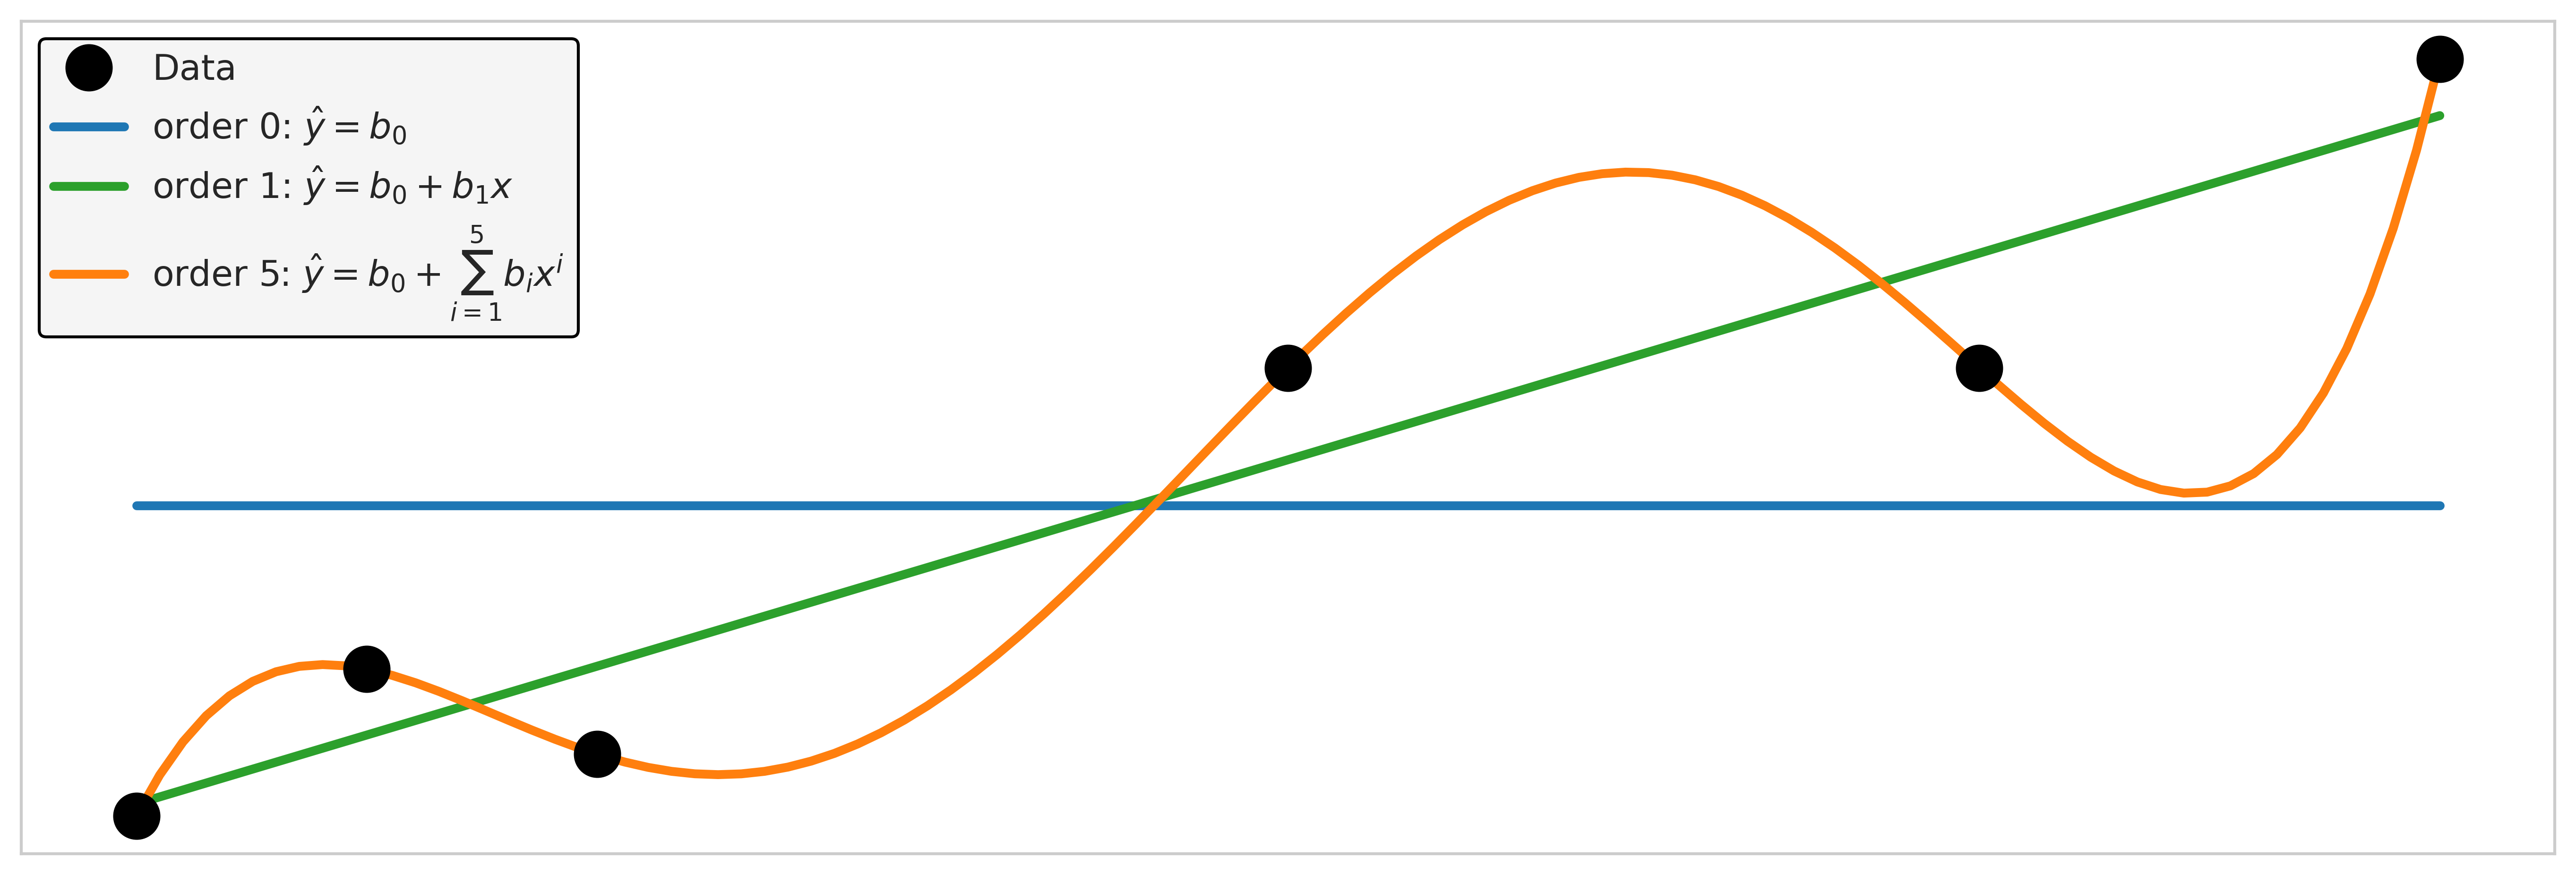

In [6]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))

order = [0, 1, 5]
order_label = [r'$\hat{y} = b_0$', r'$\hat{y} = b_0 + b_1 x$', r'$\hat{y} = b_0 + \sum_{i=1}^{5} b_i x^i$']
order_colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]

ax.plot(x0, y0, "ko", zorder=3, markersize=15, label="Data")


ax.set_yticks([])
ax.set_xticks([])

x_n = np.linspace(x0.min(), x0.max(), 100)
ps = []
for i,o in enumerate(order):
    p = np.polynomial.Polynomial.fit(x0, y0, deg=o)
    ps.append(p)
    yhat = p(x0)
    ybar = np.mean(y0)

    ax.plot(x_n, p(x_n), color=order_colors[i], label=f"order {o}: {order_label[i]}", lw=3)


ax.legend(loc=2, fontsize=12, frameon=True, fancybox=True, facecolor="whitesmoke", edgecolor="k", framealpha=1)

### 10.1.11 R2 increases with the number of parameters


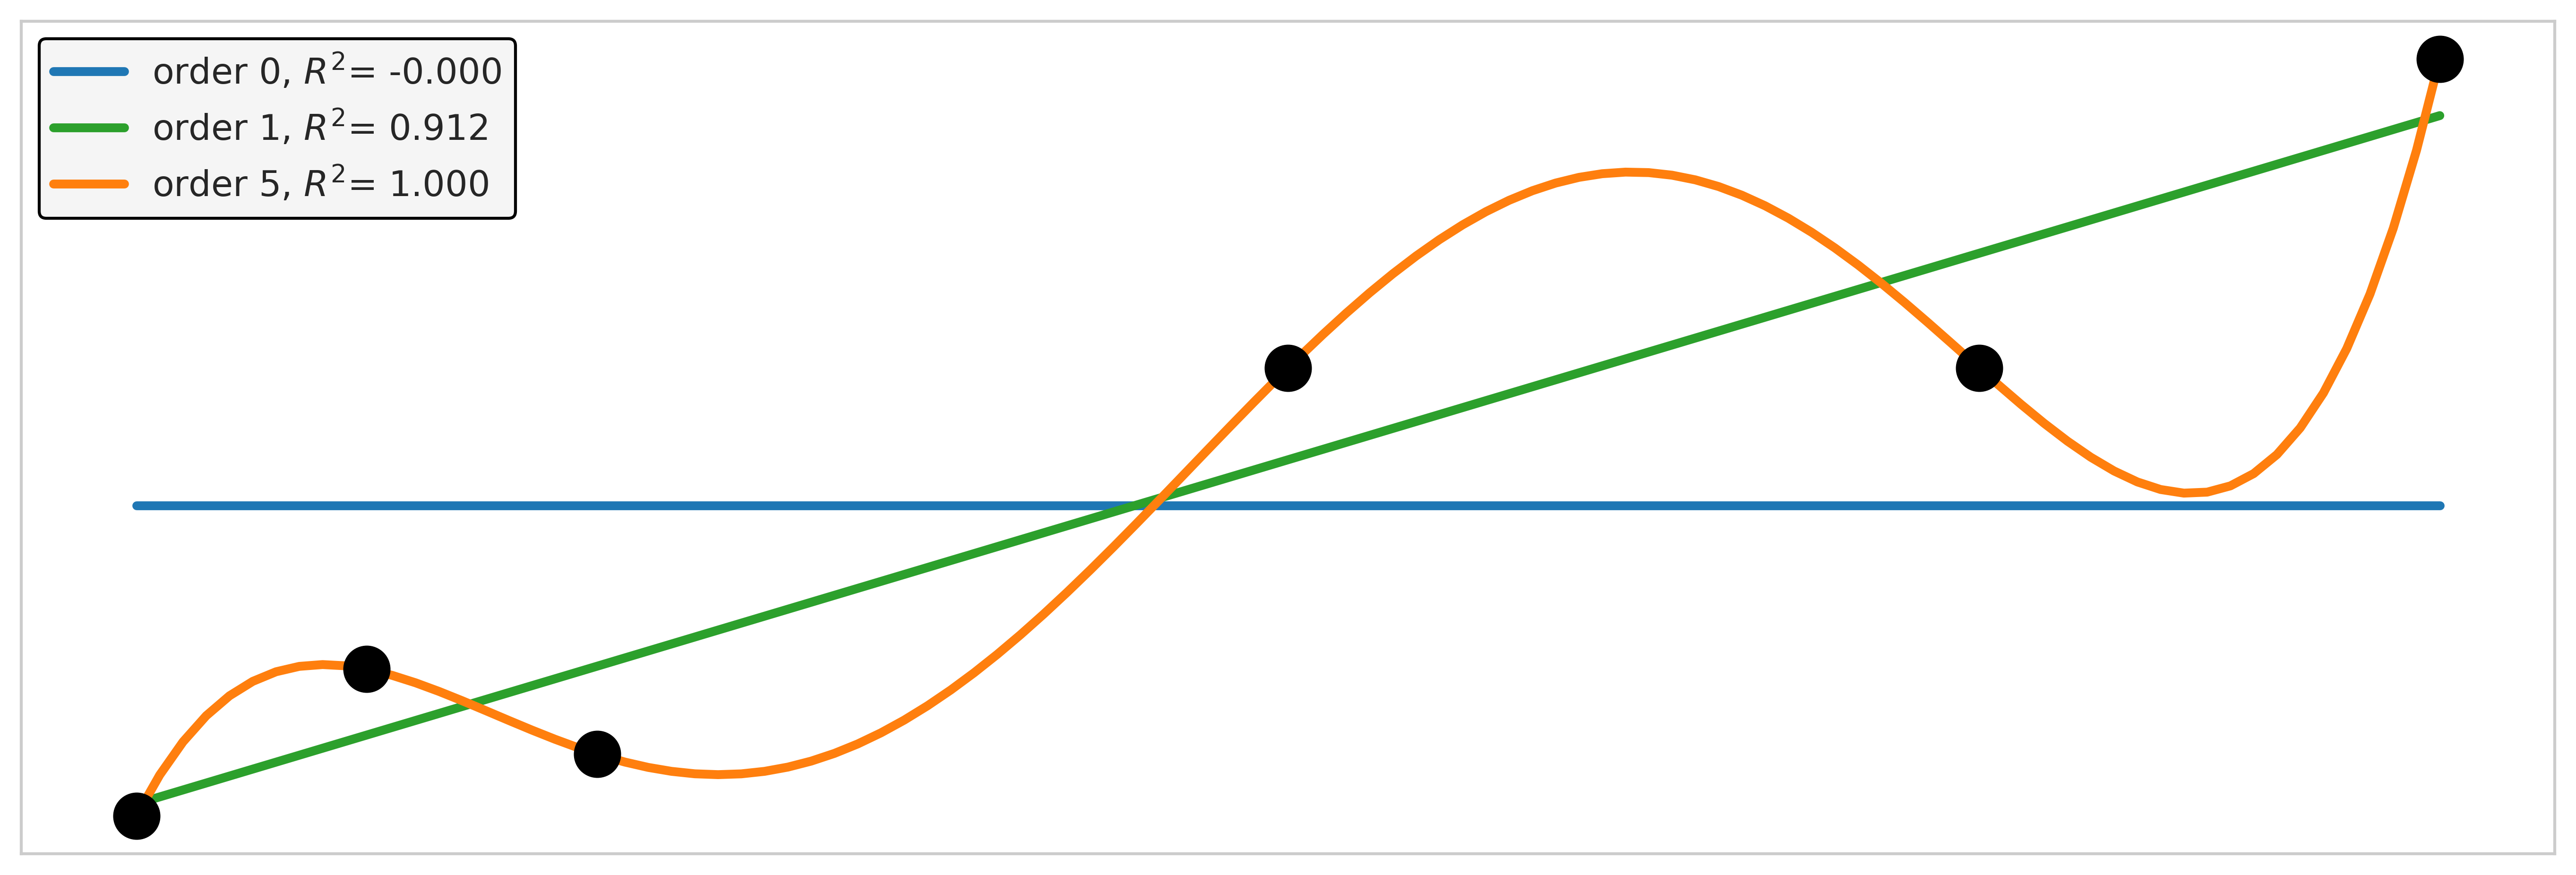

In [7]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))


x0 = np.array([4.0, 5.0, 6.0, 9.0, 12, 14.0])
y0 = np.array([4.2, 6.1, 5.0, 10.0, 10, 14.0])

order = [0, 1, 5]
order_colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]
ax.plot(x0, y0, "ko", markersize=15, zorder=3)


ax.set_yticks([])
ax.set_xticks([])

x_n = np.linspace(x0.min(), x0.max(), 100)
ps = []
for i,o in enumerate(order):
    p = np.polynomial.Polynomial.fit(x0, y0, deg=o)
    ps.append(p)
    yhat = p(x0)
    ybar = np.mean(y0)
    ss_regression = np.sum((yhat - y0) ** 2)
    ss_total = np.sum((ybar - y0) ** 2)
    r2 = 1 - ss_regression / ss_total
    ax.plot(x_n, p(x_n), color=order_colors[i], label=f"order {o}, $R^2$= {r2:.3f}", lw=3)


ax.legend(loc=2, fontsize=12, frameon=True, fancybox=True, facecolor="whitesmoke", edgecolor="k", framealpha=1)

### 10.1.13 Leaving out one data point


D:\Repositories\StatisticalComputationAndAnalysis\.pixi\envs\default\Lib\site-packages\numpy\polynomial\polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
D:\Repositories\StatisticalComputationAndAnalysis\.pixi\envs\default\Lib\site-packages\numpy\polynomial\polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
D:\Repositories\StatisticalComputationAndAnalysis\.pixi\envs\default\Lib\site-packages\numpy\polynomial\polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
D:\Repositories\StatisticalComputationAndAnalysis\.pixi\envs\default\Lib\site-packages\numpy\polynomial\polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
D:\Repositories\StatisticalComputationAndAnalysis\.pixi\envs\default\Lib\site-packages\numpy

C:\Users\User\AppData\Local\Temp\ipykernel_44416\1040789731.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust rect to make space for suptitle if added


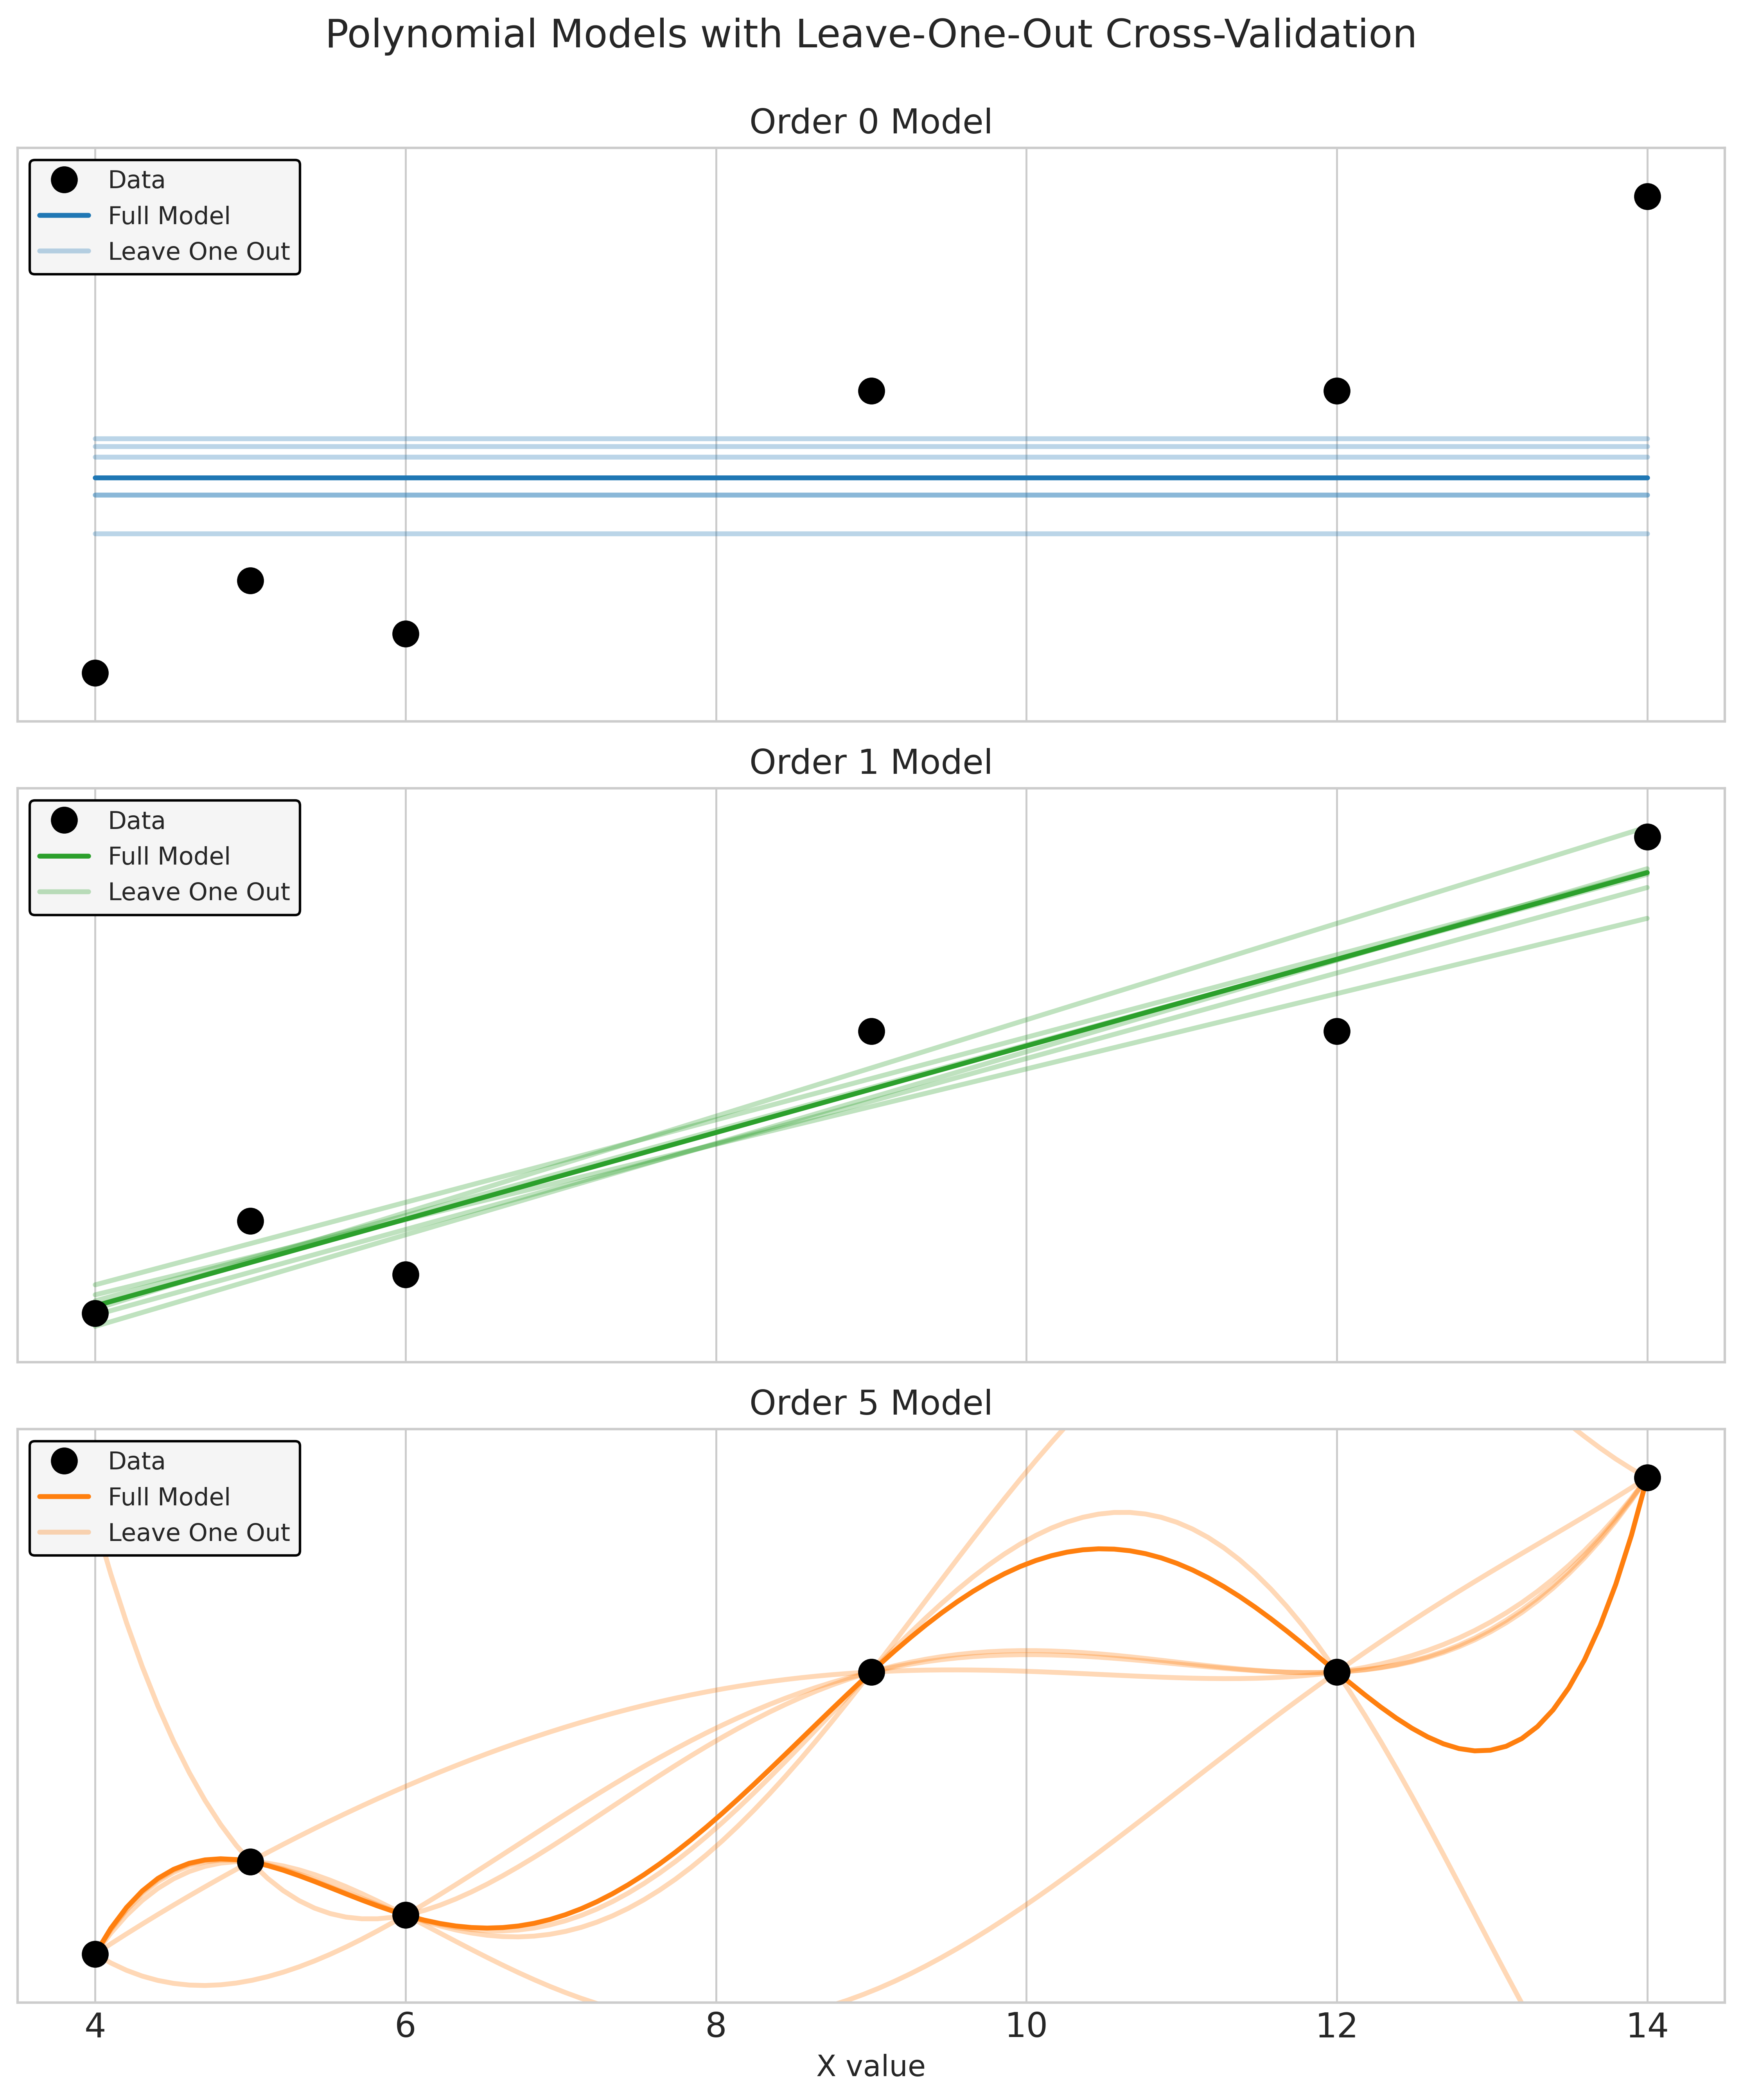

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

x0 = np.array([4.0, 5.0, 6.0, 9.0, 12, 14.0])
y0 = np.array([4.2, 6.1, 5.0, 10.0, 10, 14.0])
n_points = len(x0)

order_values = [0, 1, 5]
order_colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]

x_n = np.linspace(x0.min(), x0.max(), 100)

for idx, (ax, current_order) in enumerate(zip(axes, order_values)):
    color = order_colors[idx]
    ax.plot(x0, y0, "ko", markersize=10, zorder=3, label="Data")

    ax.set_yticks([])
    ax.set_xticks([]) # Keep for top/middle, will be overridden by sharex for bottom if needed
    ax.set_title(f"Order {current_order} Model", fontsize=14)

    # Fit and plot the model on all data
    p_full = np.polynomial.Polynomial.fit(x0, y0, deg=current_order)
    ax.plot(x_n, p_full(x_n), color=color, label="Full Model", lw=2, zorder=2)

    # Fit and plot LOO models
    for k in range(n_points):
        x_loo = np.delete(x0, k)
        y_loo = np.delete(y0, k)
        
        p_loo = np.polynomial.Polynomial.fit(x_loo, y_loo, deg=current_order)
        # Label only the first LOO line
        loo_label = "Leave One Out" if k == 0 else None
        ax.plot(x_n, p_loo(x_n), color=color, lw=2, alpha=0.3, zorder=1, label=loo_label)

    ax.legend(loc='best', fontsize=10, frameon=True, fancybox=True, facecolor="whitesmoke", edgecolor="k", framealpha=1)
    ax.set_ylim([min(y0)-1, max(y0)+1]) # Consistent y-limits for better comparison

if axes.shape[0] > 0: # Set x-label only for the bottom-most plot if plots exist
   axes[-1].set_xticks(np.arange(x0.min(), x0.max()+1, 2)) # Example ticks
   axes[-1].set_xlabel("X value", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust rect to make space for suptitle if added
fig.suptitle("Polynomial Models with Leave-One-Out Cross-Validation", fontsize=16, y=0.99)
plt.show()

<a id="section-103"></a>
## 10.3 Kullback-Leibler divergence

Models that are closer to being the true model predict better.


### 10.3.22 We do not have the true model

Our candidate models live in a constrained space of possible approximations. The true data-generating process is outside that space, so model comparison is about useful closeness rather than finding the one true model.

<svg viewBox="0 0 680 470" width="680" role="img" aria-label="A true model point above a plane of possible models, with one candidate model and a distance to the true model" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arrowhead-10534" markerWidth="10" markerHeight="8" refX="8" refY="4" orient="auto">
      <path d="M 0 0 L 10 4 L 0 8 z" fill="#111" />
    </marker>
    <style>
      .axis-10534 { stroke: #111; stroke-width: 3; fill: none; marker-end: url(#arrowhead-10534); }
      .plane-10534 { fill: #5fb8bd; fill-opacity: 0.42; stroke: #5fb8bd; stroke-width: 2; }
      .plane-label-10534 { fill: #007c84; font-family: Georgia, serif; font-size: 34px; }
      .true-label-10534 { fill: #e11; font-family: Georgia, serif; font-size: 34px; }
      .distance-10534 { stroke: #111; stroke-width: 4; stroke-linecap: round; stroke-dasharray: 10 13; }
    </style>
  </defs>
  <line class="axis-10534" x1="190" y1="310" x2="645" y2="390" />
  <line class="axis-10534" x1="190" y1="310" x2="190" y2="30" />
  <line class="axis-10534" x1="190" y1="310" x2="45" y2="455" />
  <polygon class="plane-10534" points="170,270 550,235 555,315 200,370" />
  <text class="plane-label-10534" x="140" y="305">Possible Models</text>
  <ellipse cx="315" cy="145" rx="14" ry="8" fill="#e11" />
  <text class="true-label-10534" x="330" y="130">True Model</text>
  <ellipse cx="425" cy="300" rx="15" ry="8" fill="#ff7f24" />
  <line class="distance-10534" x1="315" y1="145" x2="425" y2="300" />
</svg>


### 10.3.23 A distance measure might help

The true data-generating process is not one of our candidate models. We can still compare candidate models by asking which one is closer to that unknown target.

<svg viewBox="0 0 680 470" width="680" role="img" aria-label="A true model point above a plane of possible models, with two candidate models and distances to the true model" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arrowhead" markerWidth="10" markerHeight="8" refX="8" refY="4" orient="auto">
      <path d="M 0 0 L 10 4 L 0 8 z" fill="#111" />
    </marker>
    <style>
      .axis { stroke: #111; stroke-width: 3; fill: none; marker-end: url(#arrowhead); }
      .plane { fill: #5fb8bd; fill-opacity: 0.42; stroke: #5fb8bd; stroke-width: 2; }
      .plane-label { fill: #007c84; font-family: Georgia, serif; font-size: 34px; }
      .true-label { fill: #e11; font-family: Georgia, serif; font-size: 34px; }
      .model-label { fill: #ff7f24; font-family: Georgia, serif; font-style: italic; font-size: 28px; }
      .distance-label { fill: #111; font-family: Georgia, serif; font-style: italic; font-size: 28px; }
      .distance { stroke: #ff7f24; stroke-width: 4; stroke-linecap: round; stroke-dasharray: 2 13; }
    </style>
  </defs>
  <line class="axis" x1="190" y1="310" x2="645" y2="390" />
  <line class="axis" x1="190" y1="310" x2="190" y2="30" />
  <line class="axis" x1="190" y1="310" x2="45" y2="455" />
  <polygon class="plane" points="170,260 520,210 550,320 200,375" />
  <text class="plane-label" x="140" y="300">Possible Models</text>
  <ellipse cx="310" cy="145" rx="13" ry="8" fill="#e11" />
  <text class="true-label" x="330" y="130">True Model</text>
  <ellipse cx="365" cy="302" rx="14" ry="8" fill="#ff7f24" />
  <ellipse cx="495" cy="255" rx="14" ry="8" fill="#ff7f24" />
  <line class="distance" x1="310" y1="145" x2="365" y2="302" />
  <line class="distance" x1="310" y1="145" x2="495" y2="255" />
  <text class="distance-label" x="315" y="235">d<tspan baseline-shift="sub" font-size="18">1</tspan></text>
  <text class="distance-label" x="425" y="235">d<tspan baseline-shift="sub" font-size="18">2</tspan></text>
  <text class="model-label" x="300" y="335">m<tspan baseline-shift="sub" font-size="18">1</tspan></text>
  <text class="model-label" x="460" y="290">m<tspan baseline-shift="sub" font-size="18">2</tspan></text>
</svg>


### Extra material: Mermaid version of the distance diagram

This version is easier to edit than the SVG, but it is more schematic. Mermaid is good for conceptual relationships; it is less natural for geometric drawings with planes and 3D axes.

```mermaid
%%{init: {"flowchart": {"curve": "linear"}}}%%
flowchart TB
    T((Reality))

    subgraph Models[Possible Models]
        direction LR
        M1((m1))
        M2((m2))
    end

    T -.->|d1| M1
    T -.->|d2| M2

    classDef trueModel fill:#ff1f1f,stroke:#ff1f1f,color:#ffffff;
    classDef candidate fill:#ff7f24,stroke:#ff7f24,color:#ffffff;
    style Models fill:#d6eeee,stroke:#5fb8bd,color:#007c84;

    class T trueModel;
    class M1,M2 candidate;
```


### Extra material: Single-model Mermaid version of the distance diagram

This version has only one model.

```mermaid
%%{init: {"flowchart": {"curve": "linear"}}}%%
flowchart TB
    T((Reality))

    subgraph Models[Possible Models]
        direction LR
        M1((m1))
    end

    T -.-> |d| M1

    classDef trueModel fill:#ff1f1f,stroke:#ff1f1f,color:#ffffff;
    classDef candidate fill:#ff7f24,stroke:#ff7f24,color:#ffffff;
    style Models fill:#d6eeee,stroke:#5fb8bd,color:#007c84;

    class T trueModel;
    class M1 candidate;
```


### 10.3.25 Surprise connects probability and prediction


Surprise for $p = [0.1, 0.8, 0.1]$: 0.64
Surprise for $p = [0.1, 0.4, 0.5]$: 0.94
Surprise for $p = [0.333, 0.333, 0.333]$: 1.10


C:\Users\User\AppData\Local\Temp\ipykernel_44416\13895143.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


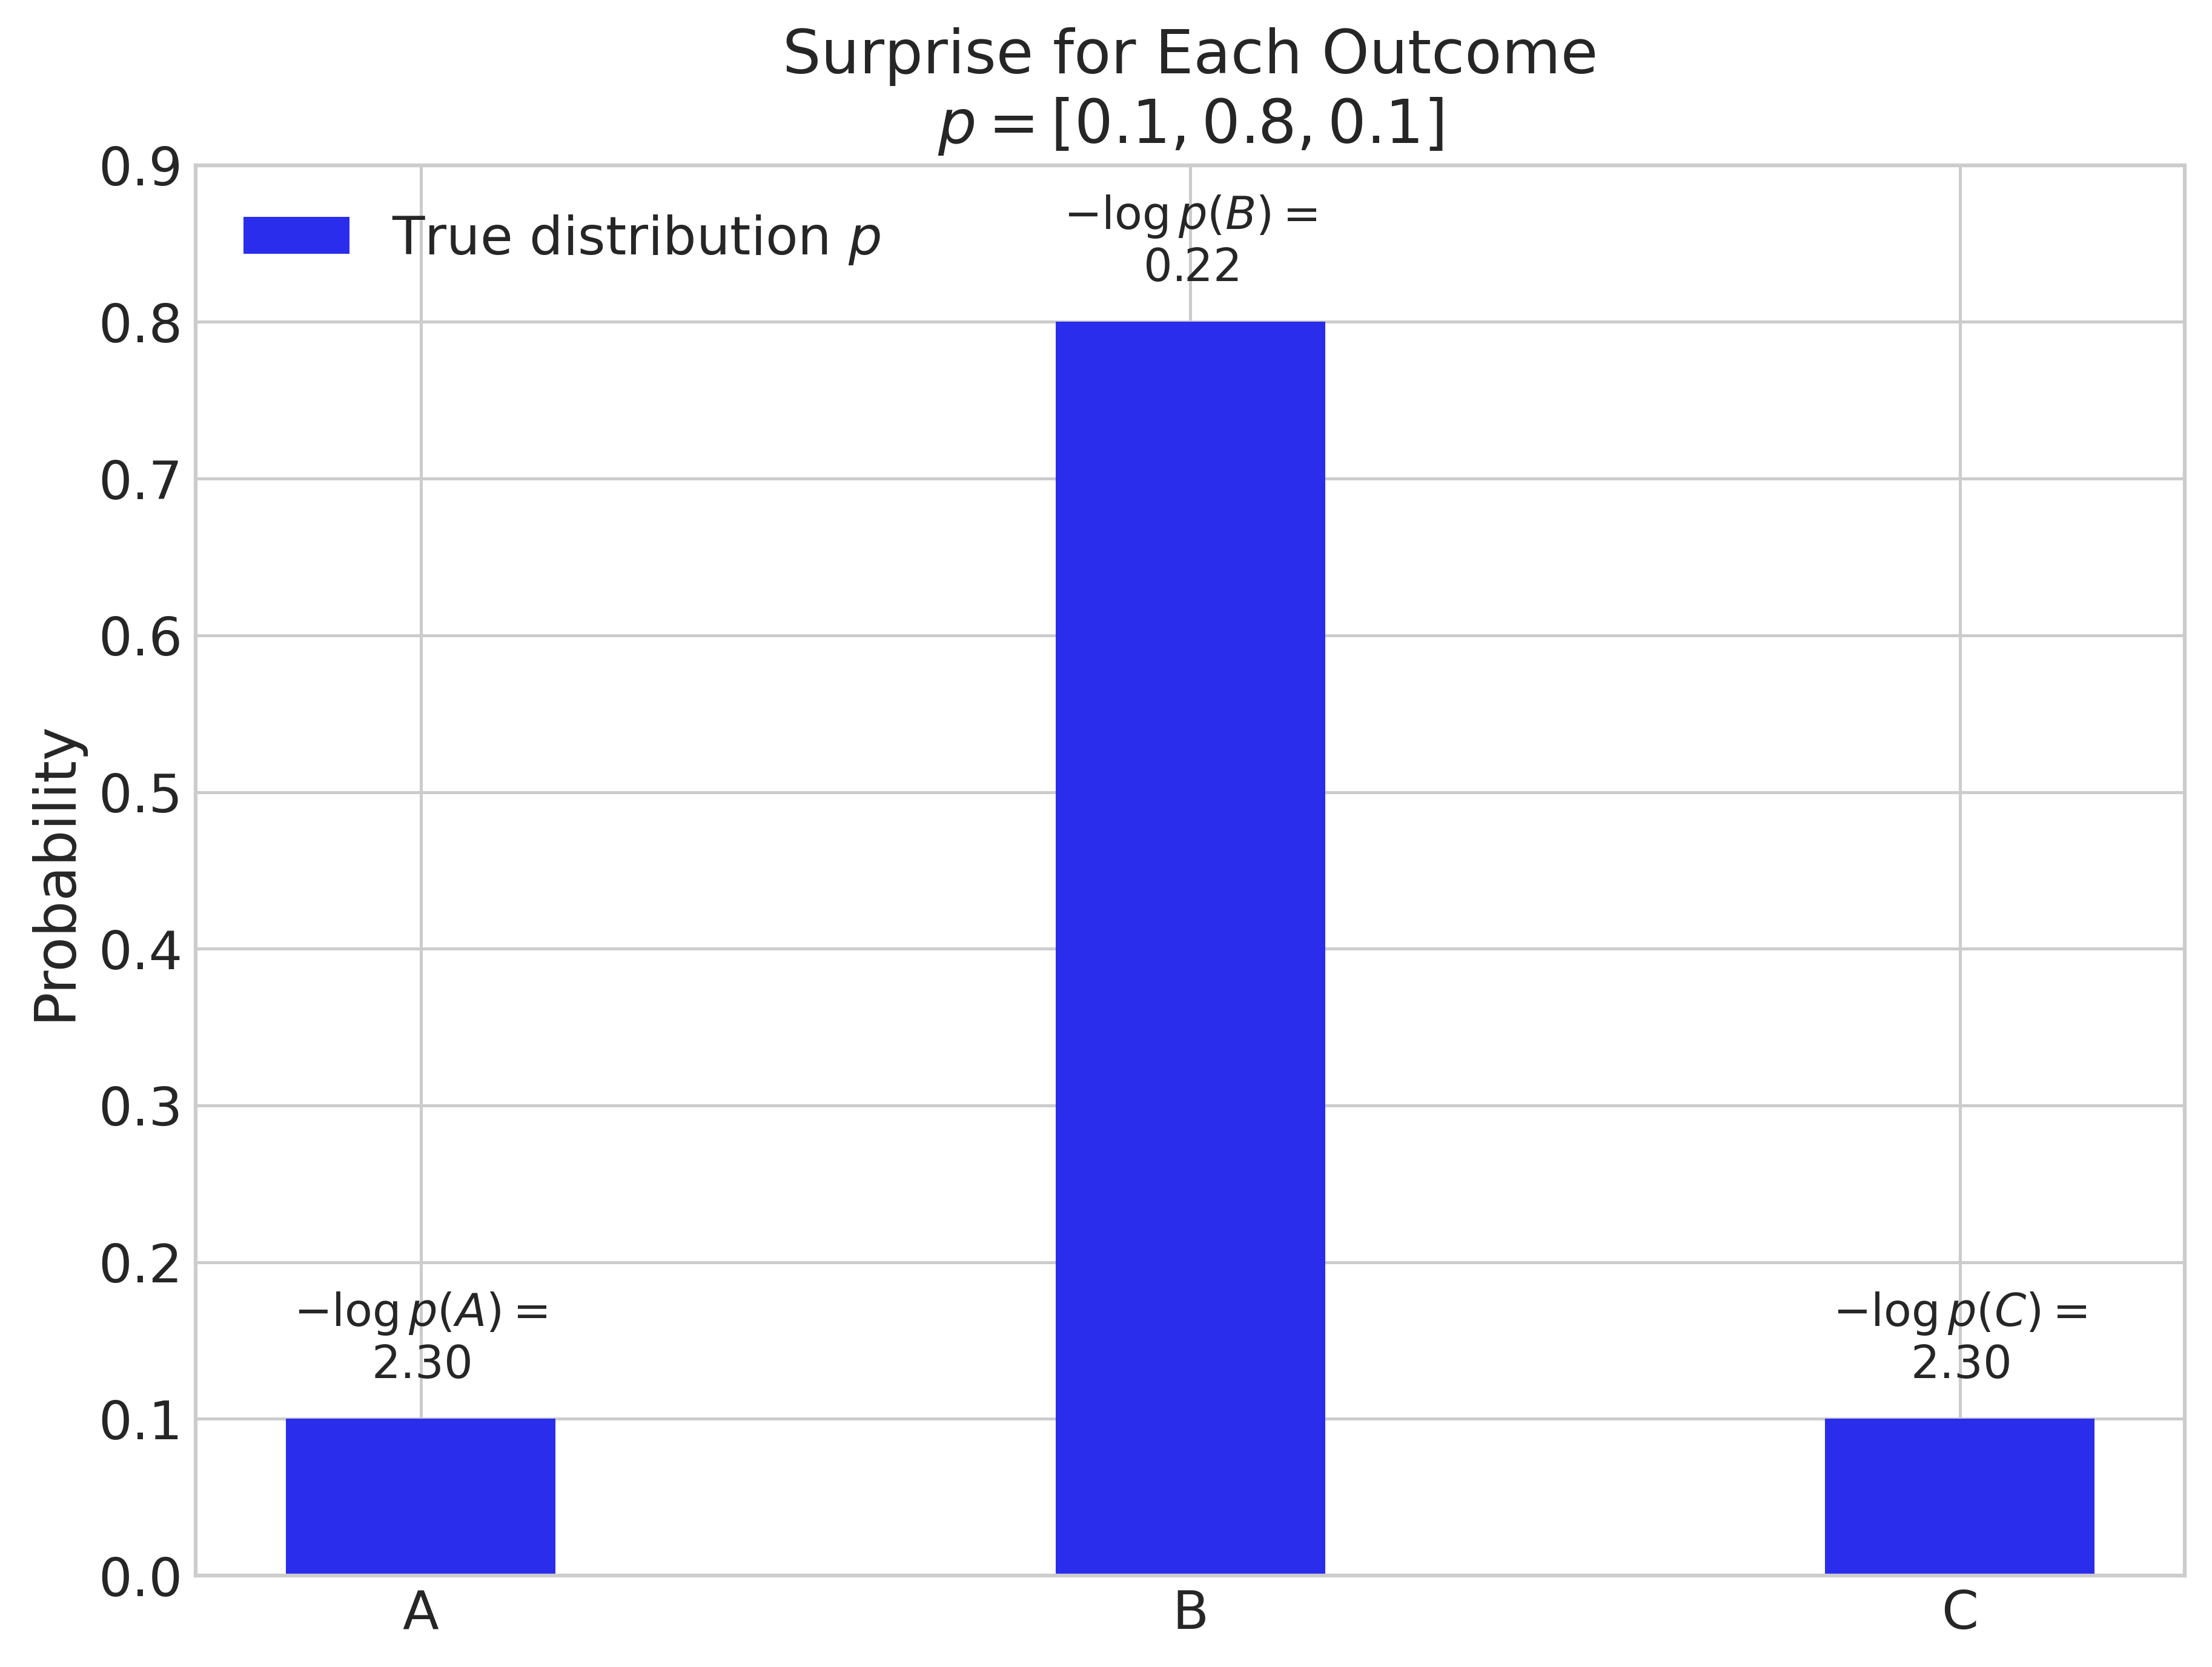

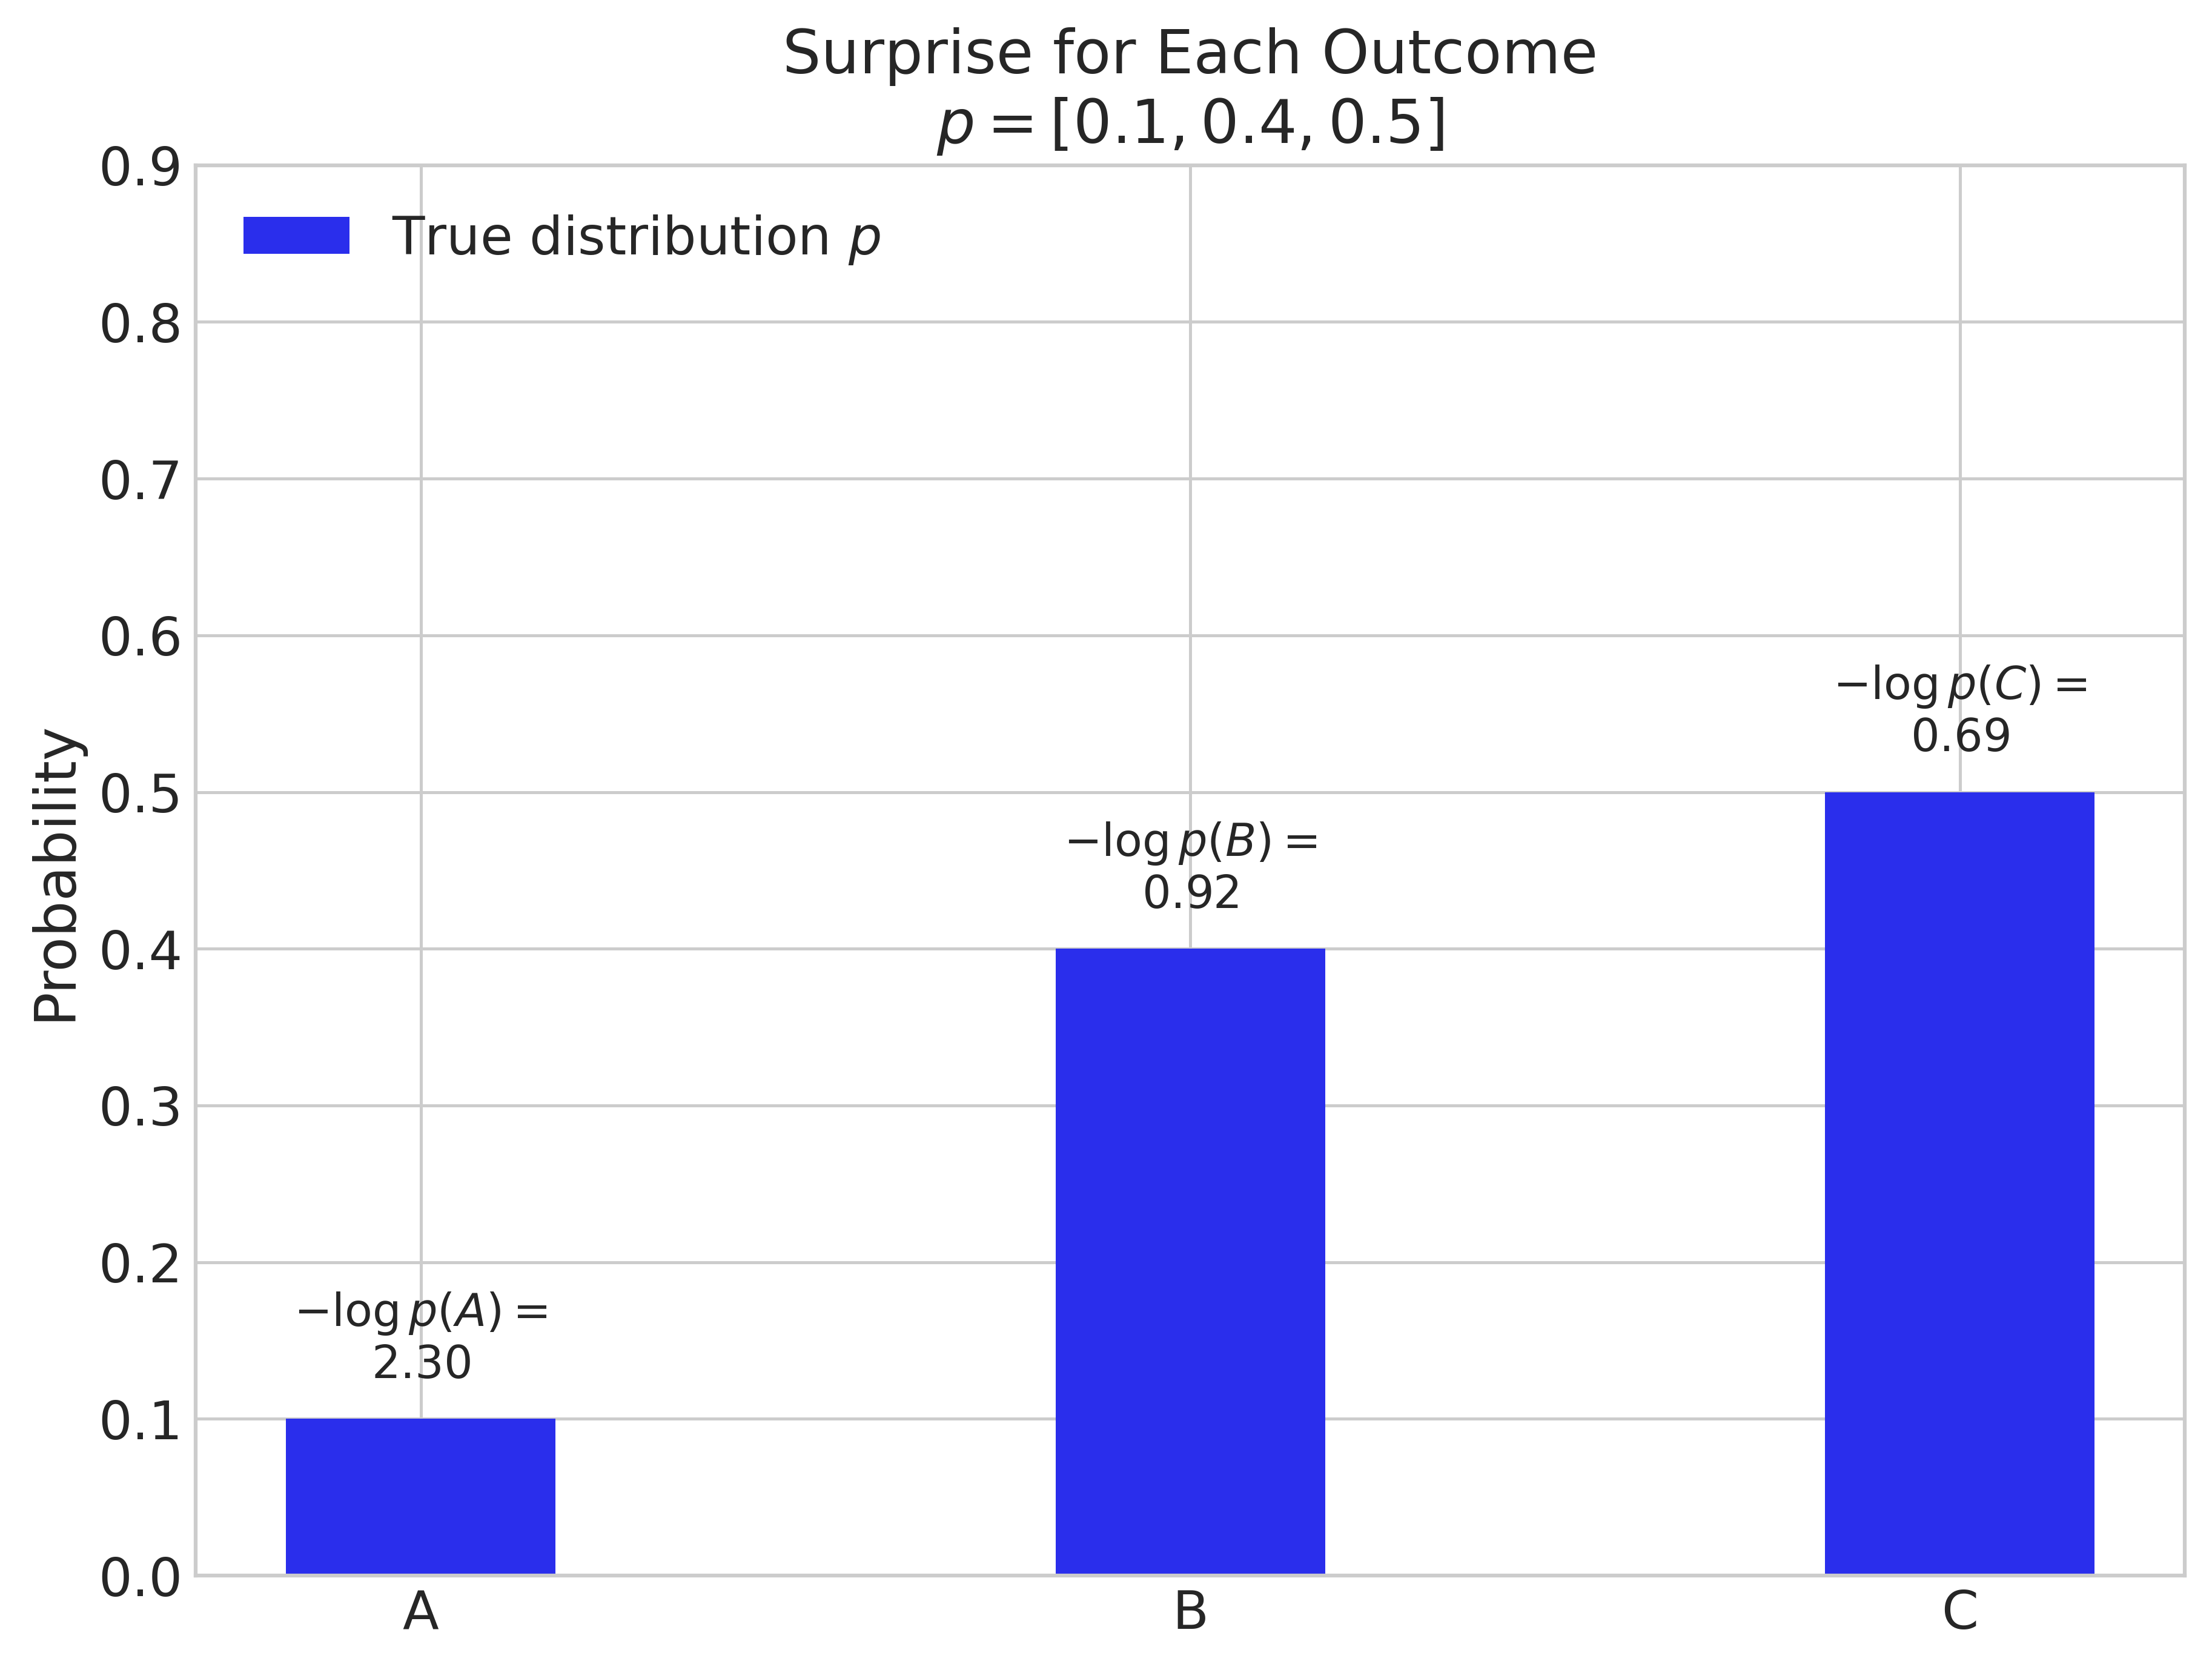

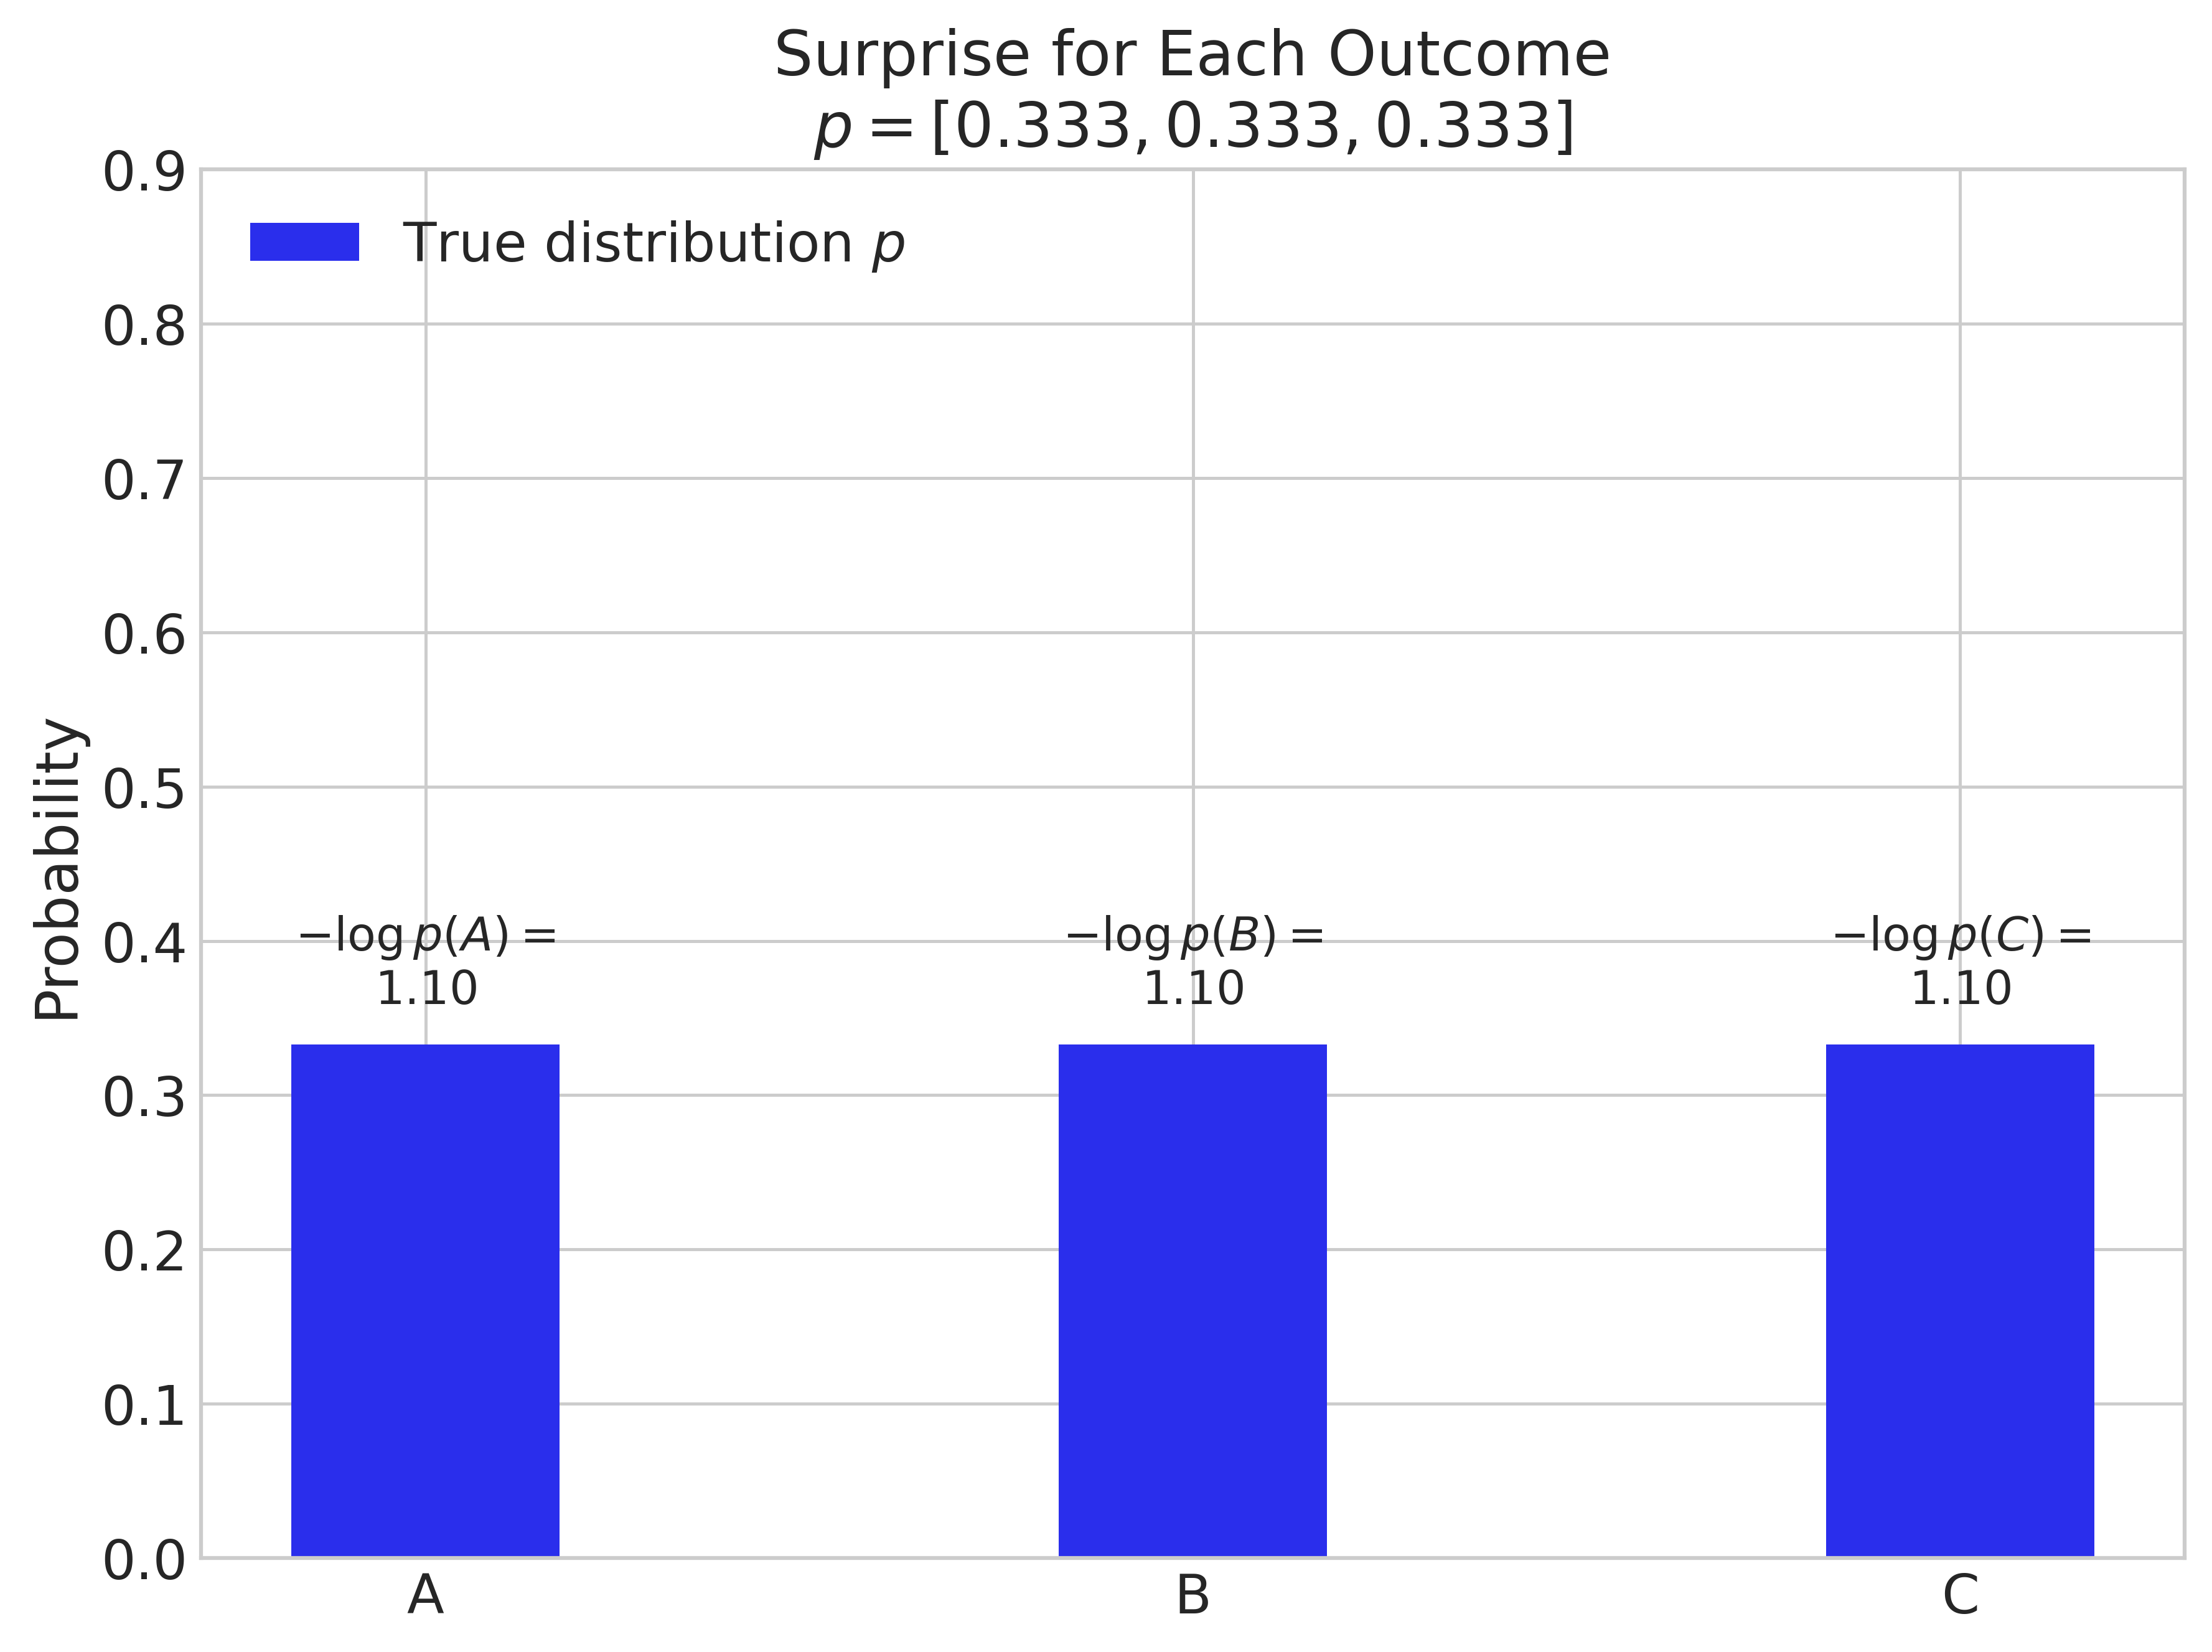

In [9]:
# Introductory examples: surprise under different true distributions
p_distributions = [
    (np.array([0.1, 0.8, 0.1]), "$p = [0.1, 0.8, 0.1]$"),
    (np.array([0.1, 0.4, 0.5]), "$p = [0.1, 0.4, 0.5]$"),
    (np.array([0.333, 0.333, 0.333]), "$p = [0.333, 0.333, 0.333]$"),
]
labels = ['A', 'B', 'C']

x = np.arange(len(labels))
width = 0.35



for ax, (p_intro, title) in zip(axes, p_distributions):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    surprise_p_intro = -np.log(p_intro)

    ax.bar(x, p_intro, width, label='True distribution $p$')

    for i in range(len(p_intro)):
        ax.text(
            x[i],
            p_intro[i] + 0.02,
            f'$-\\log p({labels[i]}) =$\n${surprise_p_intro[i]:.2f}$',
            ha='center',
            va='bottom',
            fontsize=12,
        )

    ax.set_xticks(x)
    ax.set_ylim(0, 0.9)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Probability')
    ax.set_title(f'Surprise for Each Outcome\n{title}')
    ax.legend(loc='upper left')

    print(f"Surprise for {title}: {np.sum(p_intro * surprise_p_intro):.2f}")

plt.tight_layout()
plt.show()


### 10.3.27 Cross-entropy is surprise for wrong guesses


C:\Users\User\AppData\Local\Temp\ipykernel_44416\1252657295.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


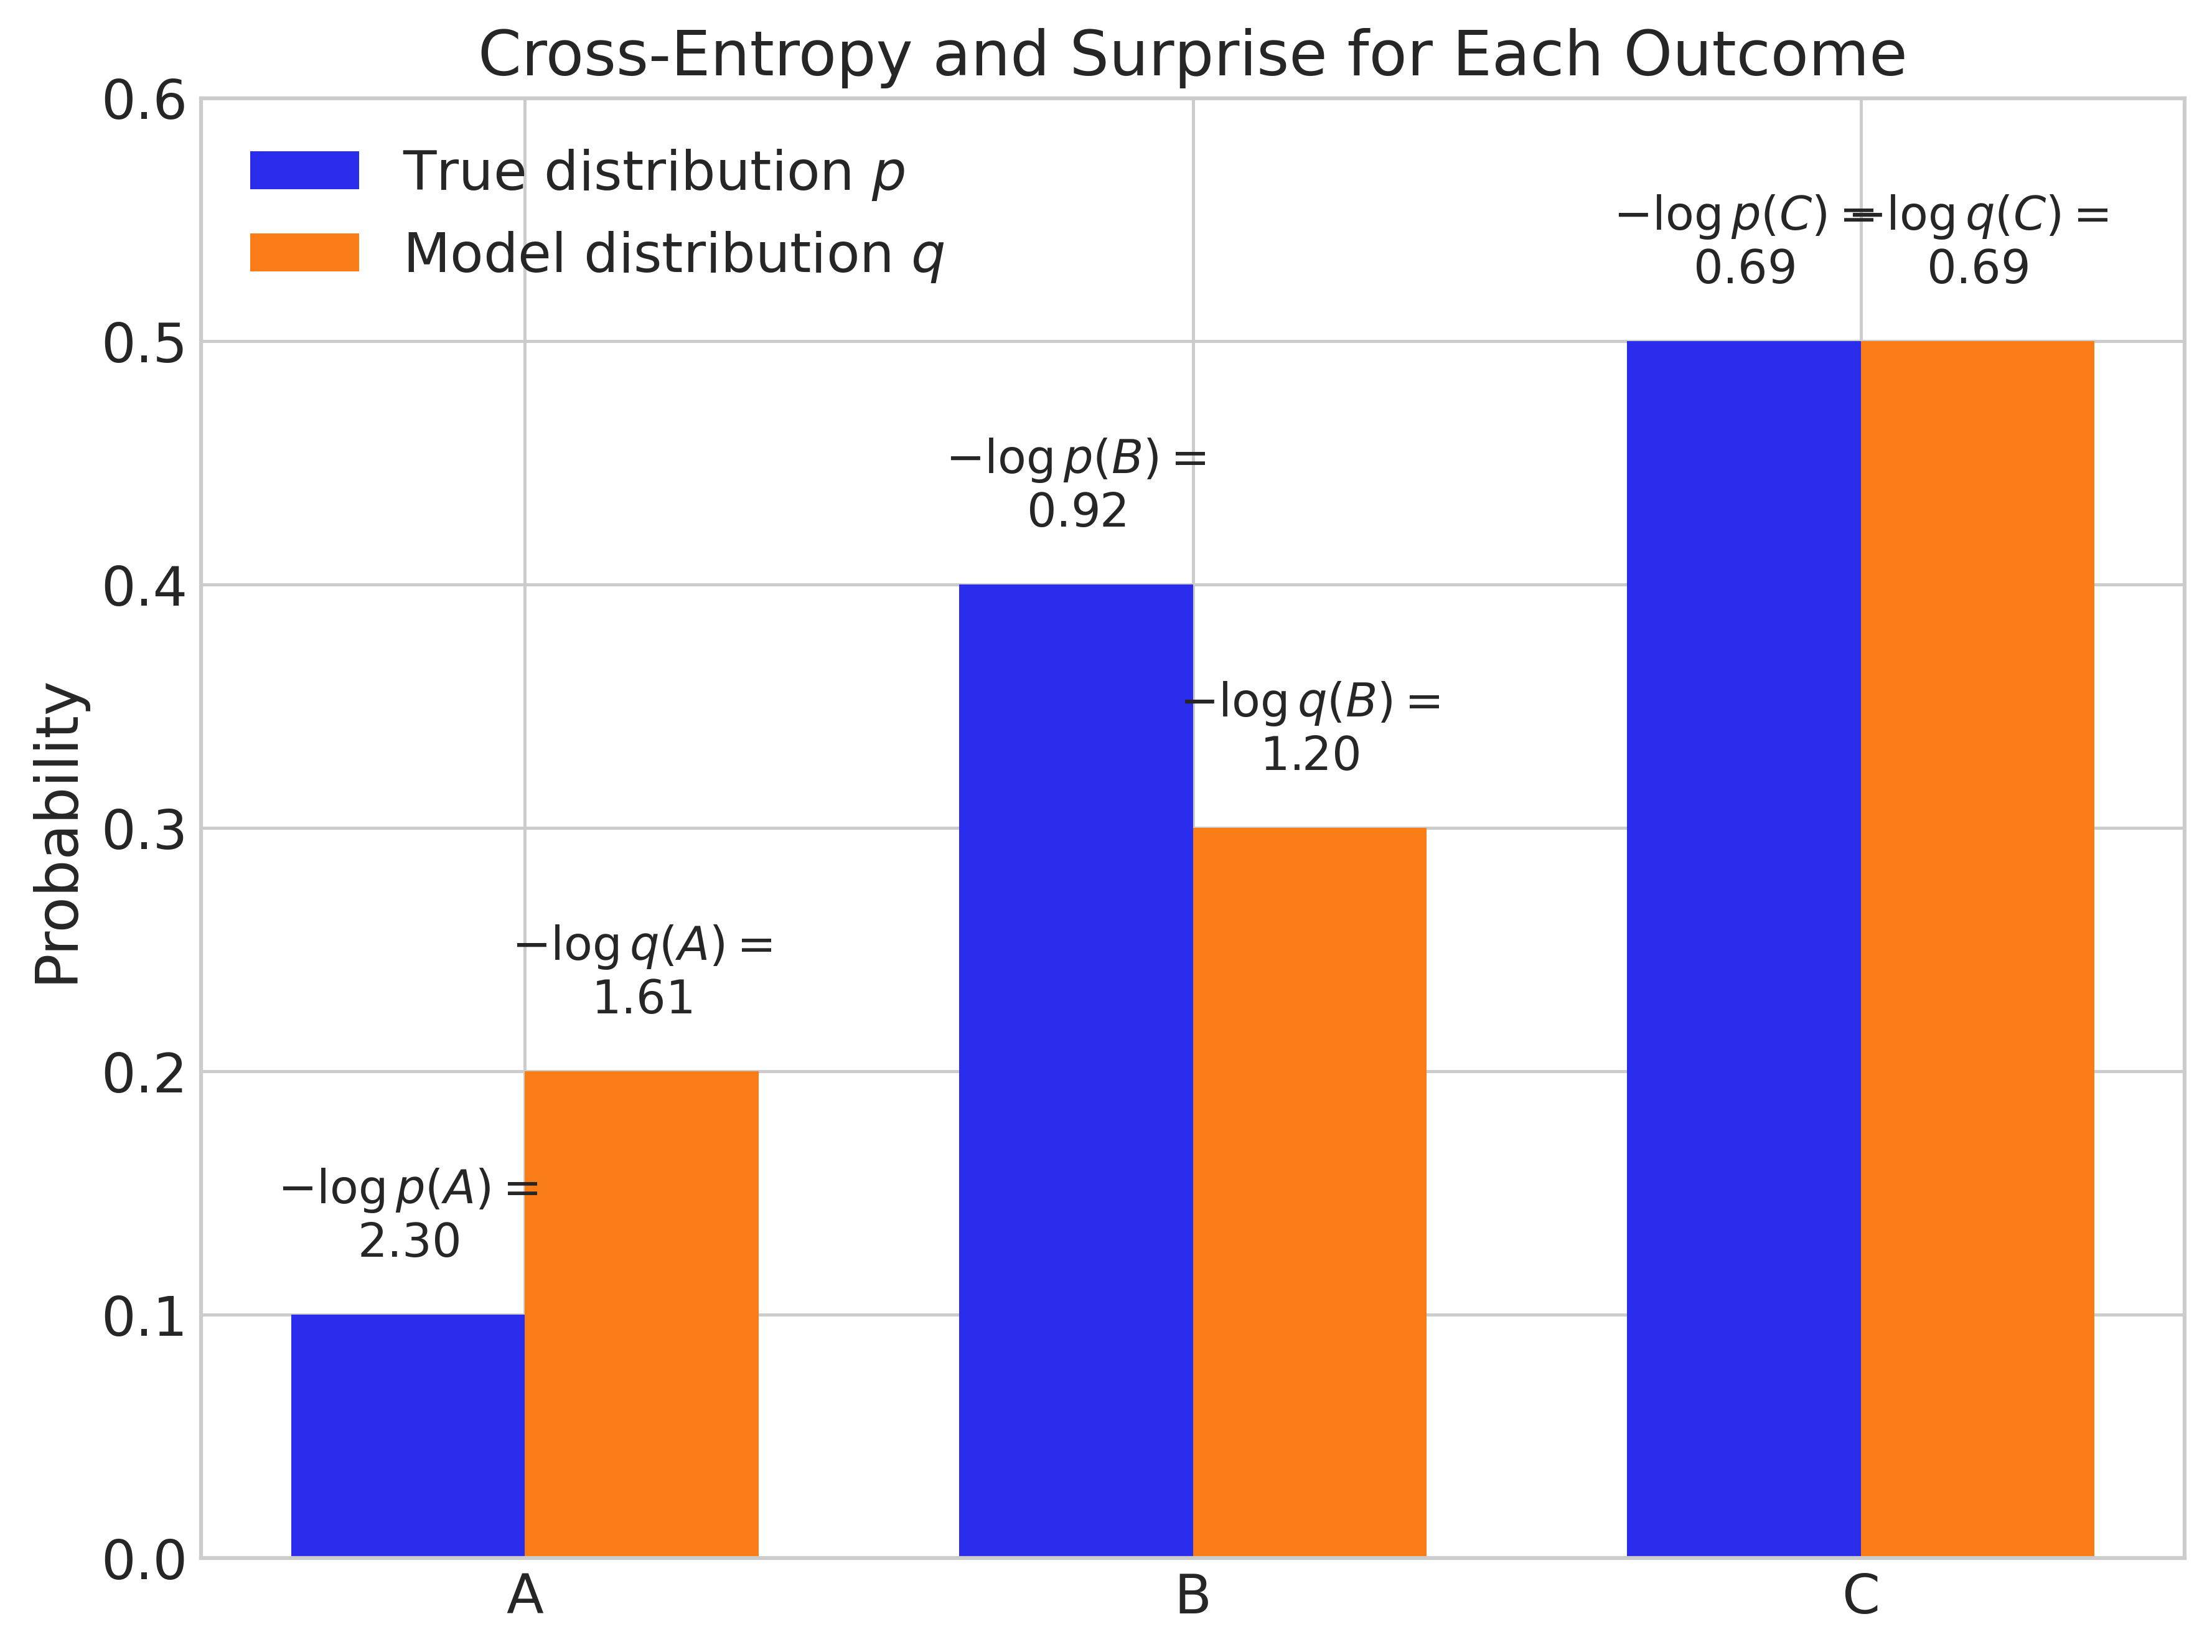

In [10]:
# Example discrete distributions
p = np.array([0.1, 0.4, 0.5])
q = np.array([0.2, 0.3, 0.5])
labels = ['A', 'B', 'C']

# Compute cross-entropy H(p, q)
cross_entropy = -np.sum(p * np.log(q))

# Compute surprise for each outcome
surprise_p = -np.log(p)
surprise_q = -np.log(q)

# Prepare bar positions
x = np.arange(len(p))
width = 0.35

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, p, width, label='True distribution $p$')
ax.bar(x + width/2, q, width, label='Model distribution $q$')

# Annotate the overall cross-entropy
# ax.text(0.5, 1.05,
#         f'Cross-entropy $H(p, q) = {cross_entropy:.2f}$',
#         transform=ax.transAxes,
#         ha='center',
#         fontsize=12)

# Annotate surprise values above each bar
for i in range(len(p)):
    ax.text(x[i] - width/2,
            p[i] + 0.02,
            f'$-\\log p({labels[i]}) =$\n${surprise_p[i]:.2f}$',
            ha='center',
            va='bottom',
            fontsize=12)
    ax.text(x[i] + width/2,
            q[i] + 0.02,
            f'$-\\log q({labels[i]}) =$\n${surprise_q[i]:.2f}$',
            ha='center',
            va='bottom',
            fontsize=12)

# Formatting
ax.set_xticks(x)
ax.set_ylim(0, 0.6)
ax.set_xticklabels(labels)
ax.set_ylabel('Probability')
ax.set_title('Cross-Entropy and Surprise for Each Outcome')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


<a id="section-104"></a>
## 10.4 Information criteria

Methods for approximating the score without getting new data.


### 10.4.39 Comparing different models

We compare three candidate models for penguin body mass. The Bambi objects define the Bayesian candidate models; for AIC we use the matching frequentist Gaussian linear models from `statsmodels`, which is the formula-based frequentist package used in the earlier lecture and tutorial notebooks.


In [11]:
penguins_model_df = load_penguins().dropna(subset=["body_mass_g", "species", "sex"]).copy()
penguins_model_df["species"] = pd.Categorical(
    penguins_model_df["species"],
    categories=["Adelie", "Chinstrap", "Gentoo"],
    ordered=True,
)
penguins_model_df["sex"] = pd.Categorical(
    penguins_model_df["sex"].str.lower(),
    categories=["female", "male"],
    ordered=True,
)
penguins_model_df = penguins_model_df.dropna(subset=["species", "sex"]).reset_index(drop=True)

penguin_models = {
    "species": bmb.Model(
        "body_mass_g ~ species",
        data=penguins_model_df,
        family="gaussian",
    ),
    "species + sex": bmb.Model(
        "body_mass_g ~ species + sex",
        data=penguins_model_df,
        family="gaussian",
    ),
    "species * sex": bmb.Model(
        "body_mass_g ~ species * sex",
        data=penguins_model_df,
        family="gaussian",
    ),
}

penguin_formulae = {
    "species": "body_mass_g ~ species",
    "species + sex": "body_mass_g ~ species + sex",
    "species * sex": "body_mass_g ~ species * sex",
}
penguin_ols_fits = {
    name: smf.ols(formula, data=penguins_model_df).fit()
    for name, formula in penguin_formulae.items()
}

penguin_prediction_grid = pd.DataFrame(
    [
        {"species": species, "sex": sex}
        for species in penguins_model_df["species"].cat.categories
        for sex in penguins_model_df["sex"].cat.categories
    ]
)
penguin_prediction_grid["species"] = pd.Categorical(
    penguin_prediction_grid["species"],
    categories=penguins_model_df["species"].cat.categories,
    ordered=True,
)
penguin_prediction_grid["sex"] = pd.Categorical(
    penguin_prediction_grid["sex"],
    categories=penguins_model_df["sex"].cat.categories,
    ordered=True,
)


C:\Users\User\AppData\Local\Temp\ipykernel_44416\1058574031.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.12, 1, 1])


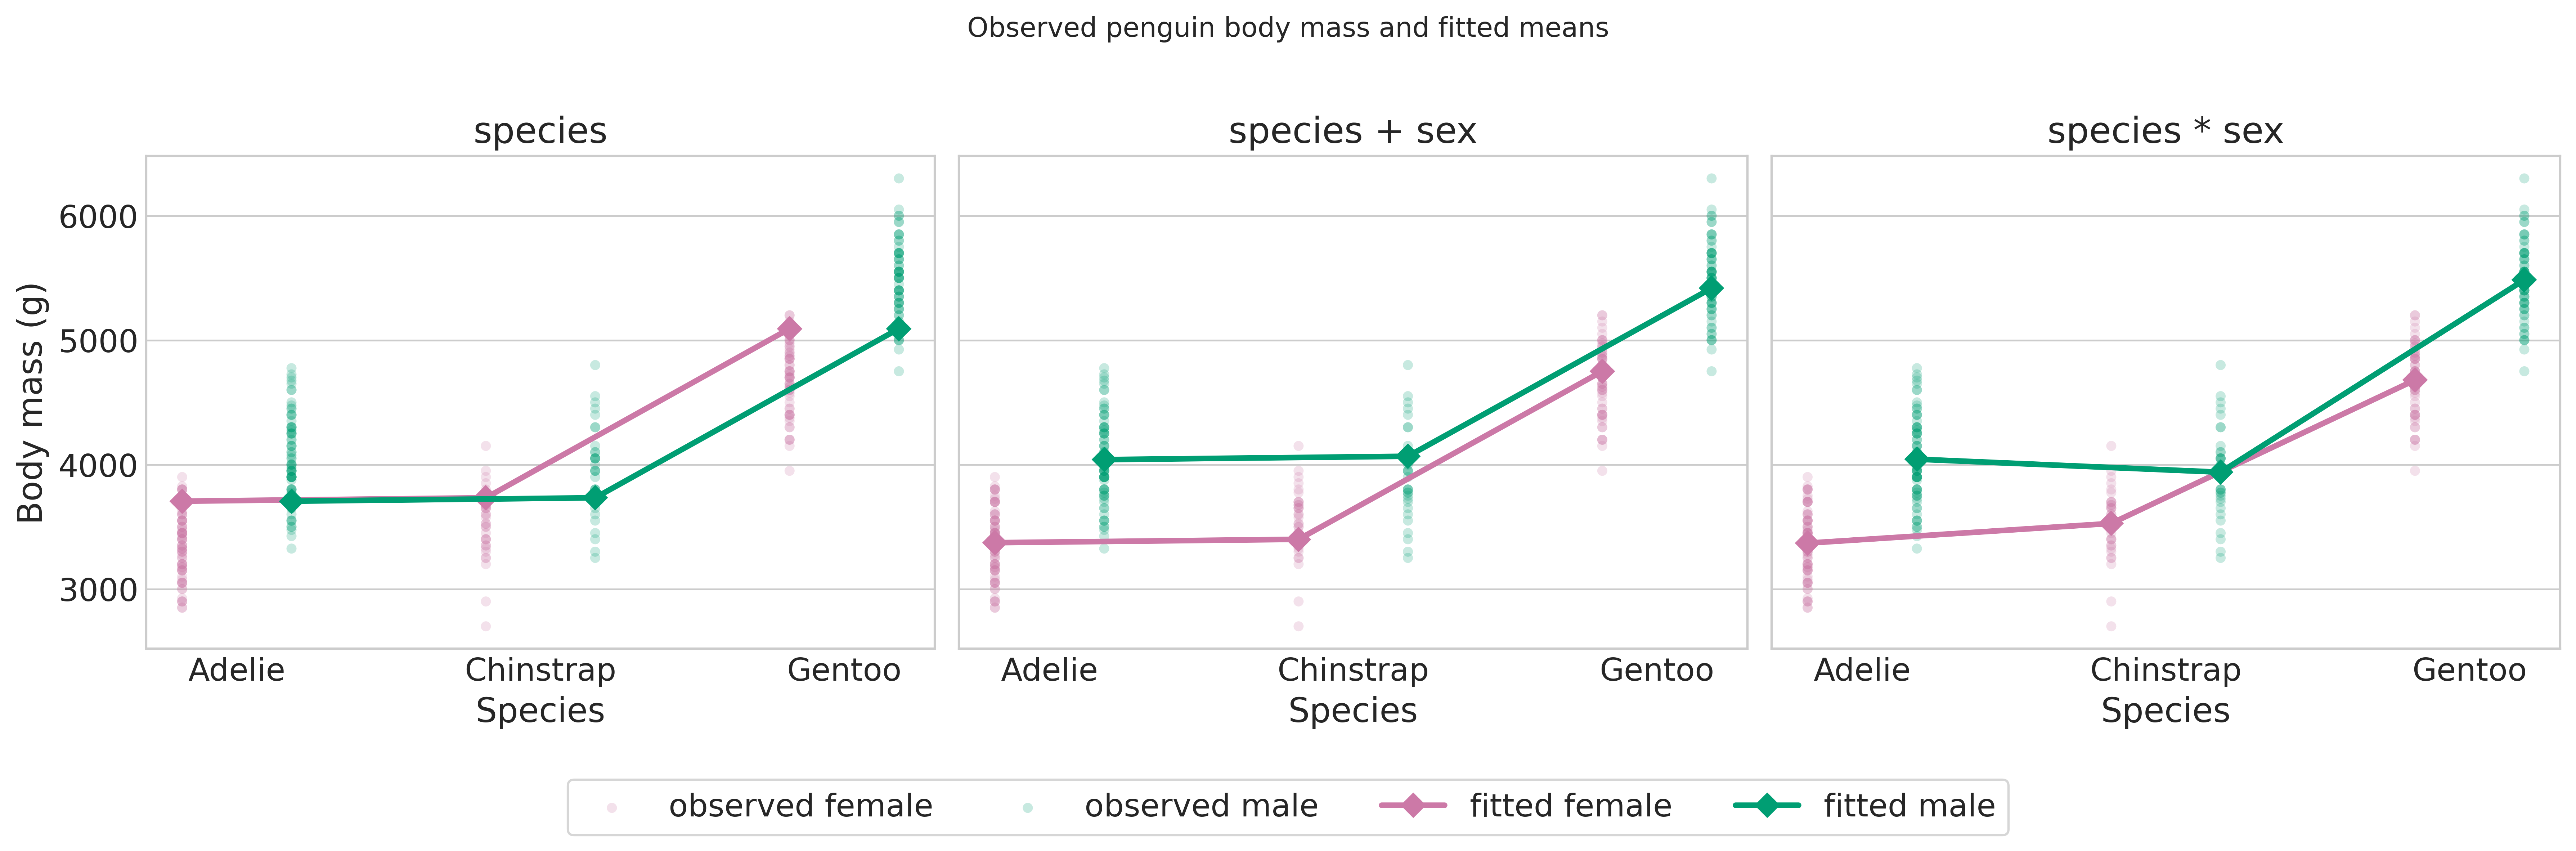

In [12]:
species_order = list(penguins_model_df["species"].cat.categories)
sex_order = list(penguins_model_df["sex"].cat.categories)
sex_offsets = {"female": -0.18, "male": 0.18}
sex_colors = {"female": "#CC79A7", "male": "#009E73"}
species_positions = {species: idx for idx, species in enumerate(species_order)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (model_name, ols_fit) in zip(axes, penguin_ols_fits.items()):
    for sex in sex_order:
        sex_df = penguins_model_df[penguins_model_df["sex"] == sex]
        x_observed = sex_df["species"].map(species_positions).astype(float) + sex_offsets[sex]
        ax.scatter(
            x_observed,
            sex_df["body_mass_g"],
            s=20,
            alpha=0.22,
            color=sex_colors[sex],
            edgecolor="none",
            label=f"observed {sex}",
        )

    model_grid = penguin_prediction_grid.copy()
    model_grid["predicted_body_mass_g"] = ols_fit.predict(model_grid)

    for sex in sex_order:
        sex_grid = model_grid[model_grid["sex"] == sex]
        x_predicted = sex_grid["species"].map(species_positions).astype(float) + sex_offsets[sex]
        ax.plot(
            x_predicted,
            sex_grid["predicted_body_mass_g"],
            color=sex_colors[sex],
            marker="D",
            markersize=7,
            linewidth=2.5,
            label=f"fitted {sex}",
        )

    ax.set_title(model_name)
    ax.set_xticks(range(len(species_order)))
    ax.set_xticklabels(species_order)
    ax.set_xlabel("Species")
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("Body mass (g)")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=True)
fig.suptitle("Observed penguin body mass and fitted means", y=1.03)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()


### 10.4.40 AIC in an applied model comparison


In [13]:
penguin_aic_table = pd.DataFrame(
    [
        {
            "model": model_name,
            "formula": penguin_formulae[model_name],
            "parameters": int(ols_fit.df_model + 1),
            "AIC": ols_fit.aic,
            "delta_AIC": ols_fit.aic - min(fit.aic for fit in penguin_ols_fits.values()),
        }
        for model_name, ols_fit in penguin_ols_fits.items()
    ]
).sort_values("AIC")

penguin_aic_table.style.format({"AIC": "{:.1f}", "delta_AIC": "{:.1f}"})


,model,formula,parameters,AIC,delta_AIC
2,species * sex,body_mass_g ~ species * sex,6,4770.2,0.0
1,species + sex,body_mass_g ~ species + sex,4,4783.6,13.4
0,species,body_mass_g ~ species,3,5032.5,262.3


### 10.4.41 WAIC is a Bayesian information criterion

The same three Bayesian models can be compared directly with ArviZ once each fit stores the pointwise log likelihood. ArviZ returns the comparison table for us, including the expected log predictive density estimate, effective number of parameters, model weights, and diagnostic warning column.


In [14]:
PENGUIN_RANDOM_SEED = 36714361

penguin_idata = {
    model_name: model.fit(
        draws=1000,
        tune=1000,
        chains=4,
        cores=1,
        random_seed=PENGUIN_RANDOM_SEED,
        idata_kwargs={"log_likelihood": True},
        progressbar=False,
    )
    for model_name, model in penguin_models.items()
}


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sigma, Intercept, species]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sigma, Intercept, species, sex, species:sex]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


### 10.4.42 WAIC in an applied model comparison


In [15]:
penguin_waic_table = az.compare(penguin_idata, ic="waic")
penguin_waic_table


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
species * sex,0,-2386.290200,6.967973,0.000000,0.862056,12.175076,0.000000,False,log
species + sex,1,-2392.875092,4.960643,6.584892,0.137944,12.005834,4.269239,False,log
species,2,-2517.111104,3.607536,130.820904,0.000000,11.230931,10.687399,False,log


<a id="section-105"></a>
## 10.5 Cross-validation

Testing prediction by fitting to part of the data and testing on the other part.


### 10.5.52 PSIS stabilizes the approximation


(0.0, 6.0)

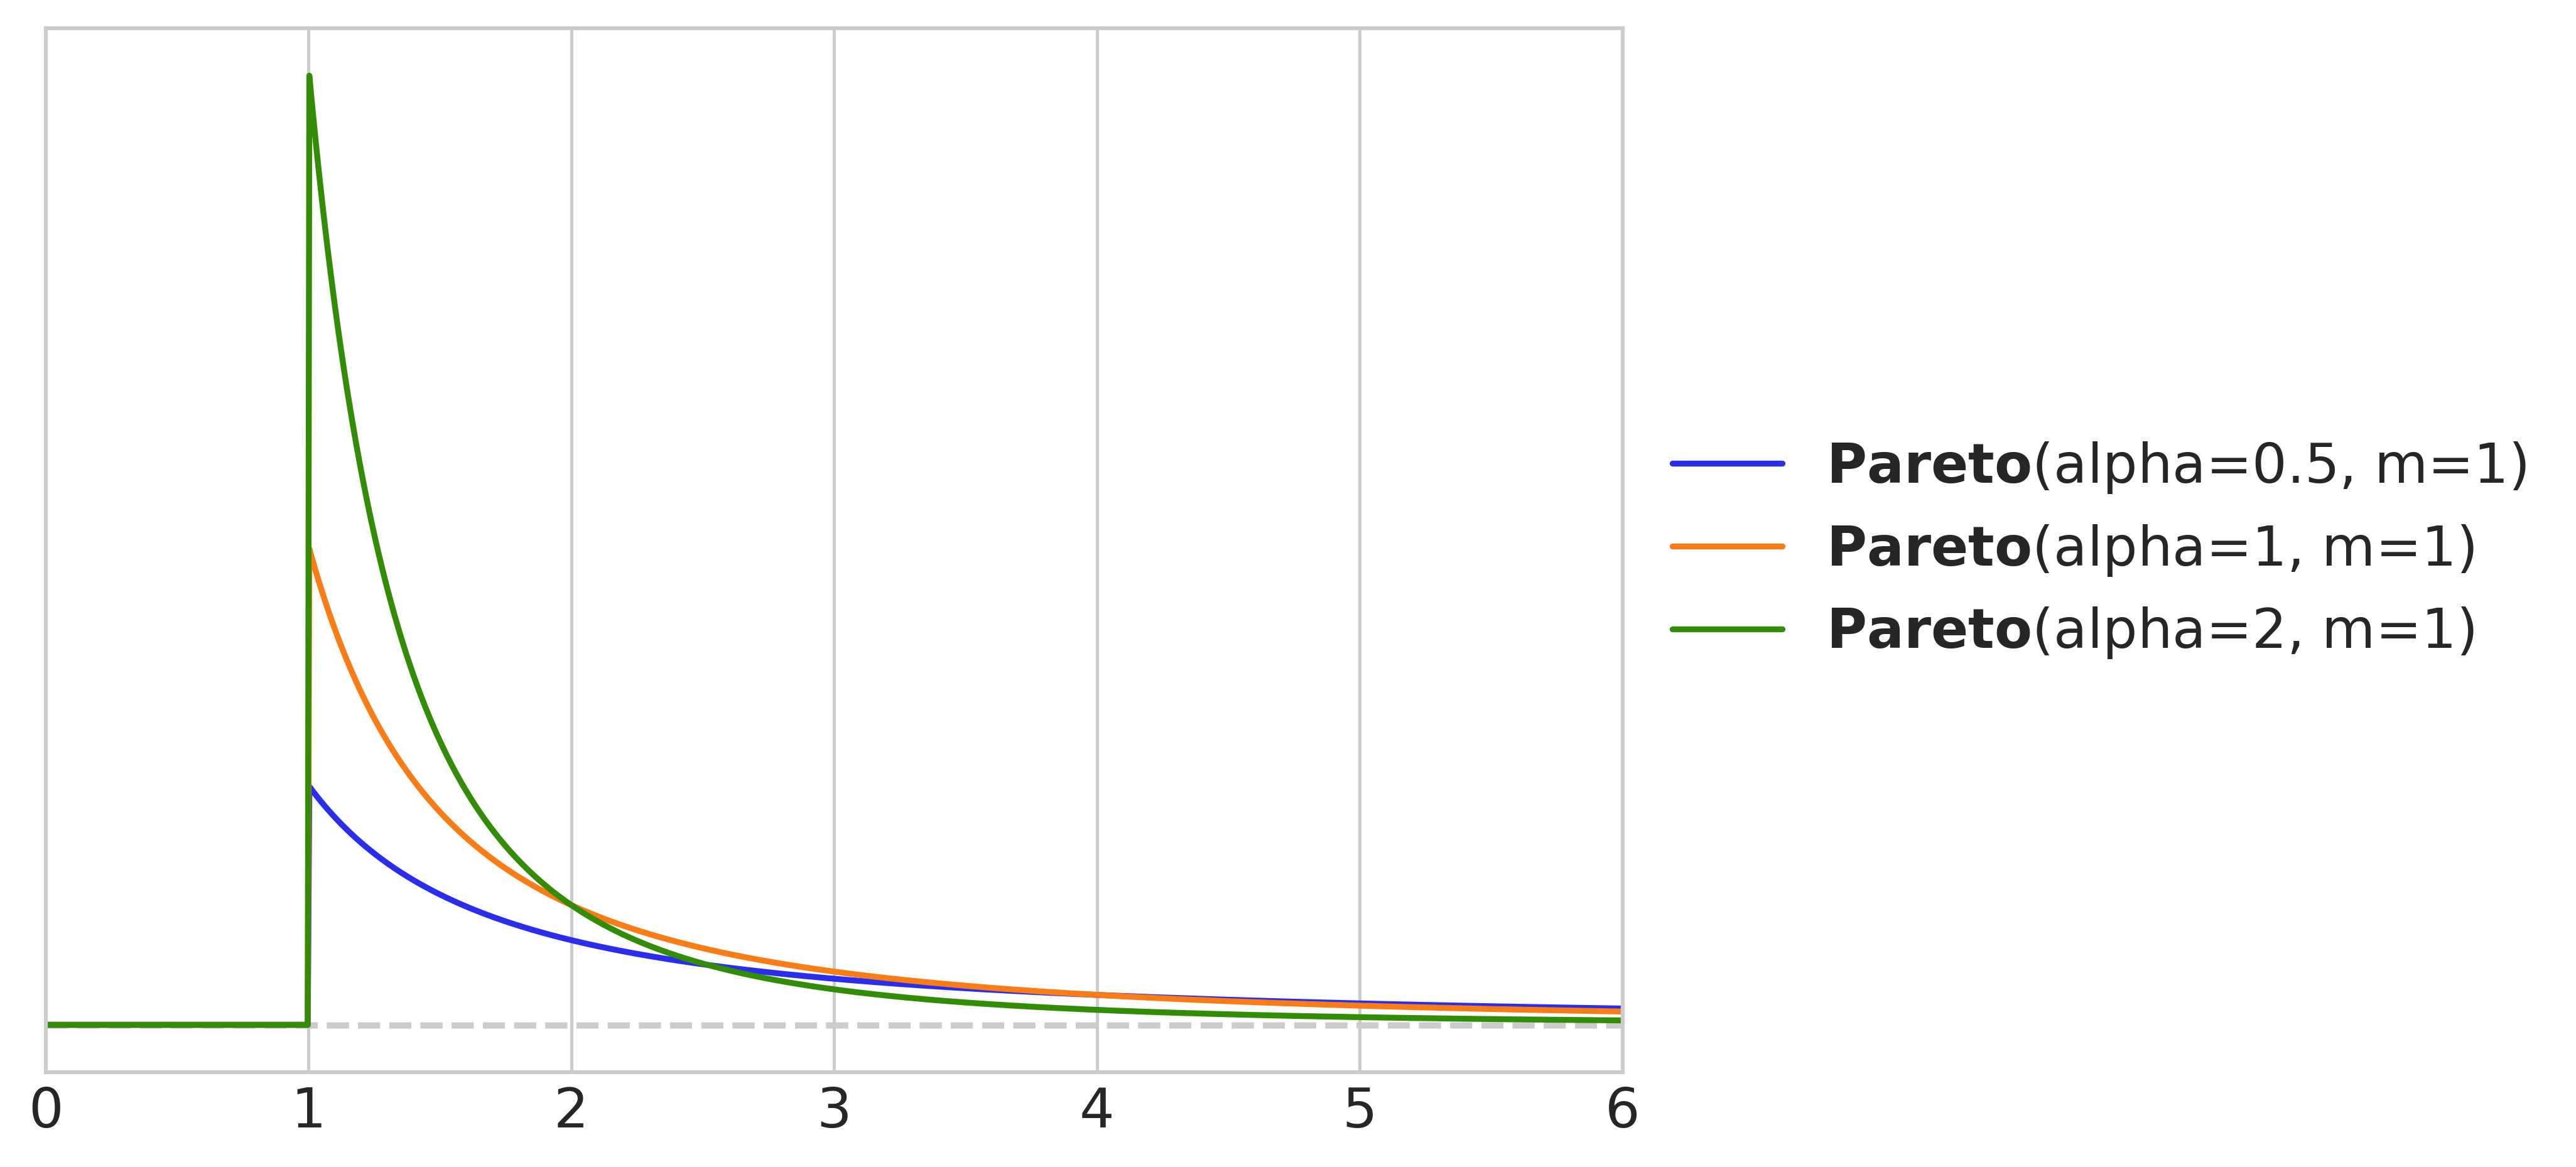

In [16]:
alphas = [0.5, 1., 2.]
ms = [1., 1., 1.]
for alpha, m in zip(alphas, ms):
    pz.Pareto(alpha, m).plot_pdf(support=(0,6))
plt.xlim(0, 6)

### Extra material: Pareto tail comparison on a wider support


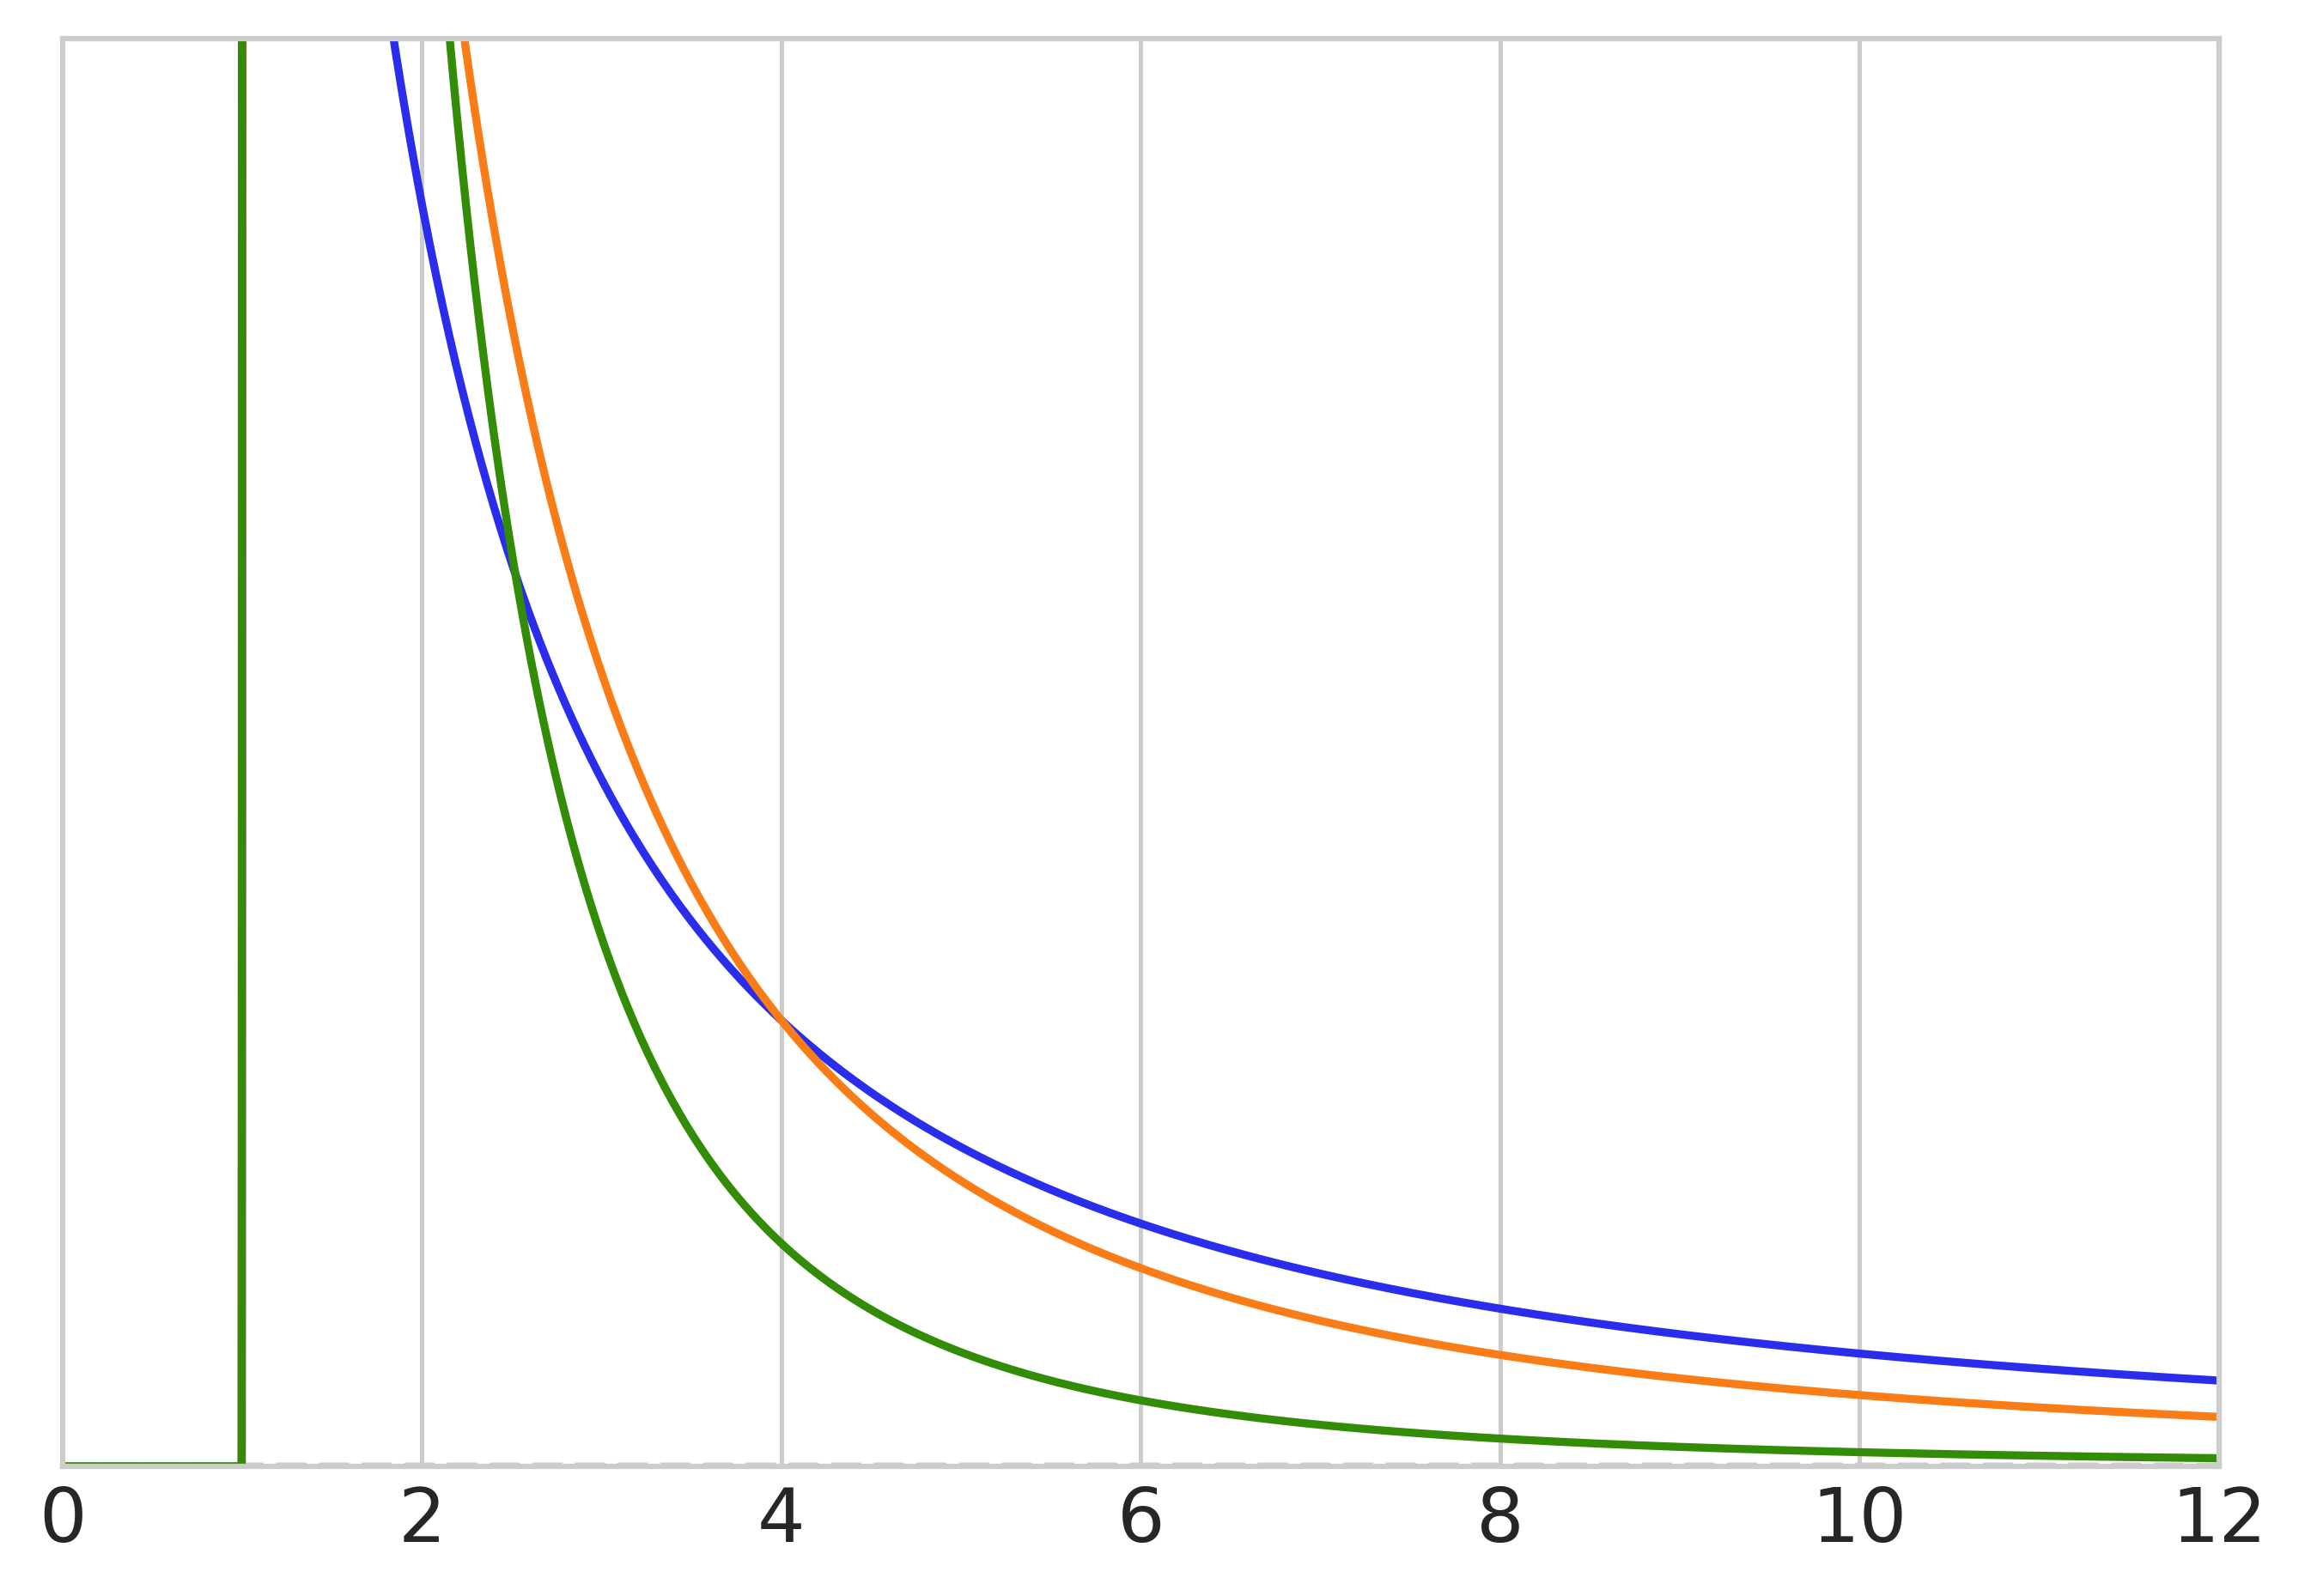

In [17]:
alphas = [0.5, 1., 2.]
ms = [1., 1., 1.]
for alpha, m in zip(alphas, ms):
    pz.Pareto(alpha, m).plot_pdf(support=(0,12))
plt.xlim(0, 12)
plt.ylim(0, 0.2)
plt.legend('')

### 10.5.55 Comparing model comparison criteria


In [18]:
penguin_loo_table = az.compare(penguin_idata, ic="loo")
penguin_loo_table

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
species * sex,0,-2386.303741,6.981514,0.000000,0.861795,12.176171,0.000000,False,log
species + sex,1,-2392.884856,4.970406,6.581114,0.138205,12.006771,4.269849,False,log
species,2,-2517.116369,3.612801,130.812628,0.000000,11.231261,10.688258,False,log


<a id="section-106"></a>
## 10.6 Updated Bayesian workflow

Model comparison is one step in a larger analysis.


### 10.6.60 Returning to birth weight and gestation age

The birth-weight example from Lecture 9 gives us a more realistic set of candidate models. We compare a gestation-only model, continuous additive and interaction smoking models, and categorical additive and interaction smoking models.


In [19]:
from pathlib import Path

BIRTH_RANDOM_SEED = 36714361

BIRTH_COLORS = {
    "observed": "#30343B",
    "mean": "#0072B2",
    "interaction": "#6A3D9A",
    "smoker": "#D55E00",
    "nonsmoker": "#0072B2",
}
BIRTH_LABELS = {
    "birth_weight": "Birth weight (g)",
    "gestation_weeks": "Gestation (weeks)",
}


def style_birth_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=10)
    return ax


births14_path = next(
    (
        path
        for path in [
            Path("public_content") / "Data" / "births14.csv",
            Path("..") / "public_content" / "Data" / "births14.csv",
            Path("data") / "births14.csv",
            Path("..") / "data" / "births14.csv",
        ]
        if path.exists()
    ),
    None,
)
if births14_path is None:
    raise FileNotFoundError("Could not find births14.csv in the course data folders.")

births14_raw = pd.read_csv(births14_path)
births14 = births14_raw.copy()
births14["birth_weight"] = births14["weight"] * 453.59237
births14["gestation_weeks"] = births14["weeks"]
births14["smoking"] = pd.Categorical(
    births14["habit"],
    categories=["nonsmoker", "smoker"],
    ordered=True,
)

gestation_category_order = ["very preterm", "preterm", "early/full term"]
births14["gestation_category"] = pd.cut(
    births14["gestation_weeks"],
    bins=[-np.inf, 32, 37, np.inf],
    labels=gestation_category_order,
    right=False,
    ordered=True,
)

births_model_df = births14[[
    "birth_weight",
    "gestation_weeks",
    "smoking",
    "gestation_category",
]].dropna().copy()
births_model_df["gestation_category_smoking"] = [
    f"{gestation_category}, {smoking}"
    for gestation_category, smoking in zip(
        births_model_df["gestation_category"],
        births_model_df["smoking"],
    )
]

birth_models = {
    "gestation only": bmb.Model(
        "birth_weight ~ gestation_weeks",
        data=births_model_df,
        family="gaussian",
    ),
    "gestation + smoking": bmb.Model(
        "birth_weight ~ gestation_weeks + smoking",
        data=births_model_df,
        family="gaussian",
    ),
    "gestation * smoking": bmb.Model(
        "birth_weight ~ gestation_weeks * smoking",
        data=births_model_df,
        family="gaussian",
    ),
    "gestation category + smoking": bmb.Model(
        "birth_weight ~ gestation_category + smoking",
        data=births_model_df,
        family="gaussian",
    ),
    "gestation category * smoking": bmb.Model(
        "birth_weight ~ gestation_category * smoking",
        data=births_model_df,
        family="gaussian",
    ),
}

birth_formulae = {
    "gestation only": "birth_weight ~ gestation_weeks",
    "gestation + smoking": "birth_weight ~ gestation_weeks + smoking",
    "gestation * smoking": "birth_weight ~ gestation_weeks * smoking",
    "gestation category + smoking": "birth_weight ~ gestation_category + smoking",
    "gestation category * smoking": "birth_weight ~ gestation_category * smoking",
}
birth_ols_fits = {
    model_name: smf.ols(formula, data=births_model_df).fit()
    for model_name, formula in birth_formulae.items()
}


### Extra material: Fitted birth-weight candidate models

Each model is shown against the same data. The first three panels keep gestation continuous; the categorical models estimate separate means inside the gestation bins used in Lecture 9.


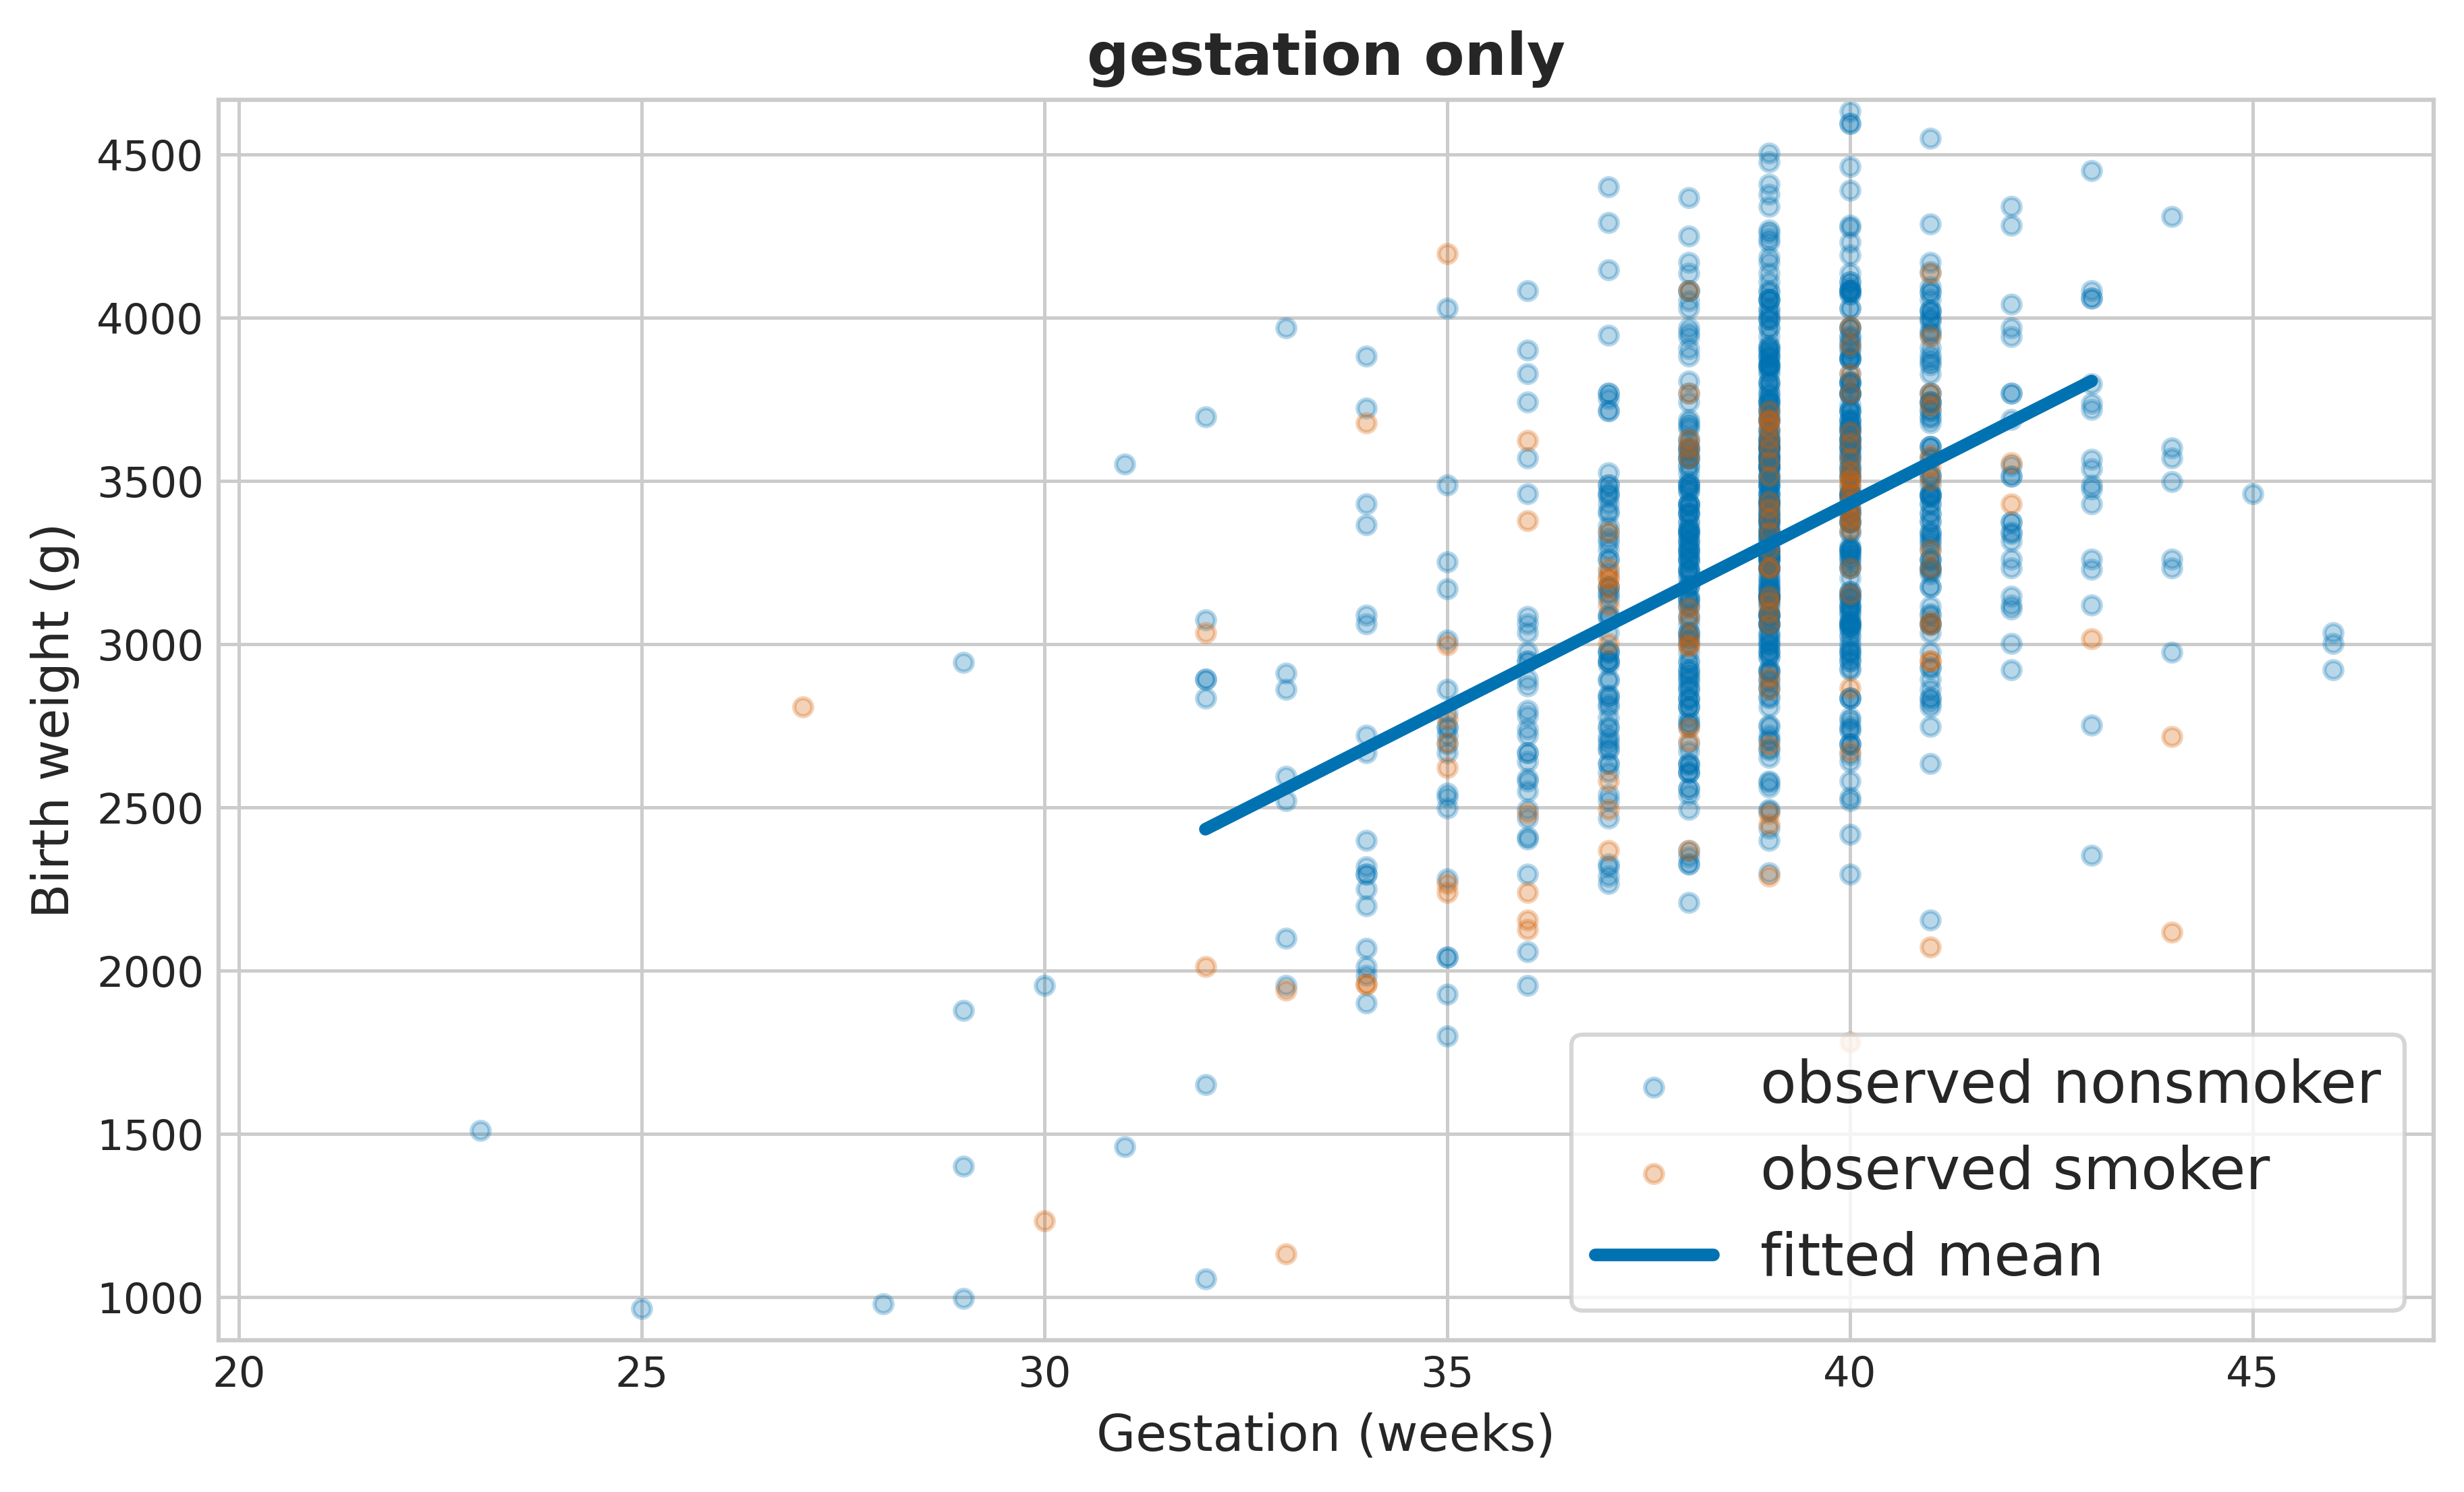

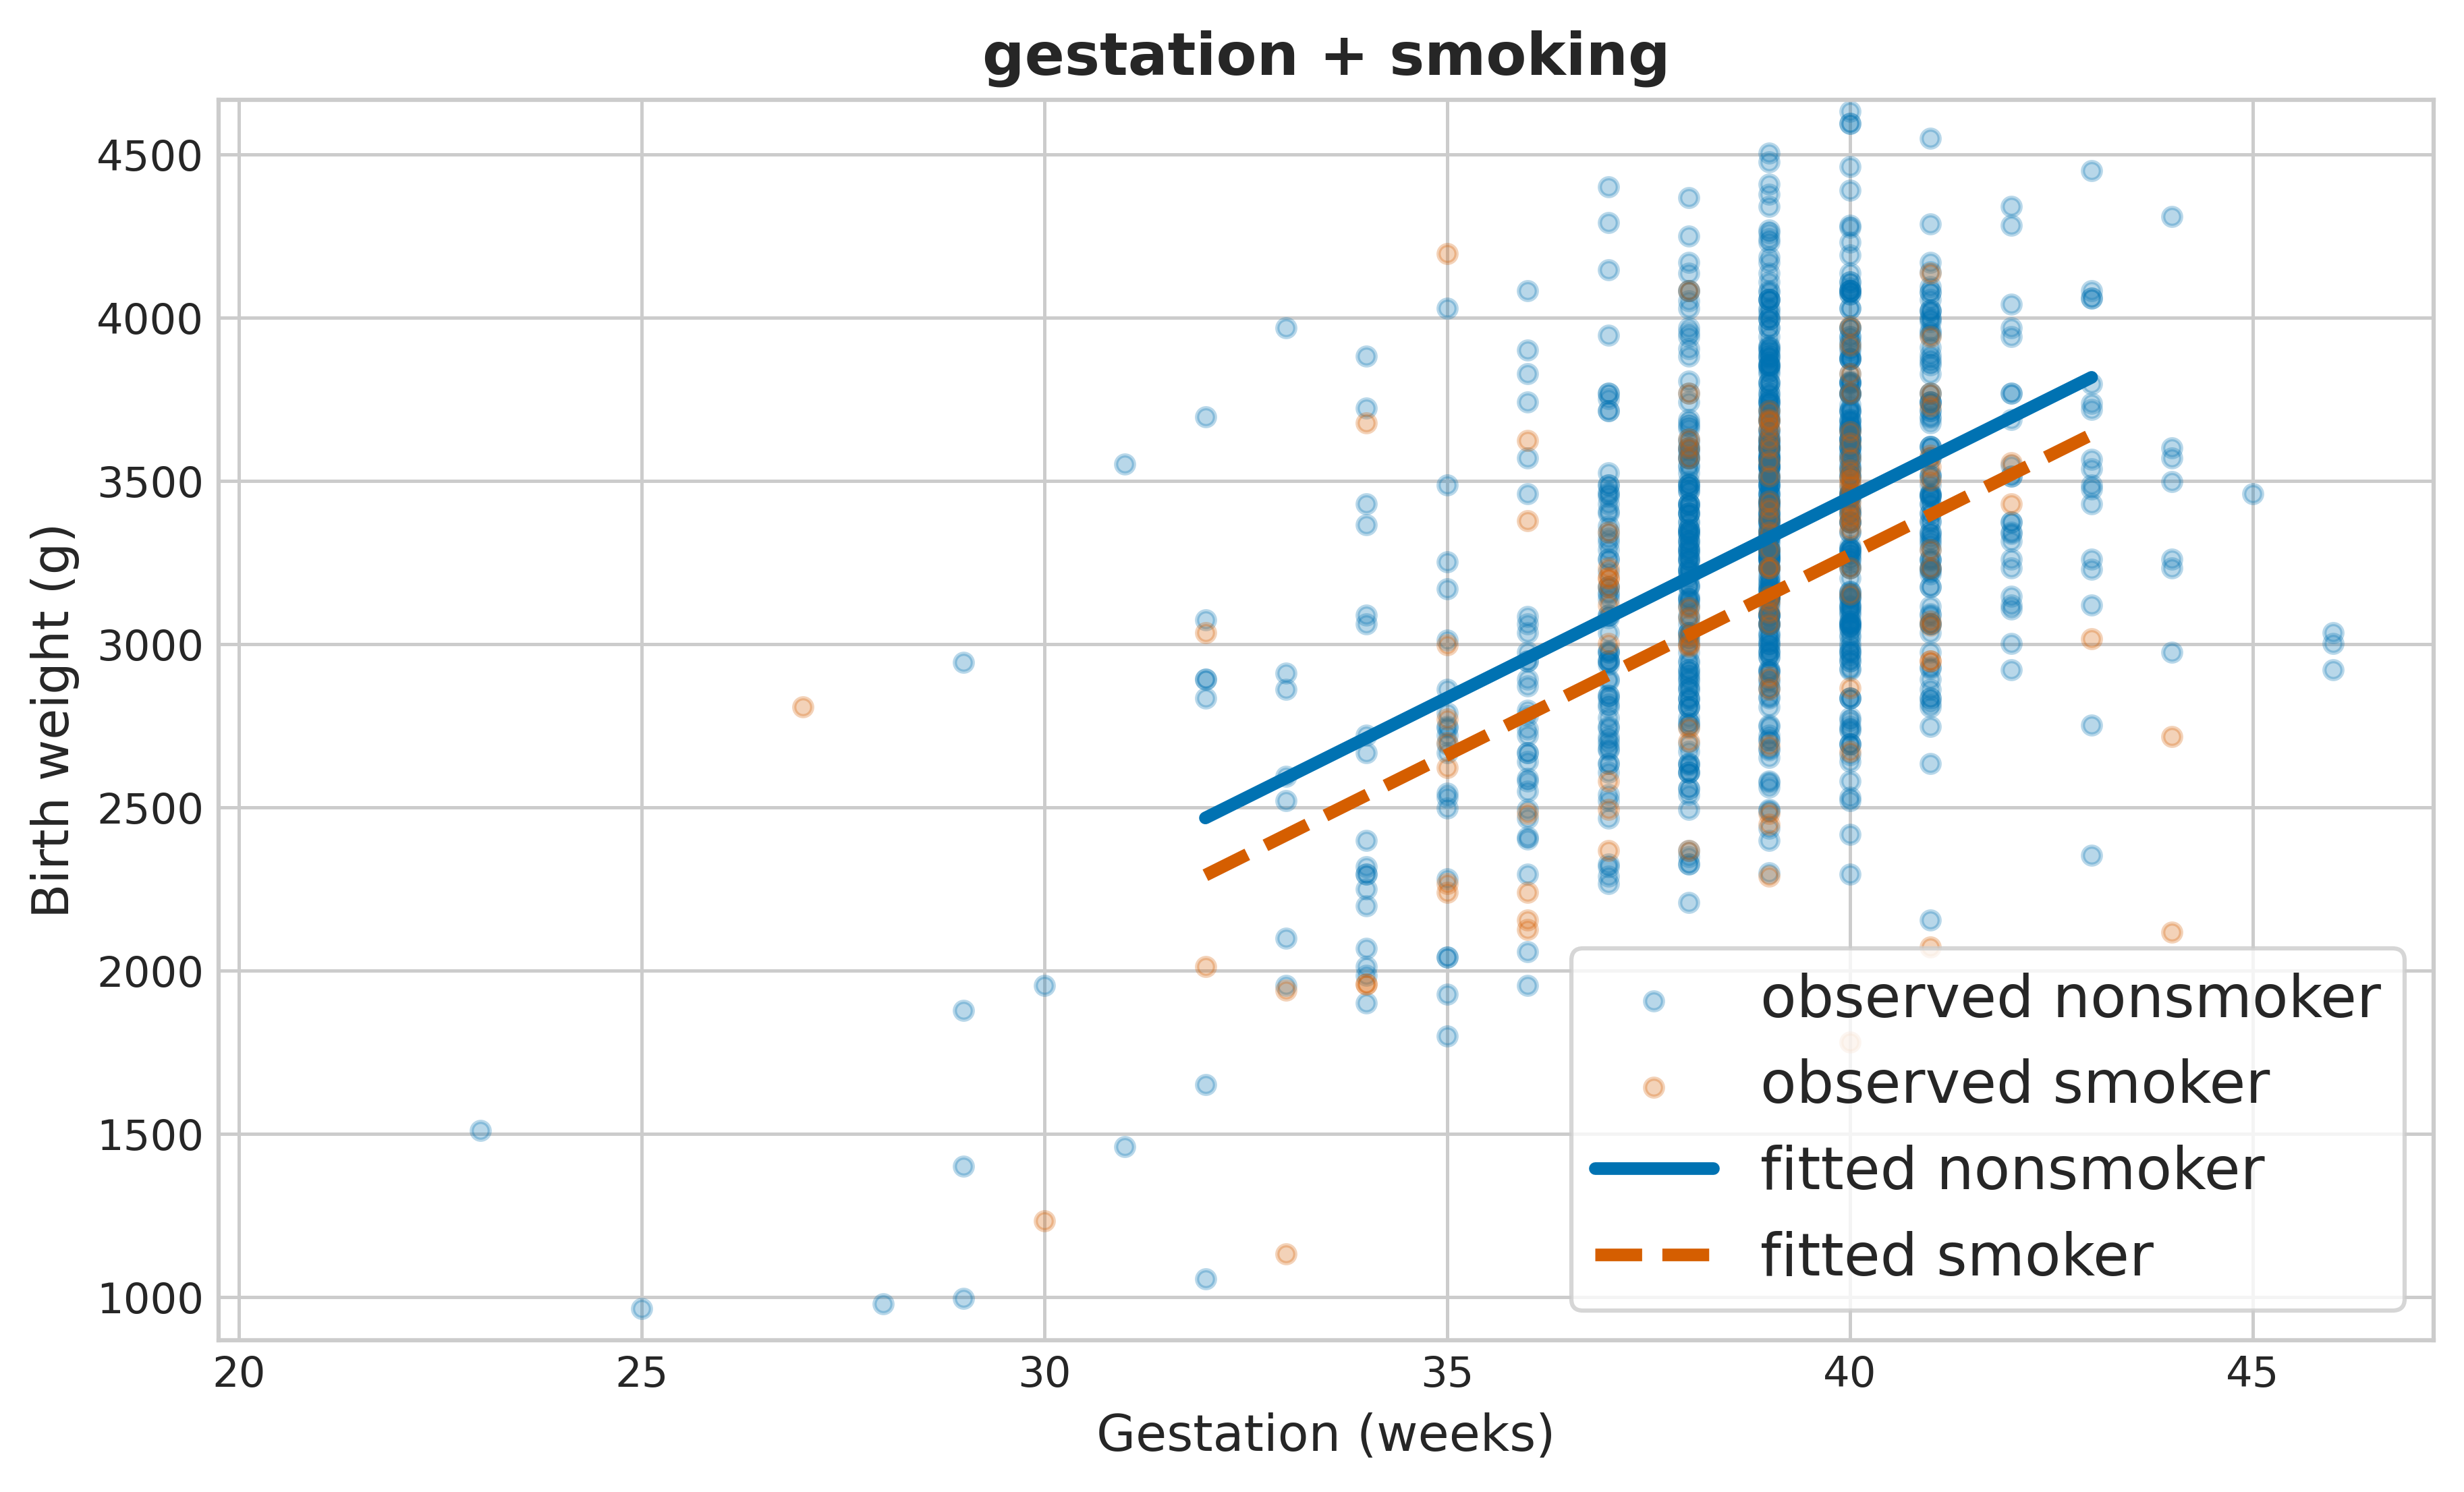

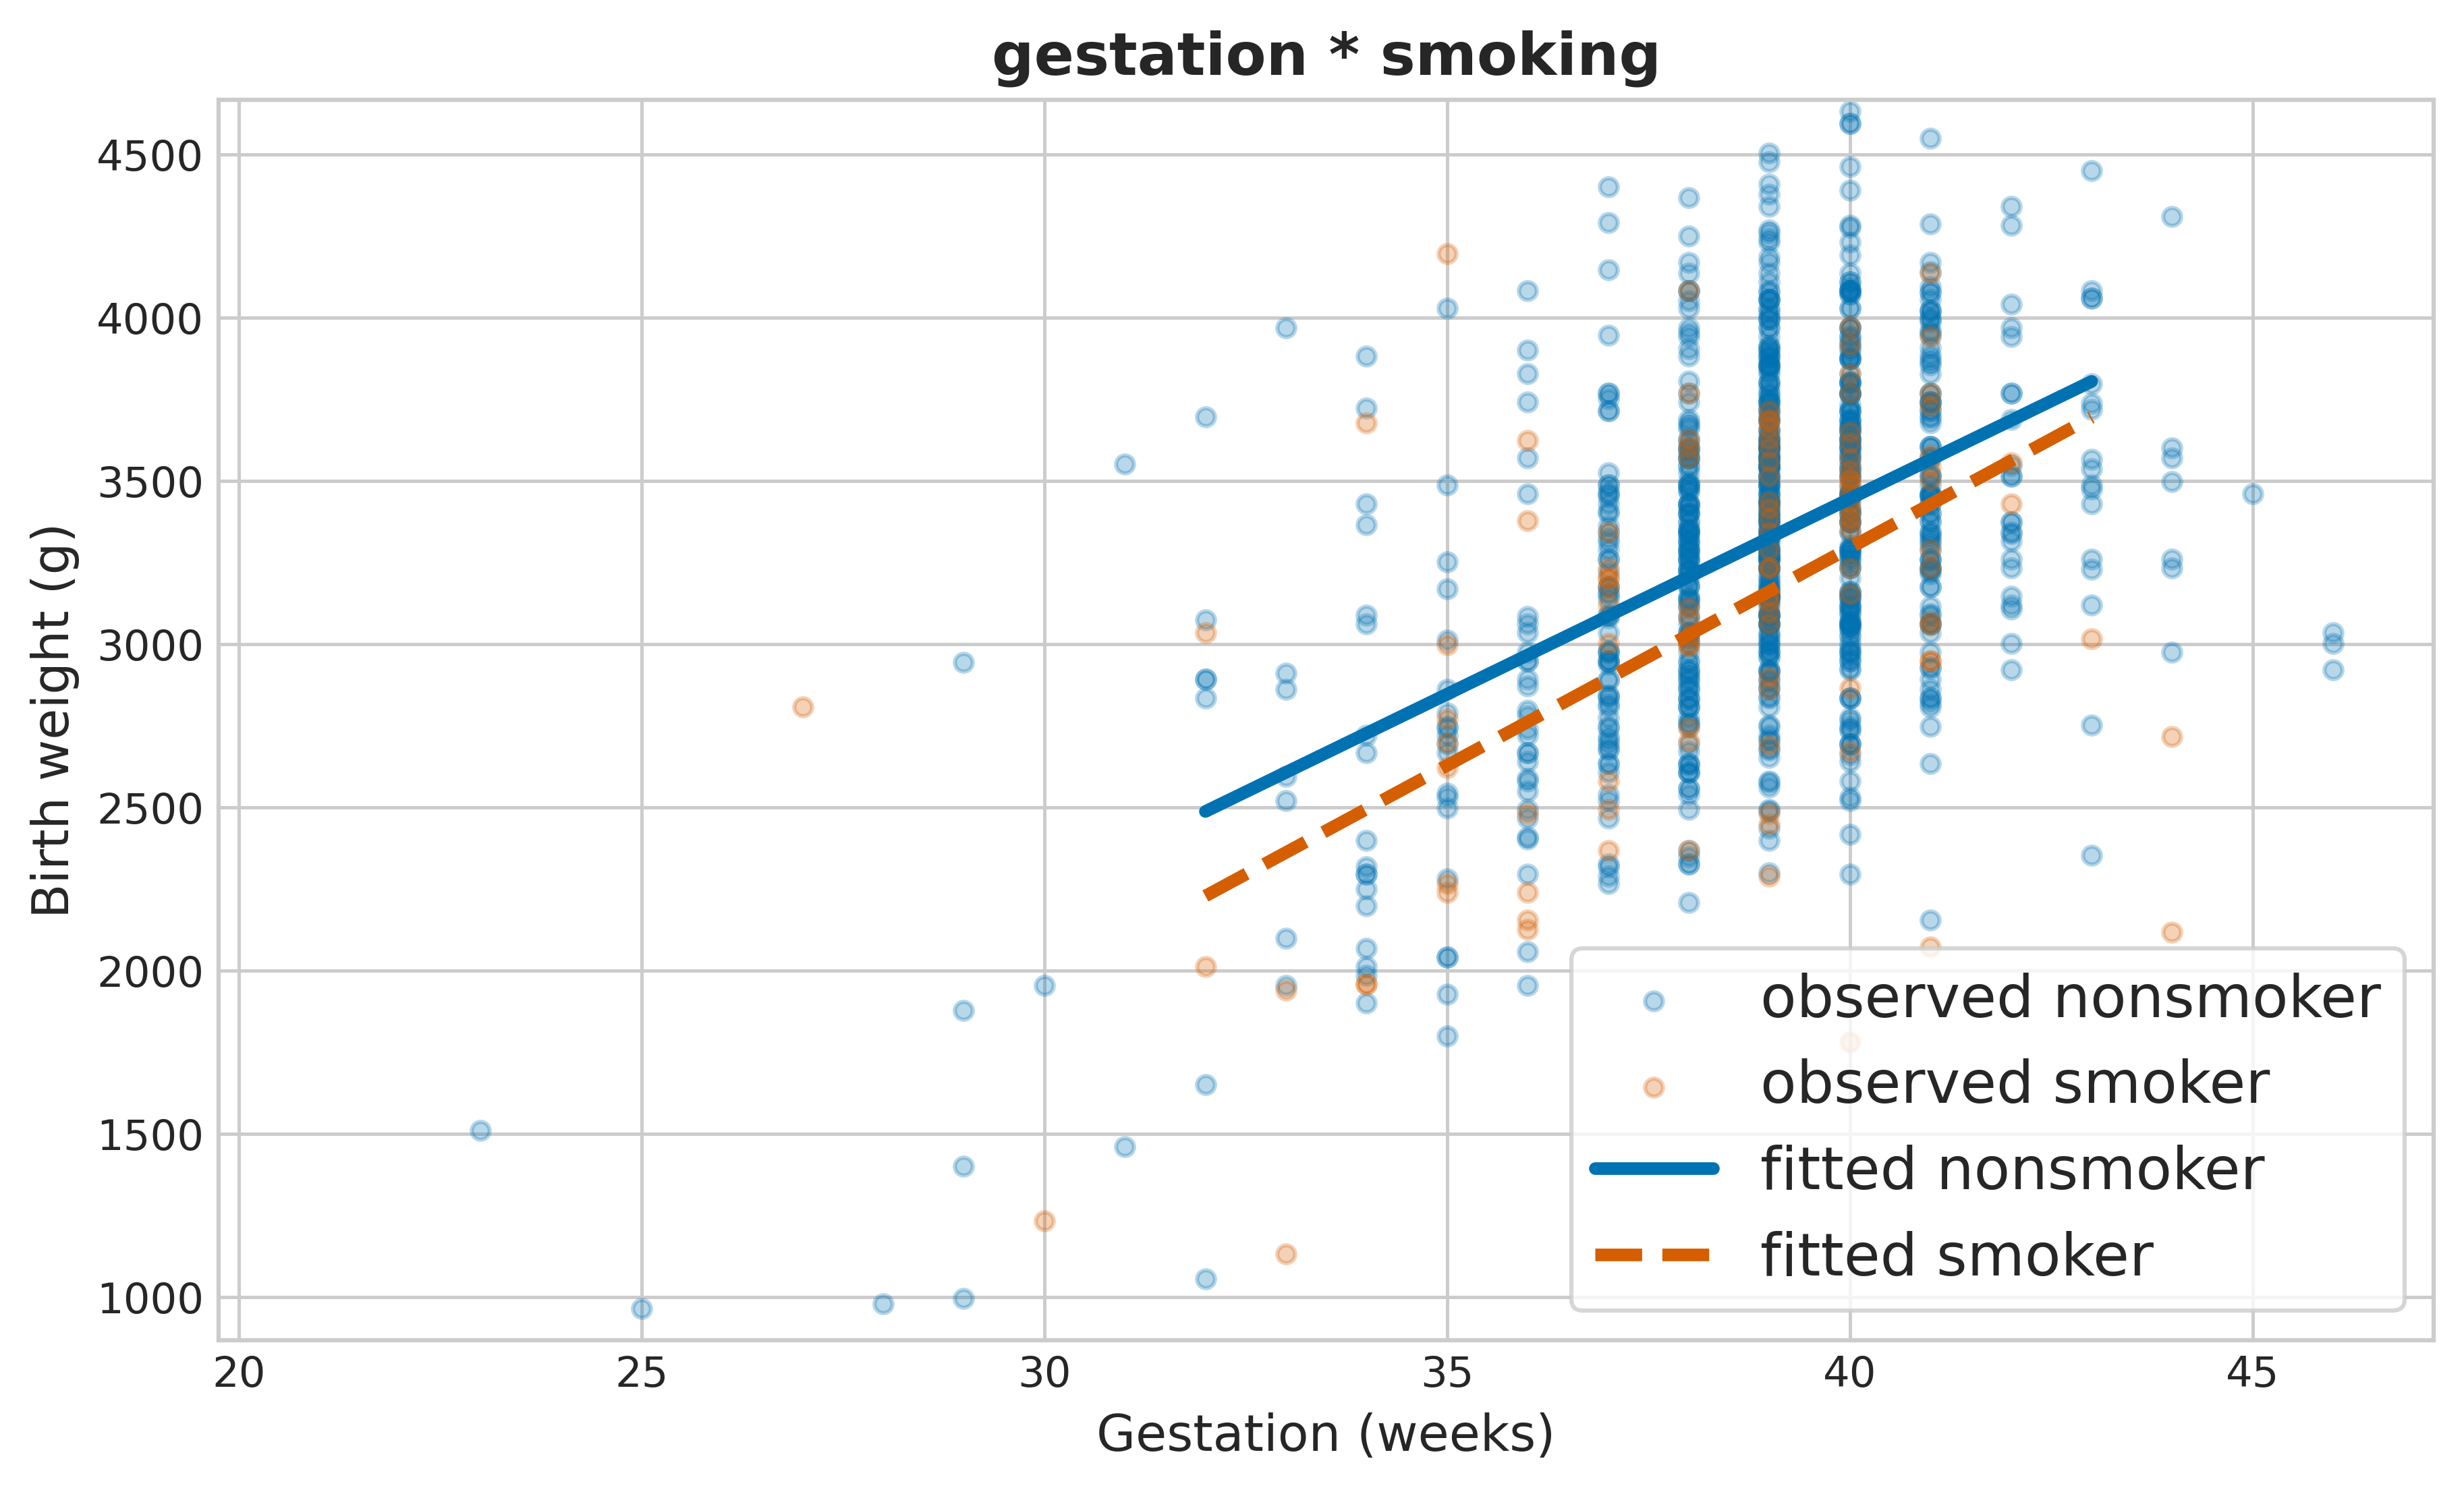

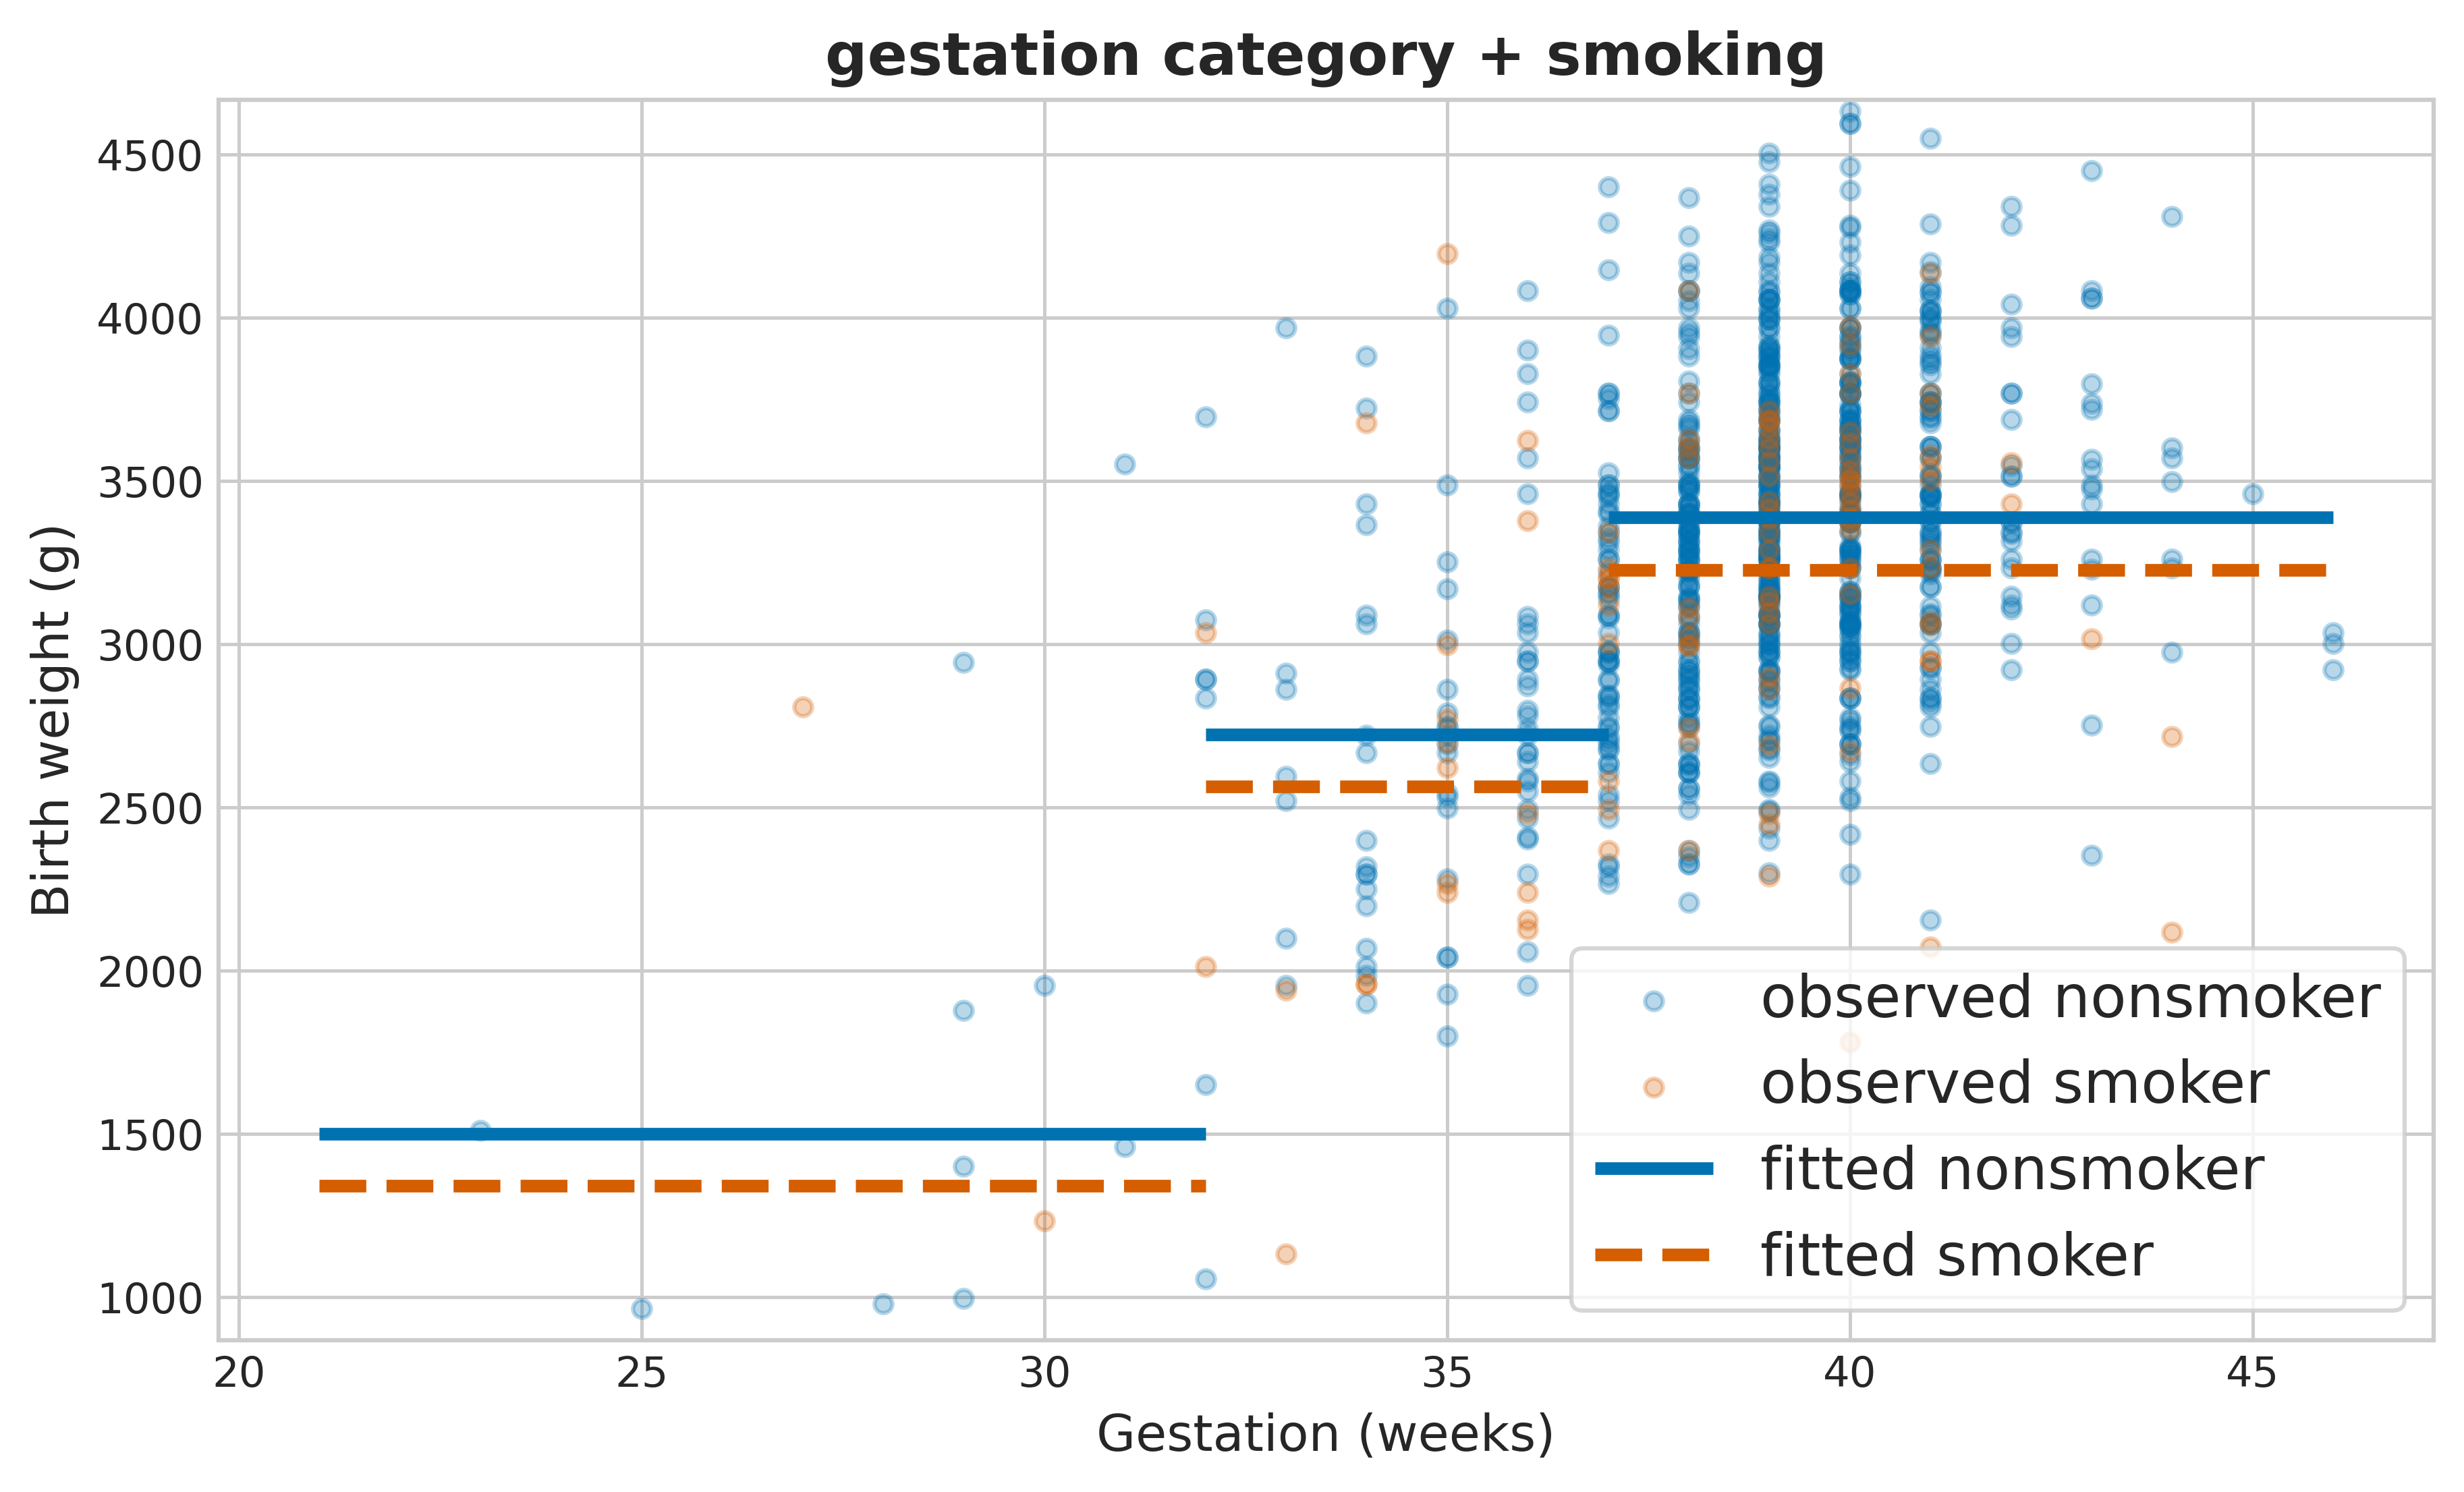

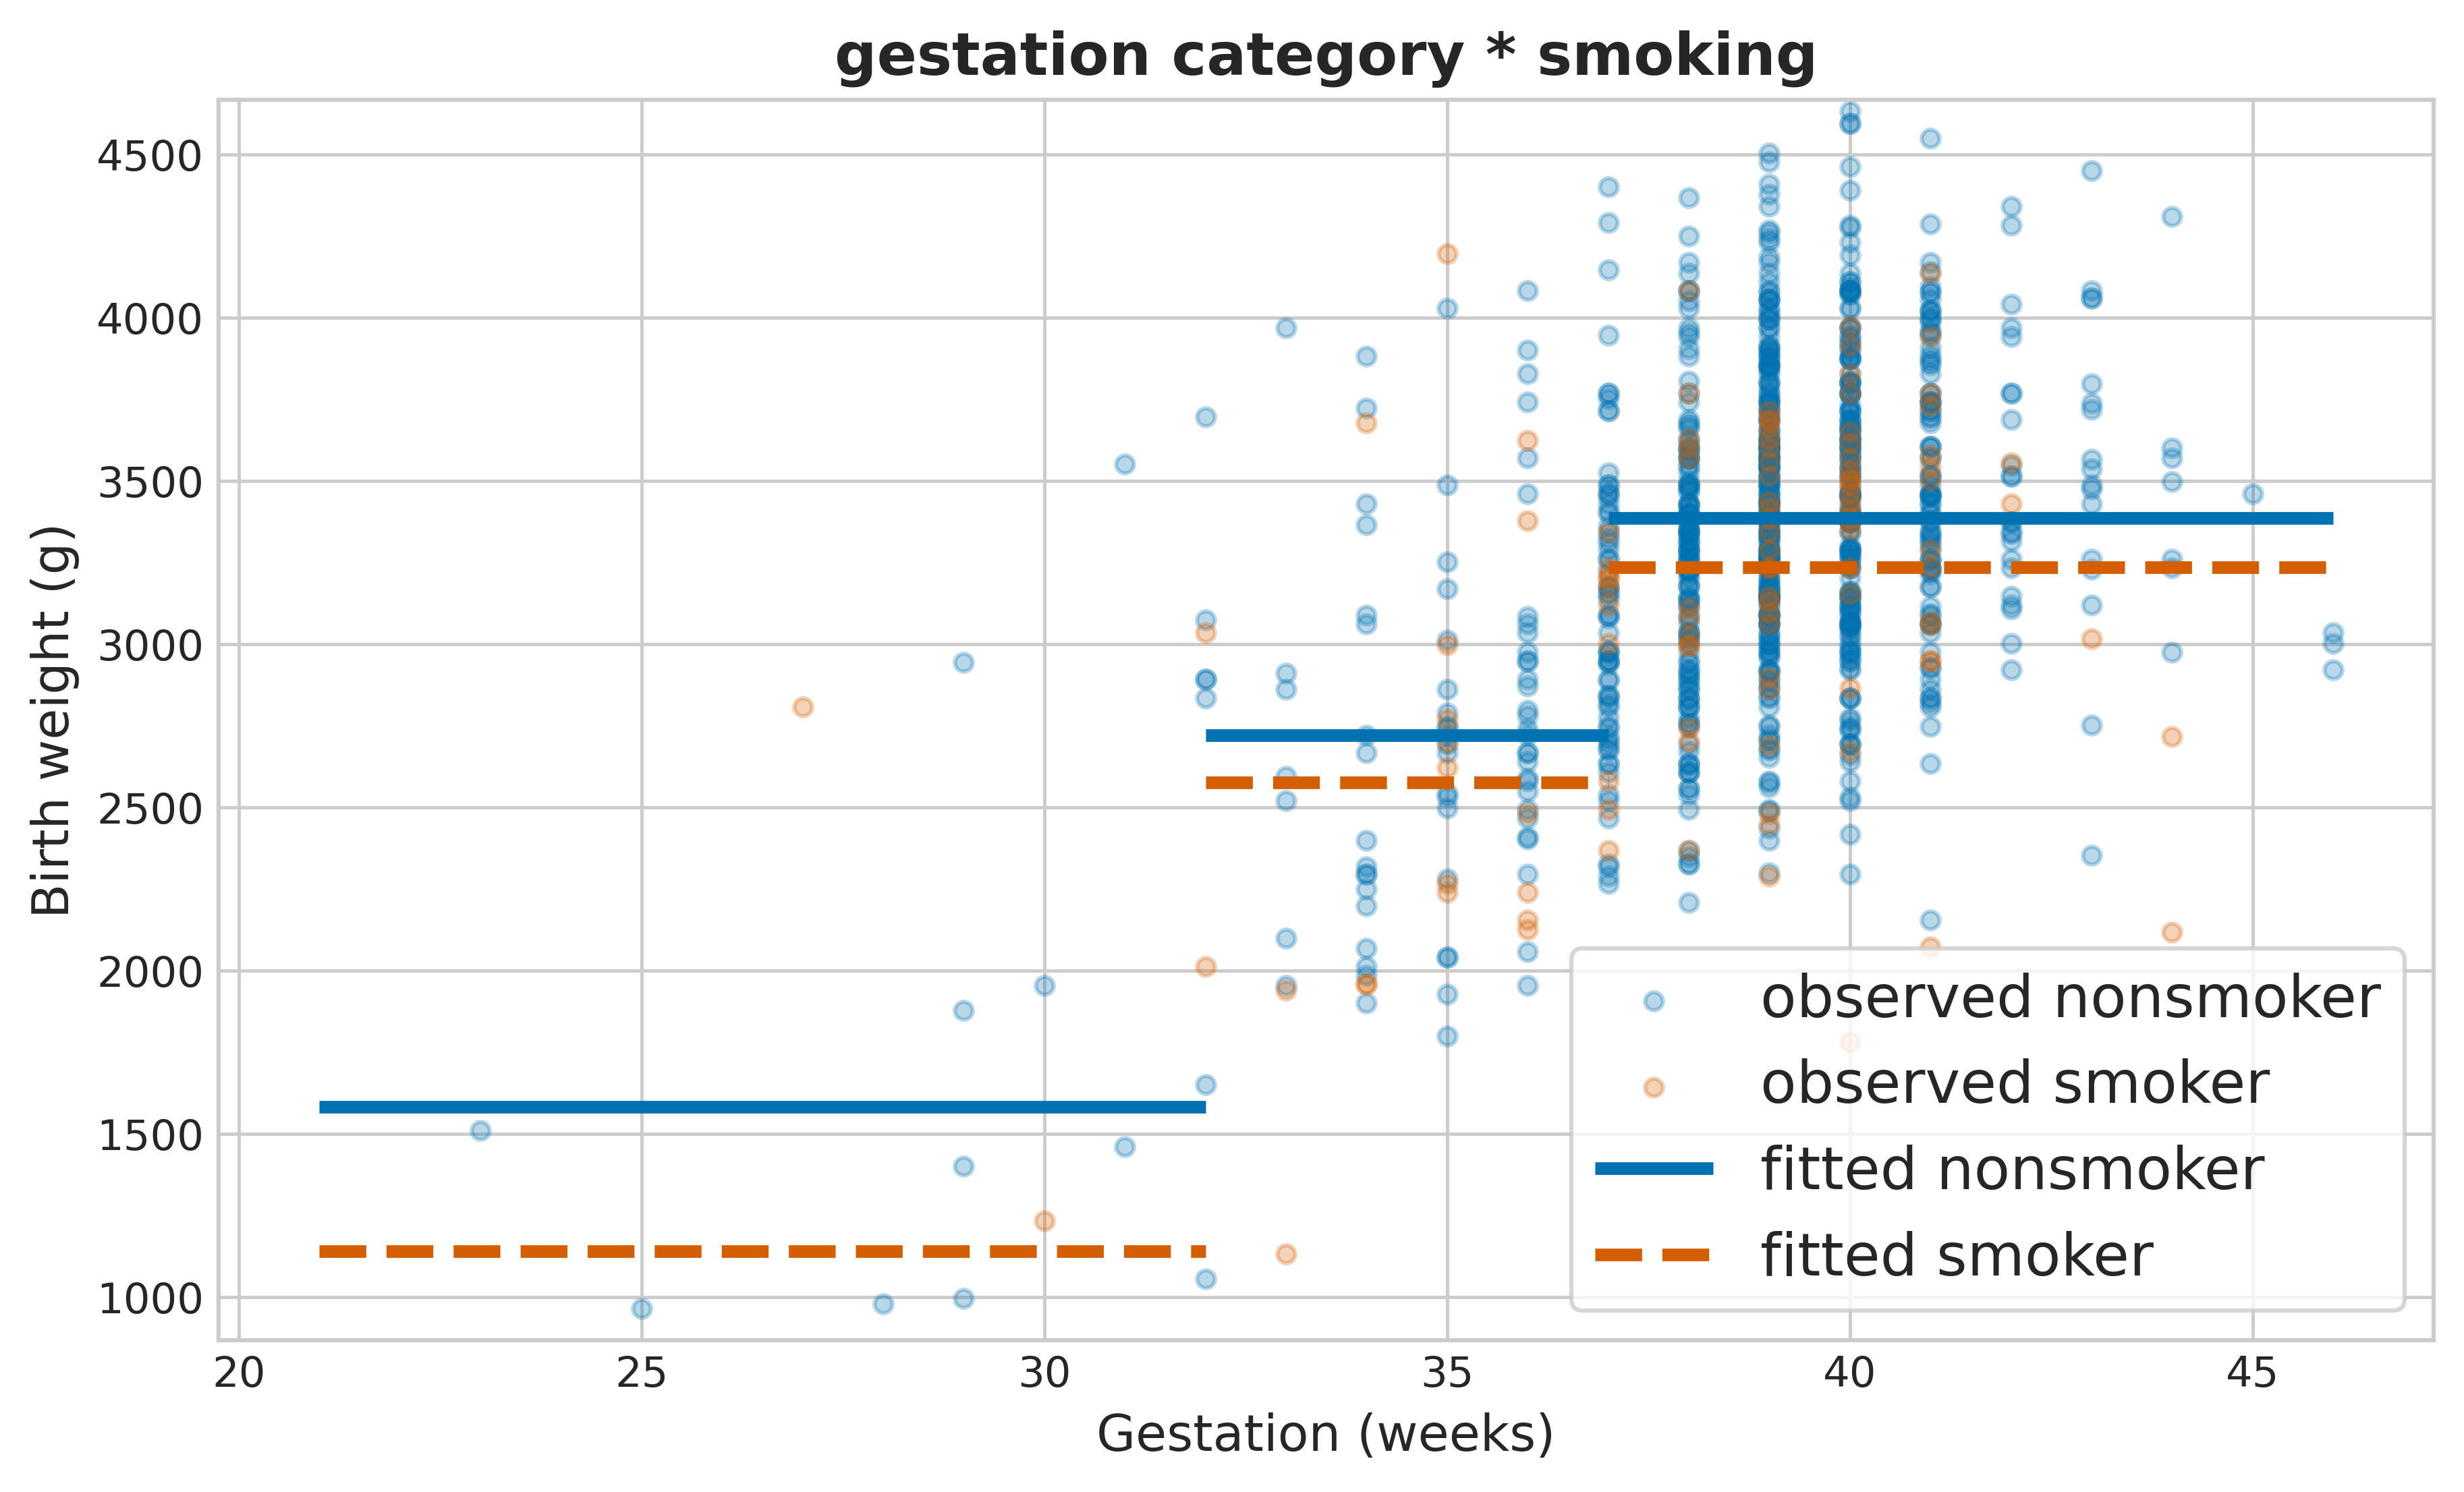

In [20]:
birth_week_grid = np.linspace(
    births_model_df["gestation_weeks"].quantile(0.02),
    births_model_df["gestation_weeks"].quantile(0.98),
    100,
)
birth_prediction_grid = pd.DataFrame(
    [
        {"gestation_weeks": week, "smoking": smoking}
        for week in birth_week_grid
        for smoking in ["nonsmoker", "smoker"]
    ]
)
birth_prediction_grid["smoking"] = pd.Categorical(
    birth_prediction_grid["smoking"],
    categories=["nonsmoker", "smoker"],
    ordered=True,
)
birth_category_prediction_grid = pd.DataFrame(
    [
        {"gestation_category": category, "smoking": smoking}
        for category in gestation_category_order
        for smoking in ["nonsmoker", "smoker"]
    ]
)
birth_category_prediction_grid["gestation_category"] = pd.Categorical(
    birth_category_prediction_grid["gestation_category"],
    categories=gestation_category_order,
    ordered=True,
)
birth_category_prediction_grid["smoking"] = pd.Categorical(
    birth_category_prediction_grid["smoking"],
    categories=["nonsmoker", "smoker"],
    ordered=True,
)

birth_category_ranges = {
    "very preterm": (births_model_df["gestation_weeks"].min(), 32),
    "preterm": (32, 37),
    "early/full term": (37, births_model_df["gestation_weeks"].max()),
}


def plot_birth_data(ax):
    for smoking_group in ["nonsmoker", "smoker"]:
        group_data = births_model_df.loc[births_model_df["smoking"] == smoking_group]
        ax.scatter(
            group_data["gestation_weeks"],
            group_data["birth_weight"],
            s=18,
            alpha=0.28,
            color=BIRTH_COLORS[smoking_group],
            label=f"observed {smoking_group}",
            zorder=1,
        )


for model_name, ols_fit in birth_ols_fits.items():
    fig, ax = plt.subplots(figsize=(8, 4.8))
    plot_birth_data(ax)

    if model_name.startswith("gestation category"):
        category_grid = birth_category_prediction_grid.copy()
        category_grid["predicted_birth_weight"] = ols_fit.predict(category_grid)
        for smoking_group, line_style in zip(["nonsmoker", "smoker"], ["-", "--"]):
            for _, row in category_grid.loc[category_grid["smoking"] == smoking_group].iterrows():
                x_min, x_max = birth_category_ranges[row["gestation_category"]]
                ax.hlines(
                    row["predicted_birth_weight"],
                    x_min,
                    x_max,
                    color=BIRTH_COLORS[smoking_group],
                    linestyles=line_style,
                    linewidth=3,
                    label=f"fitted {smoking_group}" if row["gestation_category"] == gestation_category_order[0] else "_nolegend_",
                    zorder=3,
                )
    else:
        if model_name == "gestation only":
            model_grid = pd.DataFrame({"gestation_weeks": birth_week_grid})
            ax.plot(
                birth_week_grid,
                ols_fit.predict(model_grid),
                color=BIRTH_COLORS["mean"],
                linewidth=3,
                label="fitted mean",
                zorder=3,
            )
        else:
            model_grid = birth_prediction_grid.copy()
            model_grid["predicted_birth_weight"] = ols_fit.predict(model_grid)
            for smoking_group, line_style in zip(["nonsmoker", "smoker"], ["-", "--"]):
                group_grid = model_grid.loc[model_grid["smoking"] == smoking_group]
                ax.plot(
                    group_grid["gestation_weeks"],
                    group_grid["predicted_birth_weight"],
                    color=BIRTH_COLORS[smoking_group],
                    linestyle=line_style,
                    linewidth=3,
                    label=f"fitted {smoking_group}",
                    zorder=3,
                )

    ax.set_ylim(births_model_df["birth_weight"].quantile(0.01) - 250, births_model_df["birth_weight"].quantile(0.99) + 250)
    style_birth_axis(ax, model_name, BIRTH_LABELS["gestation_weeks"], BIRTH_LABELS["birth_weight"])
    ax.legend(loc="lower right", frameon=True)
    plt.show()


### 10.6.61 Effect sizes for the models and the factors

The effect-size table compares models and model components. `R2` summarizes how much posterior fitted means vary relative to residual variation. The partial `R2` columns summarize the terms present in each model; blank cells indicate terms that are not included in that model. Gestation is continuous or categorical depending on the model row. Each cell reports the 94% HDI as `[HDIlo, HDIhi]`.


In [21]:
birth_idata = {
    model_name: model.fit(
        draws=1000,
        tune=1000,
        chains=4,
        cores=1,
        random_seed=BIRTH_RANDOM_SEED,
        idata_kwargs={"log_likelihood": True},
        progressbar=False,
    )
    for model_name, model in birth_models.items()
}

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sigma, Intercept, gestation_weeks]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sigma, Intercept, gestation_category, smoking, gestation_category:smoking]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.


In [22]:
birth_effect_size_columns = [
    "R2",
    "partial_R2_gestation",
    "partial_R2_smoking",
    "partial_R2_gestation_smoking",
]


def posterior_sample_vector(idata, var_name, coord=None):
    values = idata.posterior[var_name].stack(sample=("chain", "draw"))
    if coord is not None:
        values = values.sel(coord)
    return values.transpose("sample").to_numpy()


def variance_r2(component_draws, sigma_draws):
    component_variance = np.var(component_draws, axis=1)
    return component_variance / (component_variance + sigma_draws**2)


def format_hdi(draws, hdi_prob=0.94):
    hdi_low, hdi_high = az.hdi(draws, hdi_prob=hdi_prob)
    return f"[{hdi_low:.3f}, {hdi_high:.3f}]"


def summarize_effect_size_draws(effect_size_draws):
    return {
        column: "" if draws is None else format_hdi(draws)
        for column, draws in effect_size_draws.items()
    }


gestation_weeks = births_model_df["gestation_weeks"].to_numpy()
smoker_indicator = (births_model_df["smoking"] == "smoker").astype(float).to_numpy()


def continuous_birth_model_effect_sizes(model_name, include_smoking=False, include_interaction=False):
    idata = birth_idata[model_name]
    sigma_draws = posterior_sample_vector(idata, "sigma")
    intercept_draws = posterior_sample_vector(idata, "Intercept")

    gestation_component = posterior_sample_vector(idata, "gestation_weeks")[:, None] * gestation_weeks[None, :]
    fitted_mean = intercept_draws[:, None] + gestation_component

    smoking_component = None
    if include_smoking:
        smoking_component = posterior_sample_vector(idata, "smoking", {"smoking_dim": "smoker"})[:, None] * smoker_indicator[None, :]
        fitted_mean = fitted_mean + smoking_component

    interaction_component = None
    if include_interaction:
        interaction_component = (
            posterior_sample_vector(
                idata,
                "gestation_weeks:smoking",
                {"gestation_weeks:smoking_dim": "smoker"},
            )[:, None]
            * gestation_weeks[None, :]
            * smoker_indicator[None, :]
        )
        fitted_mean = fitted_mean + interaction_component

    return {
        "R2": variance_r2(fitted_mean, sigma_draws),
        "partial_R2_gestation": variance_r2(gestation_component, sigma_draws),
        "partial_R2_smoking": None if smoking_component is None else variance_r2(smoking_component, sigma_draws),
        "partial_R2_gestation_smoking": None if interaction_component is None else variance_r2(interaction_component, sigma_draws),
    }


def categorical_birth_model_effect_sizes(model_name, include_interaction=False):
    idata = birth_idata[model_name]
    sigma_draws = posterior_sample_vector(idata, "sigma")
    intercept_draws = posterior_sample_vector(idata, "Intercept")
    zero_draws = np.zeros_like(intercept_draws)

    category_effects = {
        "very preterm": zero_draws,
        "preterm": posterior_sample_vector(idata, "gestation_category", {"gestation_category_dim": "preterm"}),
        "early/full term": posterior_sample_vector(idata, "gestation_category", {"gestation_category_dim": "early/full term"}),
    }
    smoking_effects = {
        "nonsmoker": zero_draws,
        "smoker": posterior_sample_vector(idata, "smoking", {"smoking_dim": "smoker"}),
    }
    interaction_effects = {
        ("very preterm", "nonsmoker"): zero_draws,
        ("very preterm", "smoker"): zero_draws,
        ("preterm", "nonsmoker"): zero_draws,
        ("preterm", "smoker"): zero_draws,
        ("early/full term", "nonsmoker"): zero_draws,
        ("early/full term", "smoker"): zero_draws,
    }
    if include_interaction:
        interaction_effects.update(
            {
                ("preterm", "smoker"): posterior_sample_vector(
                    idata,
                    "gestation_category:smoking",
                    {"gestation_category:smoking_dim": "preterm, smoker"},
                ),
                ("early/full term", "smoker"): posterior_sample_vector(
                    idata,
                    "gestation_category:smoking",
                    {"gestation_category:smoking_dim": "early/full term, smoker"},
                ),
            }
        )

    birth_cell_labels = [
        f"{gestation_category}, {smoking}"
        for gestation_category in gestation_category_order
        for smoking in ["nonsmoker", "smoker"]
    ]
    birth_cell_info = pd.DataFrame(
        {
            "cell": birth_cell_labels,
            "gestation_category": [label.split(", ")[0] for label in birth_cell_labels],
            "smoking": [label.split(", ")[1] for label in birth_cell_labels],
            "n": births_model_df["gestation_category_smoking"].value_counts().reindex(birth_cell_labels).to_numpy(),
        }
    )
    birth_cell_n = birth_cell_info["n"].to_numpy()
    n_births = birth_cell_n.sum()

    birth_cell_draws = np.column_stack(
        [
            intercept_draws
            + category_effects[gestation_category]
            + smoking_effects[smoking]
            + interaction_effects[(gestation_category, smoking)]
            for gestation_category in gestation_category_order
            for smoking in ["nonsmoker", "smoker"]
        ]
    )

    birth_cell_grand_mean = (birth_cell_draws * birth_cell_n).sum(axis=1) / n_births
    birth_cell_variance = (
        birth_cell_n
        * (birth_cell_draws - birth_cell_grand_mean[:, None]) ** 2
    ).sum(axis=1) / n_births

    category_indicator = pd.get_dummies(
        birth_cell_info["gestation_category"],
    ).reindex(columns=gestation_category_order).to_numpy()
    smoking_indicator = pd.get_dummies(
        birth_cell_info["smoking"],
    ).reindex(columns=["nonsmoker", "smoker"]).to_numpy()

    n_by_category = birth_cell_n @ category_indicator
    n_by_smoking = birth_cell_n @ smoking_indicator
    category_mean_draws = (birth_cell_draws * birth_cell_n) @ category_indicator / n_by_category
    smoking_mean_draws = (birth_cell_draws * birth_cell_n) @ smoking_indicator / n_by_smoking

    category_component_draws = (
        category_mean_draws - birth_cell_grand_mean[:, None]
    ) @ category_indicator.T
    smoking_component_draws = (
        smoking_mean_draws - birth_cell_grand_mean[:, None]
    ) @ smoking_indicator.T
    additive_cell_draws = (
        birth_cell_grand_mean[:, None]
        + category_component_draws
        + smoking_component_draws
    )
    interaction_component_draws = birth_cell_draws - additive_cell_draws

    category_variance = (
        birth_cell_n
        * category_component_draws**2
    ).sum(axis=1) / n_births
    smoking_variance = (
        birth_cell_n
        * smoking_component_draws**2
    ).sum(axis=1) / n_births
    interaction_variance = (
        birth_cell_n
        * interaction_component_draws**2
    ).sum(axis=1) / n_births

    return {
        "R2": birth_cell_variance / (birth_cell_variance + sigma_draws**2),
        "partial_R2_gestation": category_variance / (category_variance + sigma_draws**2),
        "partial_R2_smoking": smoking_variance / (smoking_variance + sigma_draws**2),
        "partial_R2_gestation_smoking": (
            None
            if not include_interaction
            else interaction_variance / (interaction_variance + sigma_draws**2)
        ),
    }


birth_effect_size_draws = {
    "gestation only": continuous_birth_model_effect_sizes("gestation only"),
    "gestation + smoking": continuous_birth_model_effect_sizes("gestation + smoking", include_smoking=True),
    "gestation * smoking": continuous_birth_model_effect_sizes(
        "gestation * smoking",
        include_smoking=True,
        include_interaction=True,
    ),
    "gestation category + smoking": categorical_birth_model_effect_sizes(
        "gestation category + smoking",
    ),
    "gestation category * smoking": categorical_birth_model_effect_sizes(
        "gestation category * smoking",
        include_interaction=True,
    ),
}

birth_effect_size_table = pd.DataFrame(
    {
        model_name: summarize_effect_size_draws(effect_size_draws)
        for model_name, effect_size_draws in birth_effect_size_draws.items()
    }
).T[birth_effect_size_columns]
birth_effect_size_table.index.name = "model"

birth_effect_size_table


,R2,partial_R2_gestation,partial_R2_smoking,partial_R2_gestation_smoking
model,,,,
gestation only,"[0.254, 0.339]","[0.254, 0.339]",,
gestation + smoking,"[0.262, 0.344]","[0.248, 0.330]","[0.002, 0.027]",
gestation * smoking,"[0.262, 0.347]","[0.234, 0.329]","[0.000, 0.529]","[0.000, 0.469]"
gestation category + smoking,"[0.259, 0.344]","[0.250, 0.334]","[0.010, 0.051]",
gestation category * smoking,"[0.261, 0.345]","[0.255, 0.340]","[0.011, 0.051]","[0.005, 0.014]"


### 10.6.62 Model comparison

The same fitted `InferenceData` objects can be passed directly to ArviZ for PSIS-LOO comparison.


In [23]:
birth_loo_table = az.compare(birth_idata, ic="loo")
birth_loo_table


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
gestation + smoking,0,-7471.824102,5.291485,0.000000,2.765475e-01,23.594702,0.000000,False,log
gestation * smoking,1,-7473.553619,8.081545,1.729517,1.653462e-16,23.931622,1.552772,False,log
gestation category + smoking,2,-7475.223233,8.458199,3.399131,4.838473e-01,25.369752,14.967250,False,log
gestation only,3,-7477.413670,4.484762,5.589568,2.396051e-01,24.116911,3.943605,False,log
gestation category * smoking,4,-7478.489826,13.440635,6.665724,0.000000e+00,25.801391,15.196587,False,log


### 10.6.63 The central parameter of interest is the effect of smoking

The additive and interaction models answer slightly different questions about smoking. The ROPEs are in the original outcome units: +/-100 g for a smoking shift and +/-25 g/week for a smoking-by-gestation slope change.


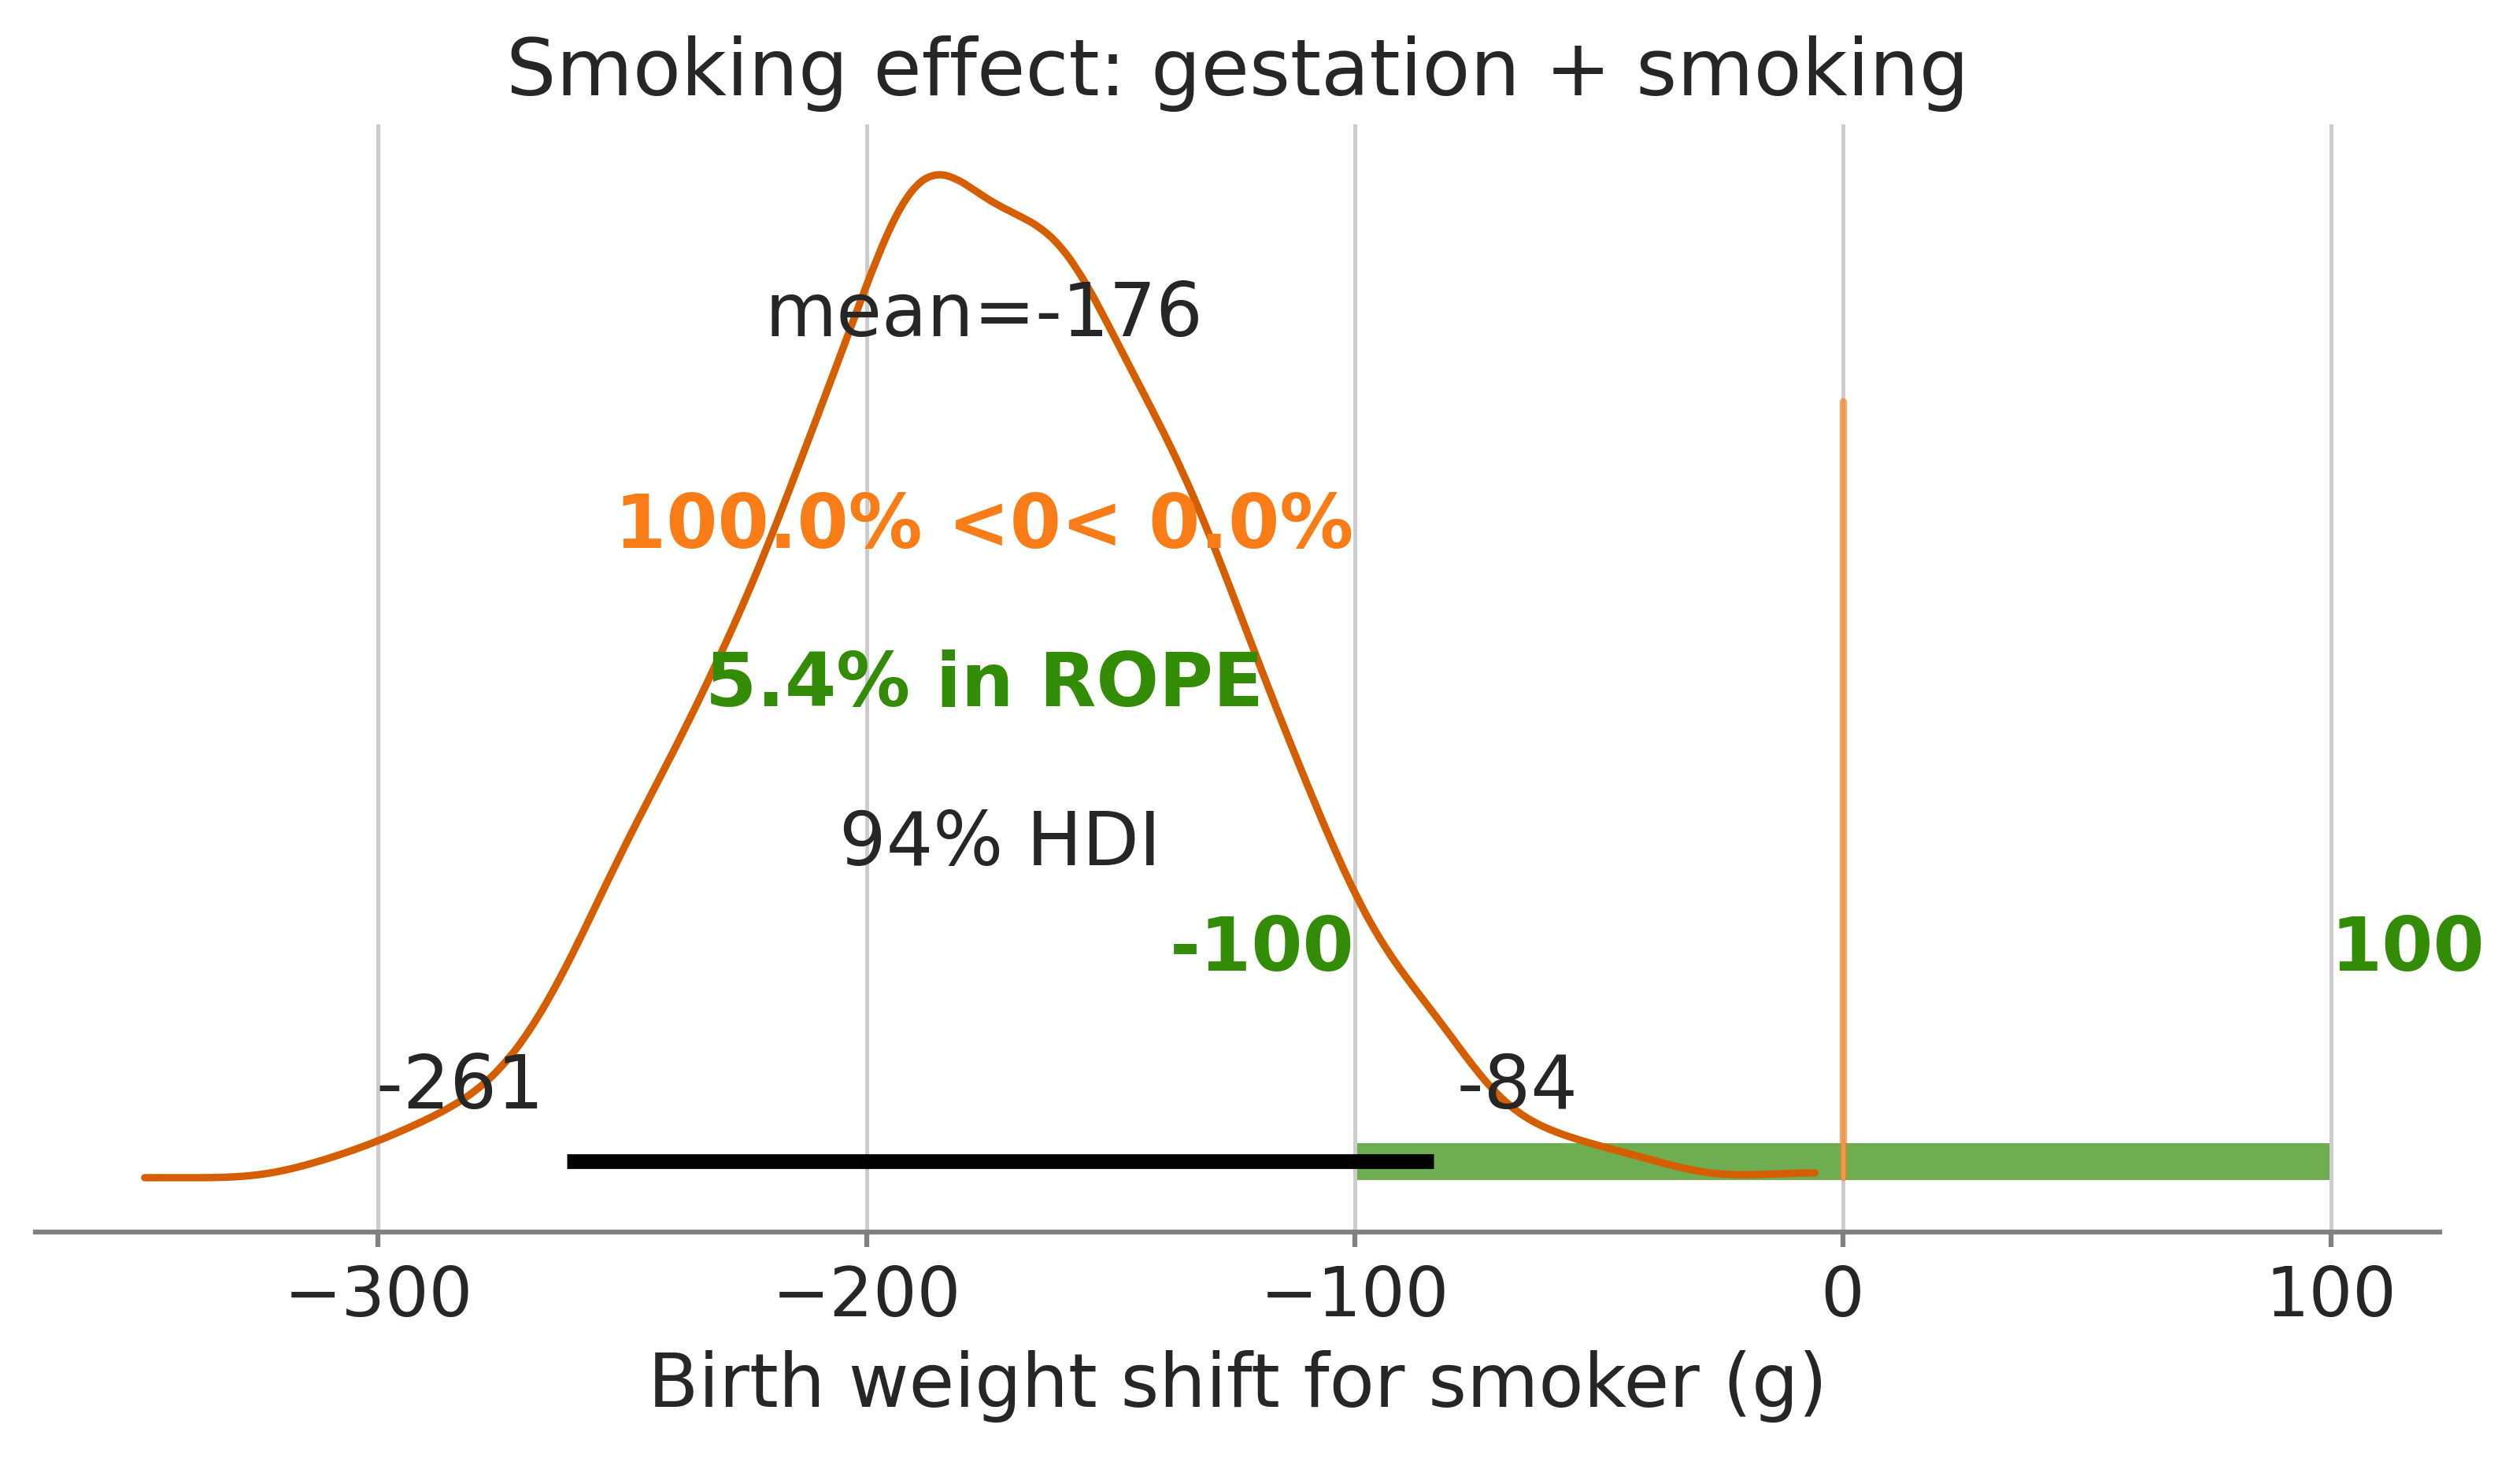

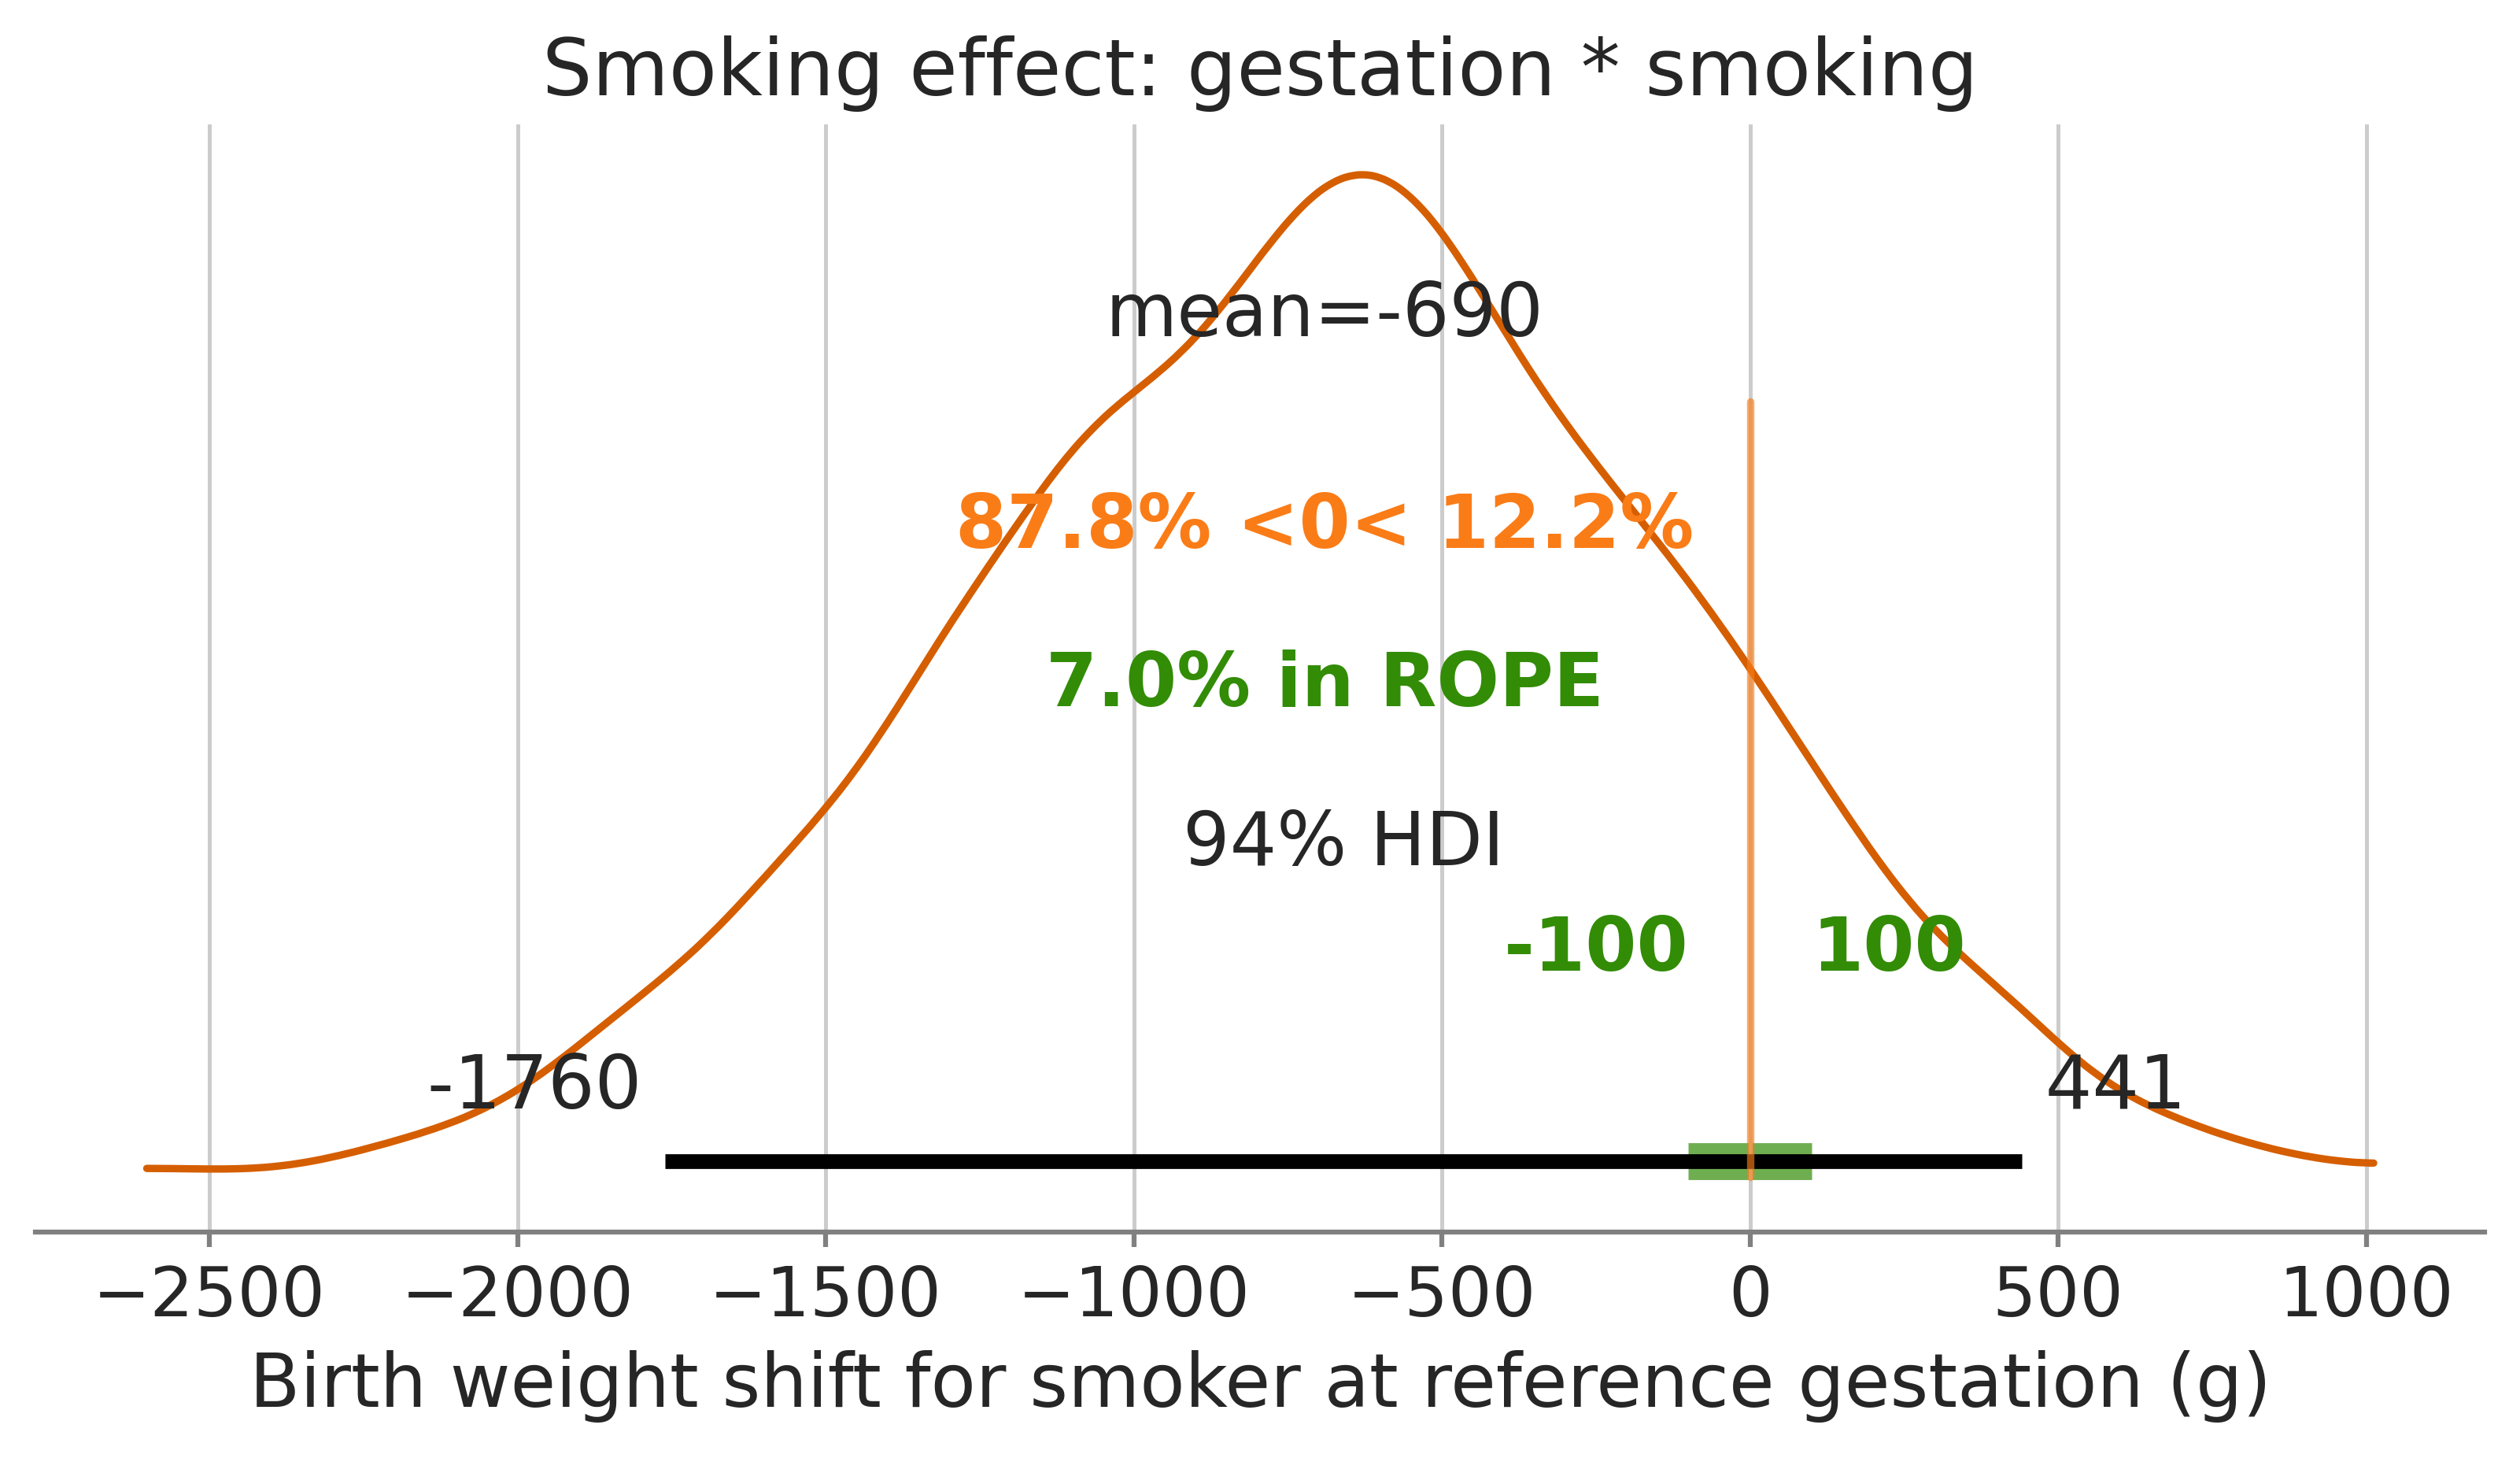

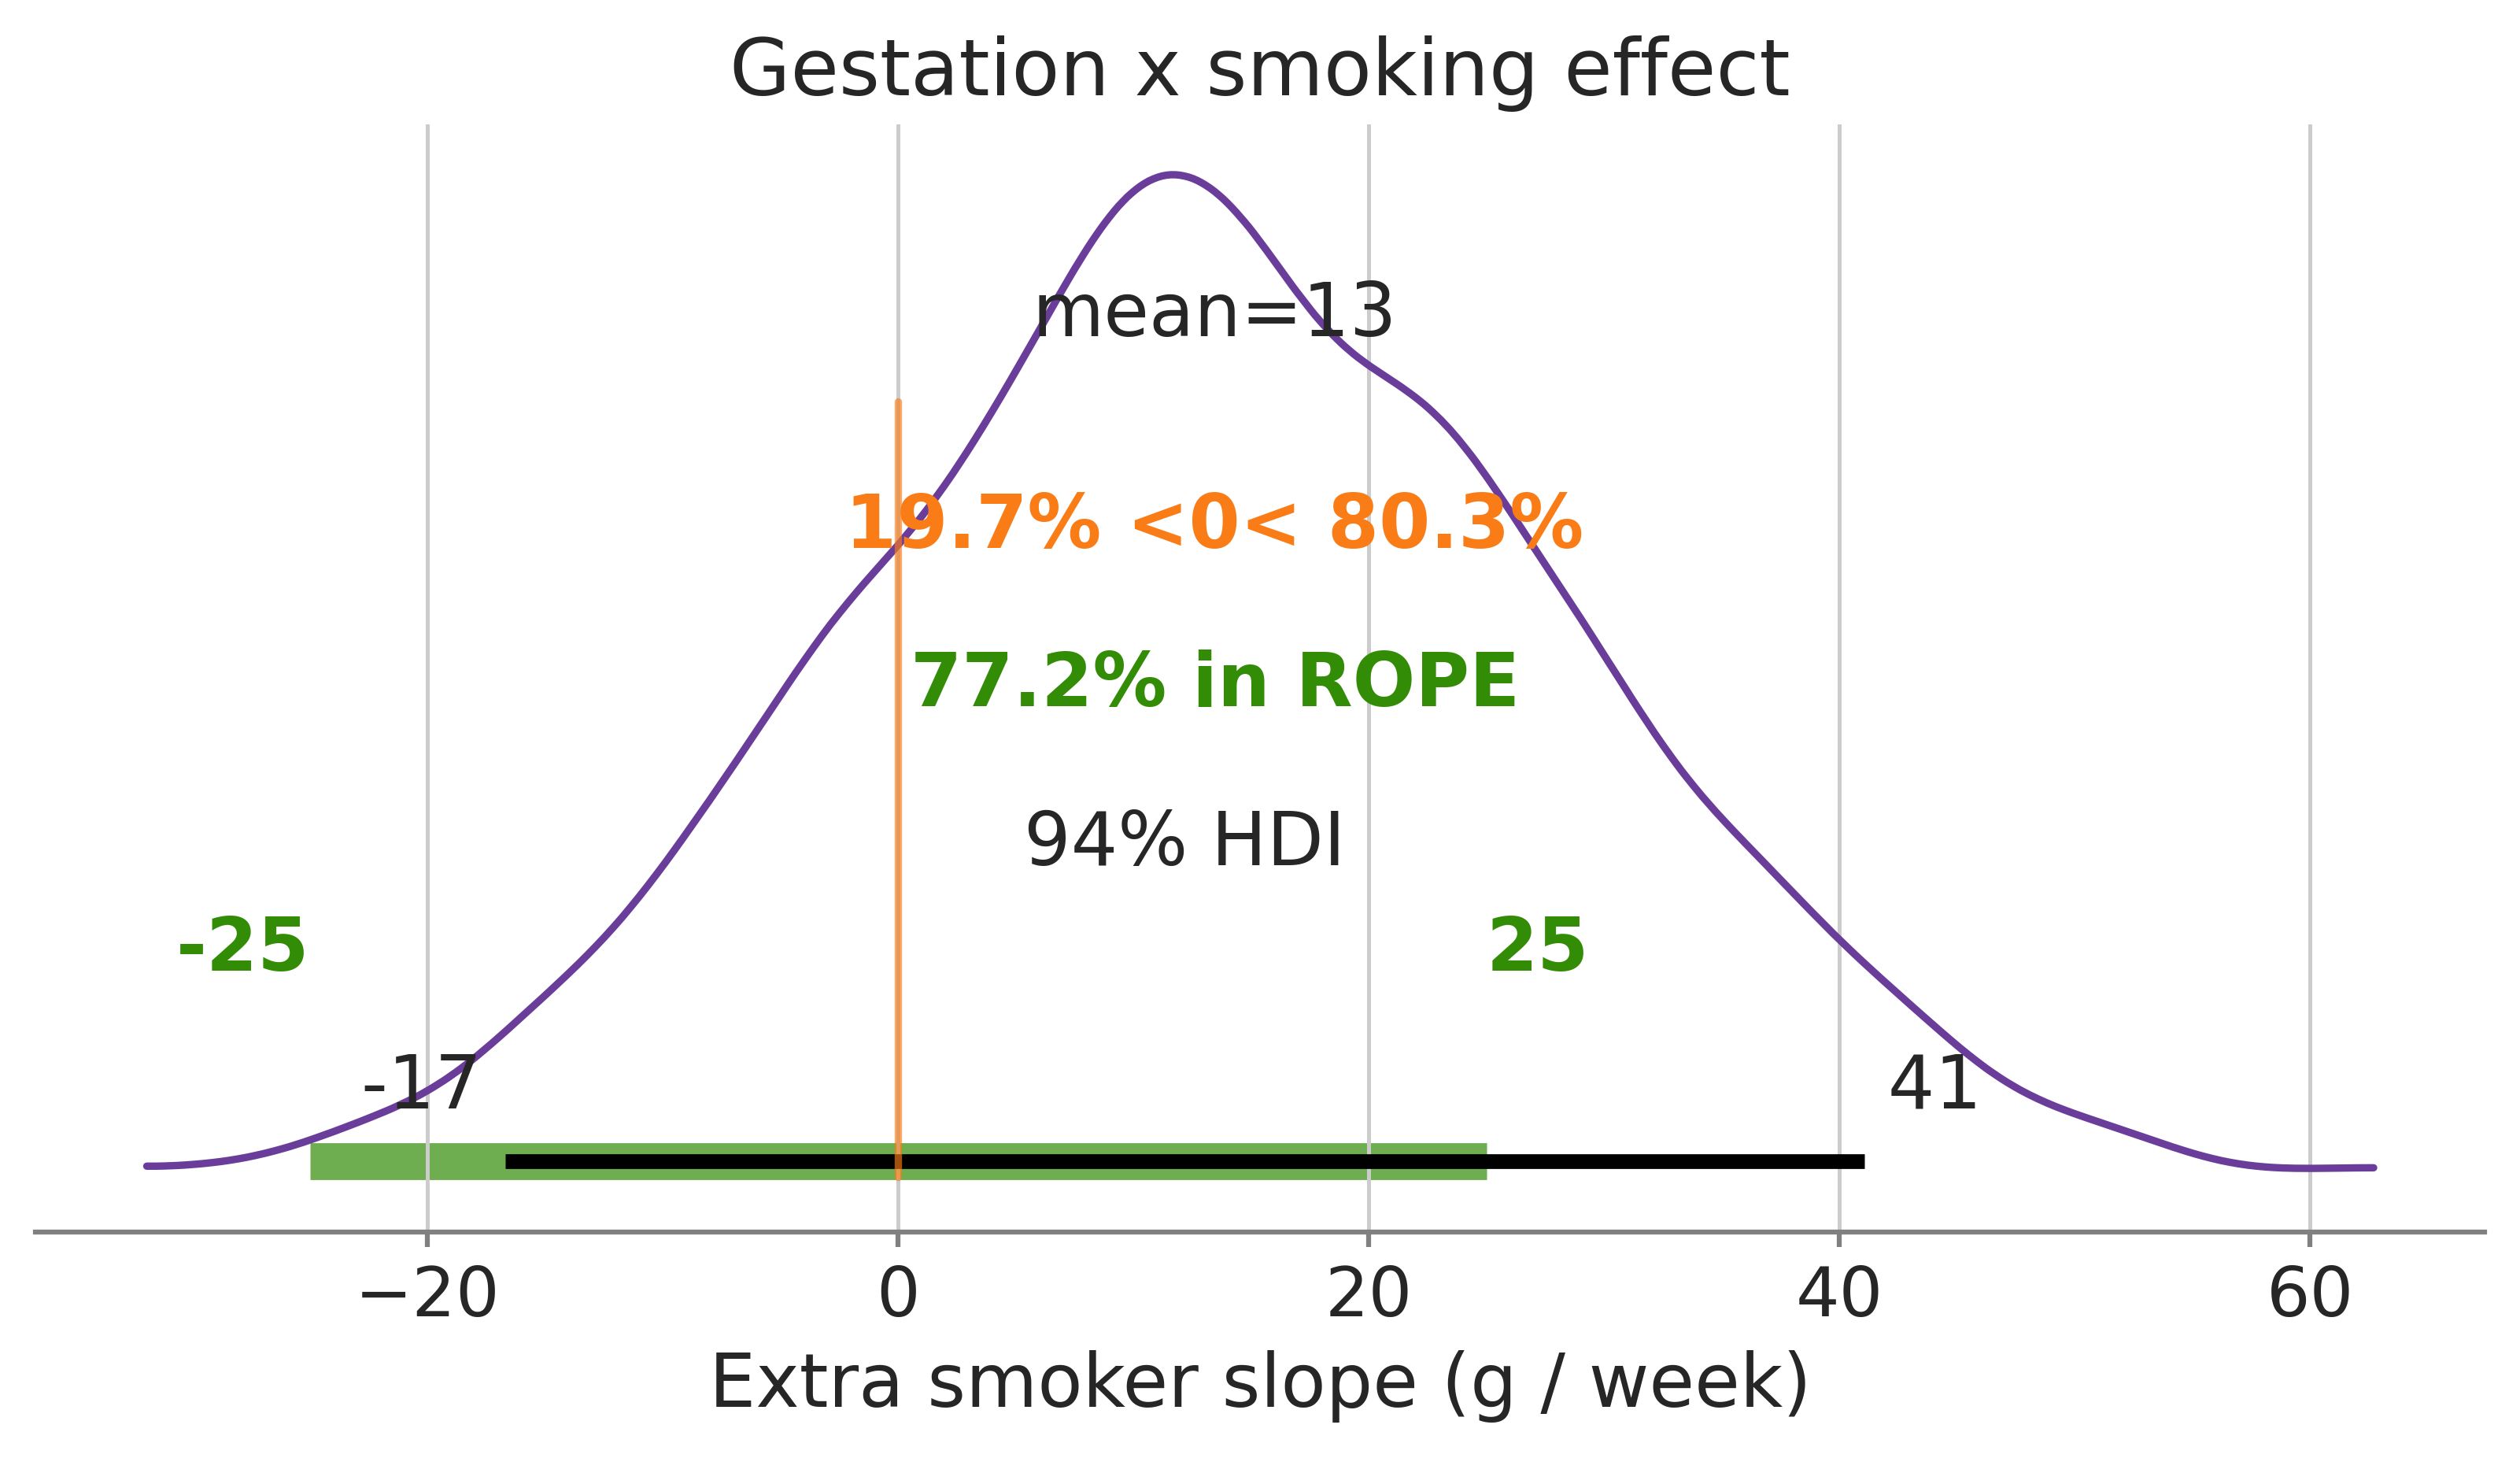

In [24]:
SMOKING_EFFECT_ROPE = (-100, 100)
INTERACTION_EFFECT_ROPE = (-25, 25)


def posterior_1d(idata, var_name, coord=None):
    values = idata.posterior[var_name].stack(sample=("chain", "draw"))
    if coord is not None:
        values = values.sel(coord)
    return values.transpose("sample").to_numpy()


birth_additive_smoking_effect = posterior_1d(
    birth_idata["gestation + smoking"],
    "smoking",
    {"smoking_dim": "smoker"},
)

fig, ax = plt.subplots(figsize=(7, 4))
az.plot_posterior(
    birth_additive_smoking_effect,
    hdi_prob=0.94,
    rope=SMOKING_EFFECT_ROPE,
    ref_val=0,
    ax=ax,
    color=BIRTH_COLORS["smoker"],
)
ax.set_title("Smoking effect: gestation + smoking")
ax.set_xlabel("Birth weight shift for smoker (g)")
plt.show()

birth_interaction_smoking_effect = posterior_1d(
    birth_idata["gestation * smoking"],
    "smoking",
    {"smoking_dim": "smoker"},
)

fig, ax = plt.subplots(figsize=(7, 4))
az.plot_posterior(
    birth_interaction_smoking_effect,
    hdi_prob=0.94,
    rope=SMOKING_EFFECT_ROPE,
    ref_val=0,
    ax=ax,
    color=BIRTH_COLORS["smoker"],
)
ax.set_title("Smoking effect: gestation * smoking")
ax.set_xlabel("Birth weight shift for smoker at reference gestation (g)")
plt.show()

birth_interaction_slope_effect = posterior_1d(
    birth_idata["gestation * smoking"],
    "gestation_weeks:smoking",
    {"gestation_weeks:smoking_dim": "smoker"},
)

fig, ax = plt.subplots(figsize=(7, 4))
az.plot_posterior(
    birth_interaction_slope_effect,
    hdi_prob=0.94,
    rope=INTERACTION_EFFECT_ROPE,
    ref_val=0,
    ax=ax,
    color=BIRTH_COLORS["interaction"],
)
ax.set_title("Gestation x smoking effect")
ax.set_xlabel("Extra smoker slope (g / week)")
plt.show()
